# COVID-19: Global Spread and Government Response

This notebook prepares the main analysis and visualizations for our final project on COVID-19 spread and government responses.

We work with two datasets from Google's COVID-19 Open Data:

1. **Epidemiology**
2. **Oxford Government Response**

Our goal is to:

- examine the global development of COVID-19 cases and deaths,
- study how government stringency changed over time,
- compare selected countries,
- and visualize the global spread of COVID-19 on a world map.

A central part of the project is the comparison of **Denmark, Germany, and Great Britain**.  
Because these countries have different population sizes, we avoid comparing raw case counts directly when the purpose is cross-country comparison.  
Instead, we use **cases per 100,000 inhabitants** and, where relevant, **deaths per 100,000 inhabitants**, which makes the comparison more meaningful.

A key preprocessing decision is to use **country-level rows only**.  
The epidemiology dataset contains country, regional, and local rows, and using all of them together would lead to **double-counting**. Therefore, we keep only rows where `location_key` contains no underscore.

## Load data

The paths below assume the notebook is placed in a folder next to a `data` folder containing:

- `epidemiology.csv`
- `oxford-government-response.csv`

In [4]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib as mpl
import plotly.express as px
import plotly.io as pio

import pycountry

In [5]:
from pathlib import Path

# Project folders
project_root = Path.cwd().parent
docs_plots_path = project_root / "docs" / "plots"
docs_plots_path.mkdir(parents=True, exist_ok=True)

print("Plots will be saved to:", docs_plots_path)

Plots will be saved to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots


## Load data

The paths below assume the notebook is placed in a folder next to a `data` folder containing:

- `epidemiology.csv`
- `oxford-government-response.csv`

In [6]:
current_dir = Path.cwd()

data_path1 = current_dir.parent / "data" / "epidemiology.csv"
data_path2 = current_dir.parent / "data" / "oxford-government-response.csv"

epi = pd.read_csv(data_path1, parse_dates=["date"], low_memory=False)
gov = pd.read_csv(data_path2, parse_dates=["date"], low_memory=False)

print("Epidemiology shape:", epi.shape)
print("Government response shape:", gov.shape)

Epidemiology shape: (12525825, 10)
Government response shape: (303969, 22)


## Initial inspection

Before cleaning the data, we inspect the structure of the datasets:
- the number of rows and columns,
- the variable names,
- and the date coverage.

This gives a first overview of the temporal range and available measures in each dataset.

In [7]:
print("Epidemiology columns:")
print(epi.columns.tolist())

print("\nGovernment response columns:")
print(gov.columns.tolist())

print("\nEpidemiology date range:", epi["date"].min(), "to", epi["date"].max())
print("Government response date range:", gov["date"].min(), "to", gov["date"].max())

Epidemiology columns:
['date', 'location_key', 'new_confirmed', 'new_deceased', 'new_recovered', 'new_tested', 'cumulative_confirmed', 'cumulative_deceased', 'cumulative_recovered', 'cumulative_tested']

Government response columns:
['date', 'location_key', 'school_closing', 'workplace_closing', 'cancel_public_events', 'restrictions_on_gatherings', 'public_transport_closing', 'stay_at_home_requirements', 'restrictions_on_internal_movement', 'international_travel_controls', 'income_support', 'debt_relief', 'fiscal_measures', 'international_support', 'public_information_campaigns', 'testing_policy', 'contact_tracing', 'emergency_investment_in_healthcare', 'investment_in_vaccines', 'facial_coverings', 'vaccination_policy', 'stringency_index']

Epidemiology date range: 2019-12-31 00:00:00 to 2022-12-30 00:00:00
Government response date range: 2020-01-01 00:00:00 to 2022-07-27 00:00:00


## Keep country-level rows only

Both datasets contain multiple geographic levels.  
For example, a country may appear as:

- `DK` → country level
- `US_CA` → state or regional level
- `BR_SP_3550308` → local level

To avoid double-counting, we keep only **country-level rows**, defined here as rows where `location_key` contains **no underscore**.

In [8]:
epi_country = epi[epi["location_key"].astype(str).str.count("_") == 0].copy()
gov_country = gov[gov["location_key"].astype(str).str.count("_") == 0].copy()

print("Country-level epidemiology shape:", epi_country.shape)
print("Country-level government response shape:", gov_country.shape)

print("Unique country-level keys in epidemiology:", epi_country["location_key"].nunique())
print("Unique country-level keys in government response:", gov_country["location_key"].nunique())

Country-level epidemiology shape: (227879, 10)
Country-level government response shape: (172116, 22)
Unique country-level keys in epidemiology: 232
Unique country-level keys in government response: 186


## Clean daily variables

Daily COVID-19 time series may contain negative values due to retrospective reporting corrections.

For the main visualizations, we clip negative daily values to zero in order to produce cleaner and more interpretable plots.  
This is particularly useful for introductory and explanatory charts, where the focus is on broad temporal patterns rather than reporting artefacts.

In [9]:
for col in ["new_confirmed", "new_deceased", "new_recovered", "new_tested"]:
    if col in epi_country.columns:
        epi_country[col] = epi_country[col].clip(lower=0)

## Country-code conversion for maps

The datasets use ISO-2 style country codes such as:

- `DK`
- `DE`
- `GB`
- `US`

Plotly choropleth maps work best with **ISO-3** codes such as:

- `DNK`
- `DEU`
- `GBR`
- `USA`

We therefore define a converter from ISO-2 to ISO-3 using `pycountry`.  
We also add a manual special case for Kosovo (`XK`).

In [10]:
special_cases = {
    "XK": "XKX",  # Kosovo
}

def iso2_to_iso3(code):
    if pd.isna(code):
        return None
    code = str(code).strip().upper()
    if code in special_cases:
        return special_cases[code]
    country = pycountry.countries.get(alpha_2=code)
    return country.alpha_3 if country else None

In [11]:
epi_country["iso3"] = epi_country["location_key"].apply(iso2_to_iso3)
gov_country["iso3"] = gov_country["location_key"].apply(iso2_to_iso3)

print("Sample epidemiology code conversion:")
print(
    epi_country[["location_key", "iso3"]]
    .drop_duplicates()
    .sort_values("location_key")
    .head(15)
)

print("\nSample government code conversion:")
print(
    gov_country[["location_key", "iso3"]]
    .drop_duplicates()
    .sort_values("location_key")
    .head(15)
)

print("\nUnmatched epidemiology location_keys:")
print(sorted(epi_country.loc[epi_country["iso3"].isna(), "location_key"].dropna().unique()))

print("\nUnmatched government location_keys:")
print(sorted(gov_country.loc[gov_country["iso3"].isna(), "location_key"].dropna().unique()))

Sample epidemiology code conversion:
       location_key iso3
0                AD  AND
987              AE  ARE
1974             AF  AFG
16471            AG  ATG
17458            AI  AIA
18445            AL  ALB
19432            AM  ARM
20419            AO  AGO
21406            AR  ARG
388003           AS  ASM
388990           AT  AUT
485984           AU  AUS
494718           AW  ABW
495705           AZ  AZE
496692           BA  BIH

Sample government code conversion:
      location_key iso3
0               AD  AND
901             AE  ARE
1831            AF  AFG
2769            AL  ALB
3690            AO  AGO
4606            AR  ARG
5530            AT  AUT
6467            AU  AUS
11457           AW  ABW
12394           AZ  AZE
13307           BA  BIH
14241           BB  BRB
15170           BD  BGD
16107           BE  BEL
17027           BF  BFA

Unmatched epidemiology location_keys:
[]

Unmatched government location_keys:
[]


## Verify country-code conversion

Before building the world map, check that all country-level rows can be converted successfully.

In [12]:
latest_cases_check = (
    epi_country.sort_values("date")
    .groupby("location_key", as_index=False)["cumulative_confirmed"]
    .last()
    .copy()
)

latest_cases_check["iso3"] = latest_cases_check["location_key"].apply(iso2_to_iso3)

print("Total country rows:", len(latest_cases_check))
print("Mapped to ISO-3:", latest_cases_check["iso3"].notna().sum())
print("Failed mappings:", latest_cases_check["iso3"].isna().sum())

failed_codes = sorted(latest_cases_check.loc[latest_cases_check["iso3"].isna(), "location_key"].unique())
print("Failed codes:", failed_codes)

Total country rows: 232
Mapped to ISO-3: 232
Failed mappings: 0
Failed codes: []


## Visual style

We use a consistent visual identity across the notebook and the final project.

The main visual design choices are:

- **background:** `#EDE8F5`
- **text, axes, and numeric labels:** `#1A1A2E`
- **Denmark:** `#F47CFB`
- **Germany:** `#76C6F8`
- **Great Britain:** `#72FCEE`
- **stringency / policy overlays:** `#FF6666`

Additional soft accent colors used where needed:

- `#D8ECEA`
- `#E1ECF3`
- `#CDE1ED`
- `#DEDAF2`
- `#EFDEF0`

The goal is to create figures that are cleaner, lighter, and more consistent across static and interactive charts.

In [13]:
## Visual style

# Core palette
BG = "#EDE8F5"         # background
TEXT = "#1A1A2E"       # text, axes, ticks
GRID = "#CFC7DD"       # soft grid
POLICY = "#FF6666"     # stringency / policy overlays

# Country colors
DENMARK = "#F47CFB"
GERMANY = "#76C6F8"
UK = "#72FCEE"

# Additional soft accent colors
ACCENT_1 = "#D8ECEA"
ACCENT_2 = "#E1ECF3"
ACCENT_3 = "#CDE1ED"
ACCENT_4 = "#DEDAF2"
ACCENT_5 = "#EFDEF0"

# Optional semantic colors for broader use
CASE_COLOR = "#1A1A2E"
DEATH_COLOR = "#1A1A2E"

# Country name to color mapping
COUNTRY_COLORS = {
    "Denmark": DENMARK,
    "Germany": GERMANY,
    "Great Britain": UK,
    "United Kingdom": UK,   # useful if naming varies in your data
}

# Matplotlib global style
mpl.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "axes.edgecolor": TEXT,
    "axes.labelcolor": TEXT,
    "xtick.color": TEXT,
    "ytick.color": TEXT,
    "text.color": TEXT,
    "axes.titlecolor": TEXT,
    "axes.titleweight": "bold",
    "axes.titlesize": 20,
    "axes.labelsize": 12,
    "font.size": 11,
    "font.family": "sans-serif",
    "font.sans-serif": ["Aptos", "DejaVu Sans", "Arial", "Liberation Sans"],
    "grid.color": GRID,
    "grid.alpha": 0.55,
    "grid.linewidth": 0.8,
    "axes.grid": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
    "legend.facecolor": BG,
    "legend.edgecolor": BG,
})

In [14]:
## Helper styling functions

def style_ax(ax, title=None, xlabel=None, ylabel=None):
    """Apply consistent axis styling."""
    if title:
        ax.set_title(title, pad=14)
    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)

    ax.spines["left"].set_color(TEXT)
    ax.spines["bottom"].set_color(TEXT)
    ax.tick_params(colors=TEXT)
    ax.set_facecolor(BG)
    ax.grid(True, color=GRID, alpha=0.55)

def country_color(country_name):
    """Return consistent country color."""
    return COUNTRY_COLORS.get(country_name, TEXT)

## Global cases over time

We begin with a global overview of new confirmed COVID-19 cases.

This figure aggregates **country-level daily new confirmed cases** across the world and applies a **7-day rolling average** to reduce reporting noise. The result highlights the broad global waves of the pandemic more clearly.

This opening view is useful as context for the rest of the project: before comparing Denmark, Germany, and Great Britain, we first show how COVID-19 unfolded at the global scale.

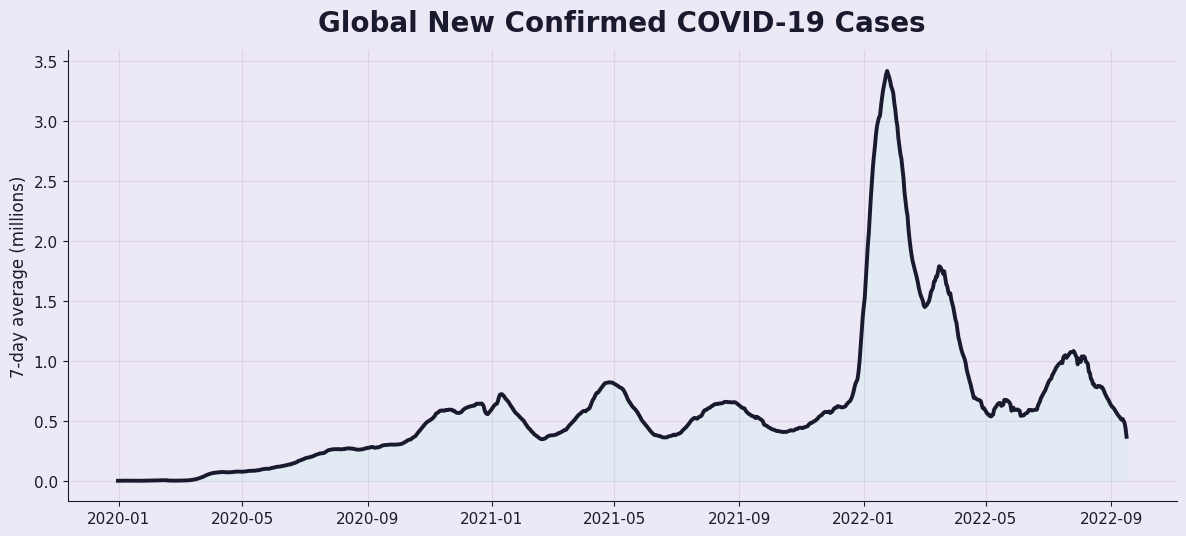

In [22]:
from matplotlib.ticker import FuncFormatter

# Prepare plotted data
global_cases_df = (
    epi_country.groupby("date", as_index=False)["new_confirmed"]
    .sum()
    .rename(columns={"new_confirmed": "global_new_confirmed"})
)

global_cases_df["global_new_confirmed_7day_avg"] = (
    global_cases_df["global_new_confirmed"]
    .rolling(7, min_periods=1)
    .mean()
)

# Save plotted data as CSV
global_cases_csv_path = docs_plots_path / "global_new_confirmed_cases_7day_avg.csv"
global_cases_df.to_csv(global_cases_csv_path, index=False)

# Create figure
fig, ax = plt.subplots(figsize=(12, 5.5))

ax.plot(
    global_cases_df["date"],
    global_cases_df["global_new_confirmed_7day_avg"],
    color=TEXT,
    linewidth=2.8
)

ax.fill_between(
    global_cases_df["date"],
    global_cases_df["global_new_confirmed_7day_avg"],
    color=ACCENT_2,
    alpha=0.85
)

style_ax(
    ax,
    title="Global New Confirmed COVID-19 Cases",
    ylabel="7-day average (millions)"
)

# Format y-axis in millions
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/1_000_000:.1f}"))

# Optional: if you want fewer decimals for whole numbers
# ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/1_000_000:g}"))

ax.set_xlabel("")

plt.tight_layout()
plt.show()


## Global deaths over time

We next examine the global development of new COVID-19 deaths.

As in the previous figure, we aggregate **country-level daily values** and apply a **7-day rolling average** to reduce reporting noise. Compared with the global cases curve, the deaths curve highlights a different aspect of the pandemic: not just how widely the virus spread, but when its human cost was greatest.

Together, the global cases and deaths figures provide the broader backdrop for the later comparison of Denmark, Germany, and Great Britain.

In [20]:
# Prepare plotted data
global_deaths_df = (
    epi_country.groupby("date", as_index=False)["new_deceased"]
    .sum()
    .rename(columns={"new_deceased": "global_new_deceased"})
)

global_deaths_df["global_new_deceased_7day_avg"] = (
    global_deaths_df["global_new_deceased"]
    .rolling(7, min_periods=1)
    .mean()
)

# Save plotted data as CSV
save_plot_data(global_deaths_df, "global_new_covid_deaths_7day_avg.csv")

# Create figure
fig, ax = plt.subplots(figsize=(12, 5.5))

ax.plot(
    global_deaths_df["date"],
    global_deaths_df["global_new_deceased_7day_avg"],
    color=TEXT,
    linewidth=2.8
)

ax.fill_between(
    global_deaths_df["date"],
    global_deaths_df["global_new_deceased_7day_avg"],
    color=ACCENT_5,
    alpha=0.9
)

style_ax(
    ax,
    title="Global New COVID-19 Deaths",
    ylabel="7-day average"
)

ax.set_xlabel("")
plt.tight_layout()


plt.show()

NameError: name 'save_plot_data' is not defined

## Average global government stringency over time

We now turn from epidemiological outcomes to policy response.

This figure shows the **average Oxford Government Stringency Index across countries**, smoothed with a **7-day rolling average**. The index combines multiple policy dimensions, including school closures, workplace closures, gathering restrictions, stay-at-home requirements, and travel controls.

As a result, the figure provides a broad global picture of how restrictive government responses were, on average, during different phases of the pandemic. This also helps connect the global health curves shown above to the policy environment in which they unfolded.

In [19]:
# Prepare plotted data
global_stringency_df = (
    gov_country.groupby("date", as_index=False)["stringency_index"]
    .mean()
    .rename(columns={"stringency_index": "global_mean_stringency_index"})
)

global_stringency_df["global_mean_stringency_index_7day_avg"] = (
    global_stringency_df["global_mean_stringency_index"]
    .rolling(7, min_periods=1)
    .mean()
)

# Save plotted data as CSV
save_plot_data(global_stringency_df, "global_mean_stringency_index_7day_avg.csv")

# Create figure
fig, ax = plt.subplots(figsize=(12, 5.5))

ax.plot(
    global_stringency_df["date"],
    global_stringency_df["global_mean_stringency_index_7day_avg"],
    color=POLICY,
    linewidth=2.8
)

ax.fill_between(
    global_stringency_df["date"],
    global_stringency_df["global_mean_stringency_index_7day_avg"],
    color=ACCENT_4,
    alpha=0.85
)

style_ax(
    ax,
    title="Average Global Government Stringency Index",
    ylabel="7-day average"
)

ax.set_xlabel("")
plt.tight_layout()


plt.show()

NameError: name 'save_plot_data' is not defined

## Summary totals from the epidemiology dataset

To provide a compact overview of the epidemiology dataset, we calculate a set of global summary values based on the **latest available country-level cumulative totals**.

The summary includes:

- total confirmed infections,
- total deaths,
- total recovered,
- and the number of countries with at least one confirmed case.

Because the dataset contains repeated observations over time, we first keep the **latest cumulative row for each country** before aggregating.

In [ ]:
# Keep the latest cumulative row for each country
latest_totals = (
    epi_country.sort_values(["location_key", "date"])
    .groupby("location_key", as_index=False)[
        ["date", "cumulative_confirmed", "cumulative_deceased", "cumulative_recovered"]
    ]
    .last()
    .fillna(0)
)

# Compute summary values
total_infected = latest_totals["cumulative_confirmed"].sum()
total_deaths = latest_totals["cumulative_deceased"].sum()
total_recovered = latest_totals["cumulative_recovered"].sum()
countries_affected = (latest_totals["cumulative_confirmed"] > 0).sum()

# Create a summary table
epi_summary_df = pd.DataFrame({
    "metric": [
        "Total confirmed infections",
        "Total deaths",
        "Total recovered",
        "Countries affected"
    ],
    "value": [
        int(total_infected),
        int(total_deaths),
        int(total_recovered),
        int(countries_affected)
    ]
})


# Print formatted summary
for _, row in epi_summary_df.iterrows():
    print(f"{row['metric']}: {row['value']:,}")

# Display nicely in notebook
display(
    epi_summary_df.style.format({"value": "{:,.0f}"})
)

Saved CSV to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/epidemiology_summary_totals.csv
Total confirmed infections: 606,525,388
Total deaths: 6,167,100
Total recovered: 327,308,101
Countries affected: 227


,metric,value
0,Total confirmed infections,"606,525,388"
1,Total deaths,"6,167,100"
2,Total recovered,"327,308,101"
3,Countries affected,227


## World map of total confirmed infections

This choropleth map shows the latest available **total confirmed COVID-19 infections by country**.

Important notes:

- only **country-level rows** are used,
- ISO-2 country codes are converted to **ISO-3**,
- the map uses a **log-transformed color scale** to handle the very large differences in total case counts across countries,
- and the upper end of the color range is slightly clipped to improve contrast among mid-range countries.

Because this map shows **raw cumulative totals**, it is most useful as a global overview of the pandemic's geographic spread. For direct cross-country comparison, later sections use population-adjusted measures such as **cases per 100,000 inhabitants**.

In [ ]:
# Prepare latest country-level cumulative confirmed cases
latest_cases = (
    epi_country.sort_values("date")
    .groupby("location_key", as_index=False)[["date", "cumulative_confirmed"]]
    .last()
    .copy()
)

latest_cases["iso3"] = latest_cases["location_key"].apply(iso2_to_iso3)
latest_cases["cumulative_confirmed"] = latest_cases["cumulative_confirmed"].fillna(0)

# Keep only rows with valid ISO-3 codes
latest_cases = latest_cases[latest_cases["iso3"].notna()].copy()

# Log transform for color scaling
latest_cases["log10_cumulative_confirmed_plus_1"] = np.log10(
    latest_cases["cumulative_confirmed"] + 1
)

# Split zero and nonzero countries
zero_cases = latest_cases[latest_cases["cumulative_confirmed"] == 0].copy()
nonzero_cases = latest_cases[latest_cases["cumulative_confirmed"] > 0].copy()

# Save plotted data as CSV
save_plot_data(
    latest_cases,
    "world_map_total_confirmed_infections_latest.csv"
)

# Set color scale range
zmin = nonzero_cases["log10_cumulative_confirmed_plus_1"].min()
zmax = nonzero_cases["log10_cumulative_confirmed_plus_1"].quantile(0.98)

# Soft aesthetic red-pink scale matching your palette better
color_scale_cases = [
    [0.00, "#EFDEF0"],
    [0.20, "#DEDAF2"],
    [0.40, "#F6B4B4"],
    [0.60, "#FF8A8A"],
    [0.80, "#FF6666"],
    [1.00, "#C94F4F"],
]

# Main choropleth
fig = px.choropleth(
    nonzero_cases,
    locations="iso3",
    color="log10_cumulative_confirmed_plus_1",
    hover_name="location_key",
    hover_data={
        "iso3": False,
        "date": True,
        "cumulative_confirmed": ":,.0f",
        "log10_cumulative_confirmed_plus_1": False,
    },
    color_continuous_scale=color_scale_cases,
    projection="natural earth",
    title="World Map: Total Confirmed COVID-19 Infections by Country",
    range_color=(zmin, zmax),
)

# Add zero-case countries in a very light neutral shade
if len(zero_cases) > 0:
    fig.add_choropleth(
        locations=zero_cases["iso3"],
        z=[0] * len(zero_cases),
        colorscale=[[0, ACCENT_2], [1, ACCENT_2]],
        showscale=False,
        hovertext=zero_cases["location_key"],
        hoverinfo="text",
        marker_line_color=TEXT,
        marker_line_width=0.35,
    )

# Layout styling
fig.update_layout(
    paper_bgcolor=BG,
    plot_bgcolor=BG,
    font=dict(
        family="Aptos, DejaVu Sans, Arial, sans-serif",
        color=TEXT,
        size=14
    ),
    title=dict(
        text="World Map: Total Confirmed COVID-19 Infections by Country",
        x=0.03,
        xanchor="left",
        font=dict(size=28, color=TEXT)
    ),
    coloraxis_colorbar=dict(
        title=dict(
            text="log10(cases + 1)",
            font=dict(color=TEXT)
        ),
        tickfont=dict(color=TEXT),
        thickness=18,
        len=0.75
    ),
    margin=dict(l=0, r=0, t=70, b=0),
)

fig.update_geos(
    showframe=False,
    showcoastlines=False,
    showcountries=True,
    countrycolor=TEXT,
    countrywidth=0.35,
    showland=True,
    landcolor=ACCENT_2,
    showocean=True,
    oceancolor=BG,
    bgcolor=BG,
)

# Display in notebook
fig.show()

Saved CSV to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/world_map_total_confirmed_infections_latest.csv
Saved interactive figure to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/world_map_total_confirmed_infections_latest.html


## World map of total deaths

This choropleth map shows the latest available **total COVID-19 deaths by country**.

The map uses the same overall approach as the infections map:
- only **country-level rows** are included,
- ISO-2 country codes are converted to **ISO-3**,
- values are shown on a **log-transformed color scale**,
- and the upper end of the scale is slightly clipped to improve contrast across countries.

Placed alongside the infections map, this figure helps distinguish between the global spread of confirmed cases and the global distribution of mortality.

In [ ]:
# Prepare latest country-level cumulative deaths
latest_deaths = (
    epi_country.sort_values("date")
    .groupby("location_key", as_index=False)[["date", "cumulative_deceased"]]
    .last()
    .copy()
)

latest_deaths["iso3"] = latest_deaths["location_key"].apply(iso2_to_iso3)
latest_deaths["cumulative_deceased"] = latest_deaths["cumulative_deceased"].fillna(0)

# Keep only rows with valid ISO-3 codes
latest_deaths = latest_deaths[latest_deaths["iso3"].notna()].copy()

# Log transform for color scaling
latest_deaths["log10_cumulative_deceased_plus_1"] = np.log10(
    latest_deaths["cumulative_deceased"] + 1
)

# Split zero and nonzero countries
zero_deaths = latest_deaths[latest_deaths["cumulative_deceased"] == 0].copy()
nonzero_deaths = latest_deaths[latest_deaths["cumulative_deceased"] > 0].copy()

# Save plotted data as CSV
save_plot_data(
    latest_deaths,
    "world_map_total_covid_deaths_latest.csv"
)

# Set color scale range
zmin = nonzero_deaths["log10_cumulative_deceased_plus_1"].min()
zmax = nonzero_deaths["log10_cumulative_deceased_plus_1"].quantile(0.98)

# Death-oriented red scale, still matching the notebook palette
color_scale_deaths = [
    [0.00, "#EFDEF0"],
    [0.20, "#E7B7C0"],
    [0.40, "#D88A9B"],
    [0.60, "#C85F72"],
    [0.80, "#B33C50"],
    [1.00, "#7A1E2C"],
]

# Main choropleth
fig = px.choropleth(
    nonzero_deaths,
    locations="iso3",
    color="log10_cumulative_deceased_plus_1",
    hover_name="location_key",
    hover_data={
        "iso3": False,
        "date": True,
        "cumulative_deceased": ":,.0f",
        "log10_cumulative_deceased_plus_1": False,
    },
    color_continuous_scale=color_scale_deaths,
    projection="natural earth",
    title="World Map: Total COVID-19 Deaths by Country",
    range_color=(zmin, zmax),
)

# Add zero-death countries in a soft neutral shade
if len(zero_deaths) > 0:
    fig.add_choropleth(
        locations=zero_deaths["iso3"],
        z=[0] * len(zero_deaths),
        colorscale=[[0, ACCENT_2], [1, ACCENT_2]],
        showscale=False,
        hovertext=zero_deaths["location_key"],
        hoverinfo="text",
        marker_line_color=TEXT,
        marker_line_width=0.35,
    )

# Layout styling
fig.update_layout(
    paper_bgcolor=BG,
    plot_bgcolor=BG,
    font=dict(
        family="Aptos, DejaVu Sans, Arial, sans-serif",
        color=TEXT,
        size=14
    ),
    title=dict(
        text="World Map: Total COVID-19 Deaths by Country",
        x=0.03,
        xanchor="left",
        font=dict(size=28, color=TEXT)
    ),
    coloraxis_colorbar=dict(
        title=dict(
            text="log10(deaths + 1)",
            font=dict(color=TEXT)
        ),
        tickfont=dict(color=TEXT),
        thickness=18,
        len=0.75
    ),
    margin=dict(l=0, r=0, t=70, b=0),
)

fig.update_geos(
    showframe=False,
    showcoastlines=False,
    showcountries=True,
    countrycolor=TEXT,
    countrywidth=0.35,
    showland=True,
    landcolor=ACCENT_2,
    showocean=True,
    oceancolor=BG,
    bgcolor=BG,
)

# Display in notebook
fig.show()

Saved CSV to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/world_map_total_covid_deaths_latest.csv
Saved interactive figure to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/world_map_total_covid_deaths_latest.html


## Selected countries for comparison

To create a more focused comparison, we now examine three European countries:

- Denmark (`DK`)
- Germany (`DE`)
- Great Britain / United Kingdom (`GB`)

These countries are geographically closer and more comparable than the earlier global set.  
This makes it easier to study differences in COVID-19 development and government response in a more controlled regional context.

At the same time, the three countries differ in population size. For that reason, the main comparative plots use **cases per 100,000 inhabitants** and, where relevant, **deaths per 100,000 inhabitants**, rather than raw daily totals.

In [ ]:
selected_countries = ["DK", "DE", "GB"]

country_names = {
    "DK": "Denmark",
    "DE": "Germany",
    "GB": "Great Britain"
}

COUNTRY_COLORS = {
    "DK": DENMARK,
    "DE": GERMANY,
    "GB": UK,
}

## Build comparison tables

We now prepare cleaned country-level time series for the selected countries.

For the epidemiology data we compute:

- 7-day average confirmed cases,
- 7-day average deaths,
- and, where population data are available, **7-day average cases per 100,000 inhabitants** and **deaths per 100,000 inhabitants**.

For the Oxford dataset we compute:

- 7-day average stringency index.

These smoothed measures reduce day-to-day reporting noise and make country comparisons easier to interpret.

In [ ]:
epi_compare = (
    epi_country[epi_country["location_key"].isin(selected_countries)]
    .copy()
    .sort_values(["location_key", "date"])
)

gov_compare = (
    gov_country[gov_country["location_key"].isin(selected_countries)]
    .copy()
    .sort_values(["location_key", "date"])
)

epi_compare["country"] = epi_compare["location_key"].map(country_names)
gov_compare["country"] = gov_compare["location_key"].map(country_names)

# 7-day rolling averages for raw values
epi_compare["new_confirmed_7d"] = (
    epi_compare.groupby("location_key")["new_confirmed"]
    .transform(lambda s: s.rolling(7, min_periods=1).mean())
)

epi_compare["new_deceased_7d"] = (
    epi_compare.groupby("location_key")["new_deceased"]
    .transform(lambda s: s.rolling(7, min_periods=1).mean())
)

gov_compare["stringency_7d"] = (
    gov_compare.groupby("location_key")["stringency_index"]
    .transform(lambda s: s.rolling(7, min_periods=1).mean())
)

# Per 100,000 if population is available
if "population" in epi_compare.columns:
    epi_compare["new_confirmed_per_100k"] = (
        epi_compare["new_confirmed"] / epi_compare["population"] * 100000
    )
    epi_compare["new_deceased_per_100k"] = (
        epi_compare["new_deceased"] / epi_compare["population"] * 100000
    )

    epi_compare["new_confirmed_per_100k_7d"] = (
        epi_compare.groupby("location_key")["new_confirmed_per_100k"]
        .transform(lambda s: s.rolling(7, min_periods=1).mean())
    )

    epi_compare["new_deceased_per_100k_7d"] = (
        epi_compare.groupby("location_key")["new_deceased_per_100k"]
        .transform(lambda s: s.rolling(7, min_periods=1).mean())
    )

print("Epidemiology comparison shape:", epi_compare.shape)
print("Government response comparison shape:", gov_compare.shape)

Epidemiology comparison shape: (2961, 13)
Government response comparison shape: (2787, 24)


## Population sources for per-capita comparisons

To make cross-country comparisons more meaningful, we normalize selected epidemiological measures by population size and report them per 100,000 inhabitants.

The population values used for Denmark, Germany, and Great Britain / the United Kingdom are taken from official national statistical sources:

- Statistics Denmark. (2026, April 10). *Population figures*. https://www.dst.dk/en/Statistik/emner/borgere/befolkning/befolkningstal
- Statistisches Bundesamt (Destatis). (2020, June 19). *Germany’s population increased to 83.2 million in 2019* (Press release No. 223). https://www.destatis.de/EN/Press/2020/06/PE20_223_12411.html
- Office for National Statistics. (2020, June 24). *Population estimates for the UK, England and Wales, Scotland and Northern Ireland: Mid-2019*. https://www.ons.gov.uk/peoplepopulationandcommunity/populationandmigration/populationestimates/bulletins/annualmidyearpopulationestimates/mid2019estimates

In [ ]:
population_map = {
    "DK": 6029607,    # Statistics Denmark, March/April 2026 population figure
    "DE": 83200000,   # Destatis, end of 2019
    "GB": 66796807,   # ONS, mid-2019 UK estimate
}

epi_compare["population"] = epi_compare["location_key"].map(population_map)

epi_compare["new_confirmed_per_100k"] = (
    epi_compare["new_confirmed"] / epi_compare["population"] * 100000
)

epi_compare["new_deceased_per_100k"] = (
    epi_compare["new_deceased"] / epi_compare["population"] * 100000
)

epi_compare["new_confirmed_per_100k_7d"] = (
    epi_compare.groupby("location_key")["new_confirmed_per_100k"]
    .transform(lambda s: s.rolling(7, min_periods=1).mean())
)

epi_compare["new_deceased_per_100k_7d"] = (
    epi_compare.groupby("location_key")["new_deceased_per_100k"]
    .transform(lambda s: s.rolling(7, min_periods=1).mean())
)

## Static comparison: daily new confirmed cases per 100,000

This figure compares Denmark, Germany, and Great Britain using the **7-day average of daily new confirmed cases per 100,000 inhabitants**.

This combines two choices:

- **per 100,000 inhabitants** makes the comparison fairer across countries with different population sizes,
- **7-day averaging** smooths day-to-day reporting noise and makes the major waves easier to interpret.

The y-axis therefore shows the **average number of newly confirmed cases reported each day, per 100,000 inhabitants, over the previous 7 days**.

With all three countries shown in the same figure, we can compare:

- the timing of major waves,
- the relative height of peaks,
- and the overall development over time.

Saved CSV to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/selected_countries_daily_new_confirmed_cases_per_100k_7day_avg.csv
Saved figure to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/selected_countries_daily_new_confirmed_cases_per_100k_7day_avg.png


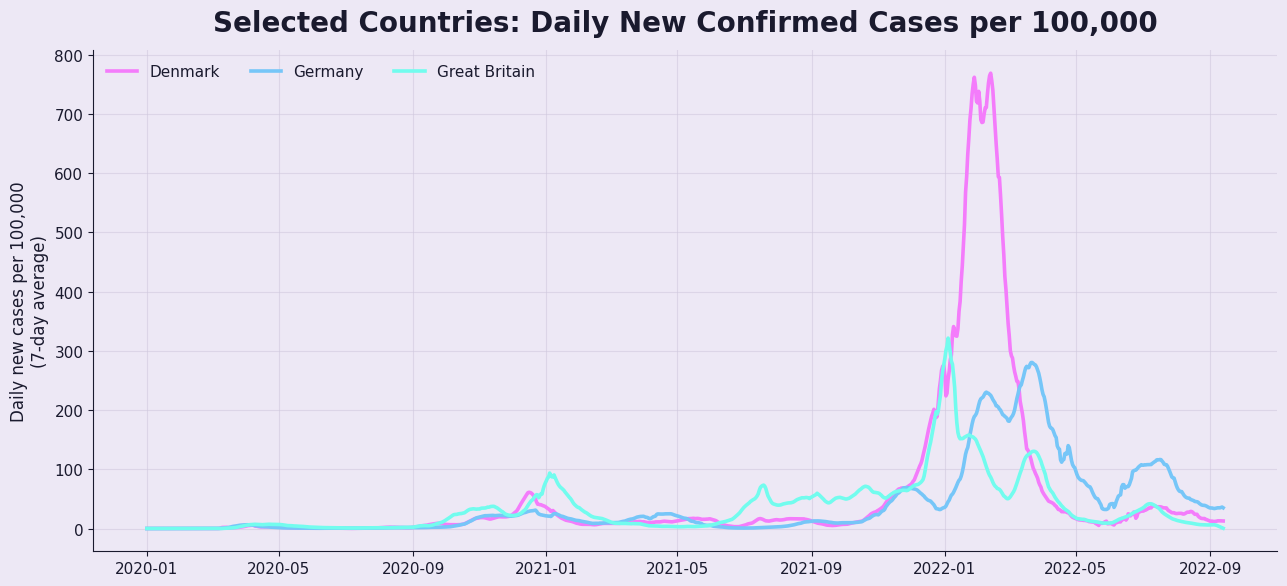

In [ ]:
# Prepare plotted data for the figure
cases_compare_df = epi_compare[
    ["date", "location_key", "country", "new_confirmed_per_100k_7d"]
].copy()

# Save plotted data as CSV
save_plot_data(
    cases_compare_df,
    "selected_countries_daily_new_confirmed_cases_per_100k_7day_avg.csv"
)

# Create figure
fig, ax = plt.subplots(figsize=(13, 6))

for code in selected_countries:
    df_plot = cases_compare_df[cases_compare_df["location_key"] == code]

    ax.plot(
        df_plot["date"],
        df_plot["new_confirmed_per_100k_7d"],
        label=country_names[code],
        linewidth=2.6,
        color=COUNTRY_COLORS[code]
    )

style_ax(
    ax,
    title="Selected Countries: Daily New Confirmed Cases per 100,000",
    ylabel="Daily new cases per 100,000\n(7-day average)"
)

ax.set_xlabel("")
ax.legend(frameon=False, ncol=3)

plt.tight_layout()


plt.show()

## Static comparison: daily new deaths per 100,000

This figure compares Denmark, Germany, and Great Britain using the **7-day average of daily new COVID-19 deaths per 100,000 inhabitants**.

As with the cases comparison, this combines two choices:

- **per 100,000 inhabitants** makes the comparison more meaningful across countries with different population sizes,
- **7-day averaging** smooths day-to-day variation and reporting noise.

The y-axis therefore shows the **average number of newly reported deaths each day, per 100,000 inhabitants, over the previous 7 days**.

This makes it easier to compare:

- the timing of mortality waves,
- the relative height of peaks,
- and the overall severity of the pandemic across the three countries.

Saved CSV to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/selected_countries_daily_new_deaths_per_100k_7day_avg.csv
Saved figure to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/selected_countries_daily_new_deaths_per_100k_7day_avg.png


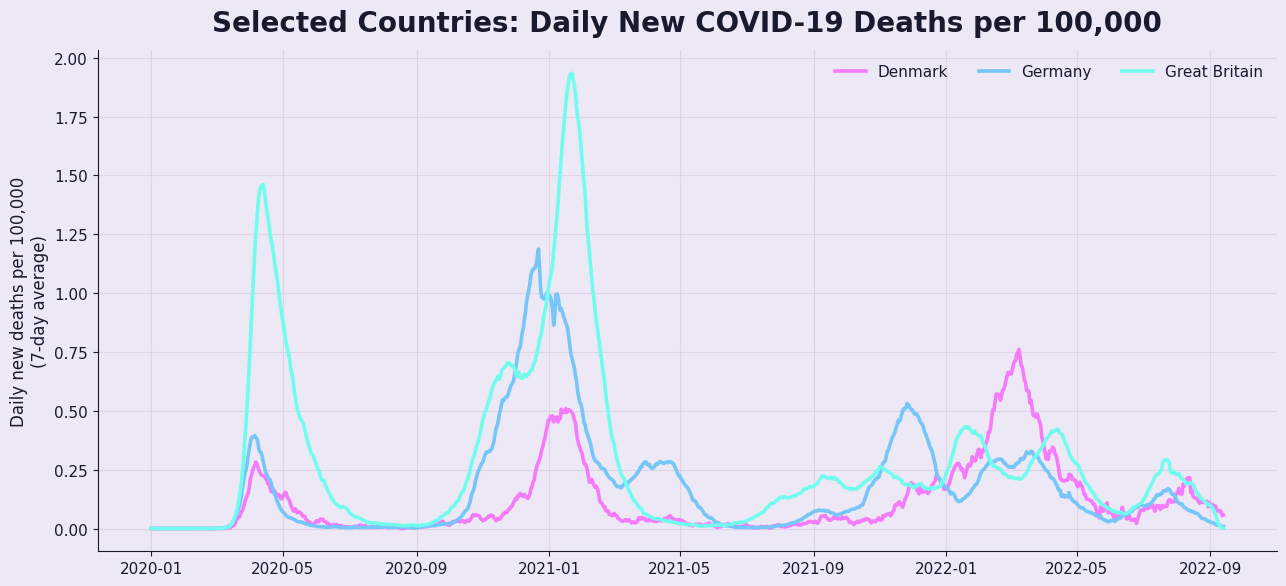

In [ ]:
# Prepare plotted data for the figure
deaths_compare_df = epi_compare[
    ["date", "location_key", "country", "new_deceased_per_100k_7d"]
].copy()

# Save plotted data as CSV
save_plot_data(
    deaths_compare_df,
    "selected_countries_daily_new_deaths_per_100k_7day_avg.csv"
)

# Create figure
fig, ax = plt.subplots(figsize=(13, 6))

for code in selected_countries:
    df_plot = deaths_compare_df[deaths_compare_df["location_key"] == code]

    ax.plot(
        df_plot["date"],
        df_plot["new_deceased_per_100k_7d"],
        label=country_names[code],
        linewidth=2.6,
        color=COUNTRY_COLORS[code]
    )

style_ax(
    ax,
    title="Selected Countries: Daily New COVID-19 Deaths per 100,000",
    ylabel="Daily new deaths per 100,000\n(7-day average)"
)

ax.set_xlabel("")
ax.legend(frameon=False, ncol=3)

plt.tight_layout()


plt.show()

## Static comparison: government stringency index

This figure compares the **7-day average Oxford Government Stringency Index** across Denmark, Germany, and Great Britain.

Unlike cases and deaths, the stringency index is already a standardized policy indicator, so it can be compared directly across countries without population adjustment. The index summarizes multiple government responses, including school closures, workplace closures, gathering restrictions, stay-at-home requirements, and travel controls.

The chart helps identify differences in:

- the timing of restrictions,
- the intensity of policy responses,
- and how long stricter measures remained in place.

Saved CSV to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/selected_countries_government_stringency_index_7day_avg.csv
Saved figure to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/selected_countries_government_stringency_index_7day_avg.png


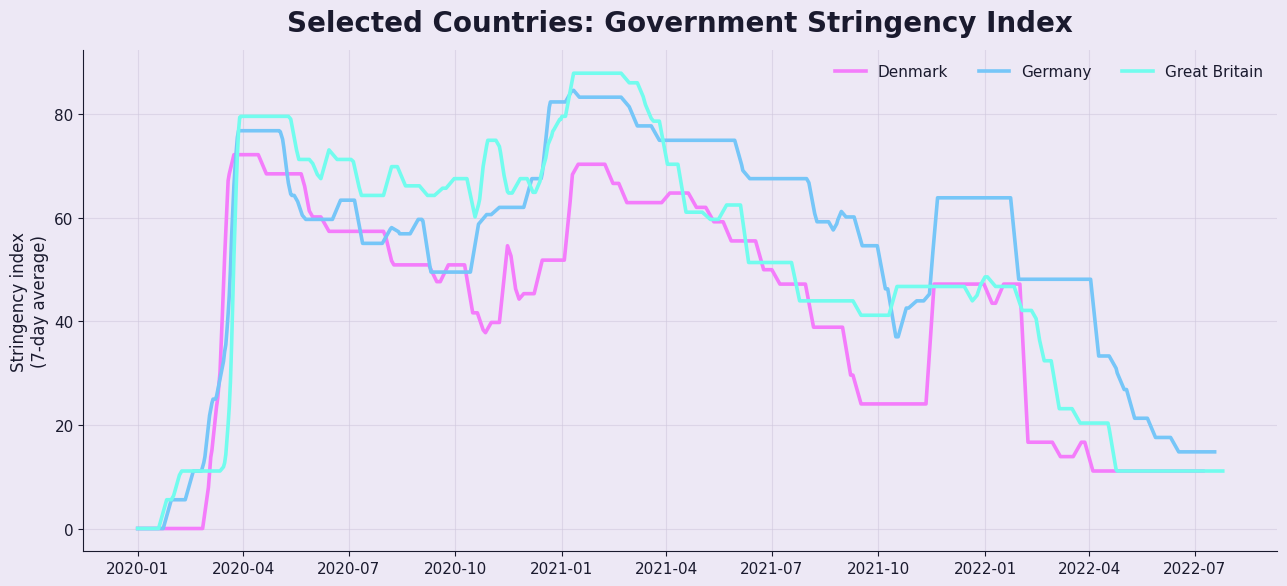

In [ ]:
# Prepare plotted data for the figure
stringency_compare_df = gov_compare[
    ["date", "location_key", "country", "stringency_7d"]
].copy()

# Save plotted data as CSV
save_plot_data(
    stringency_compare_df,
    "selected_countries_government_stringency_index_7day_avg.csv"
)

# Create figure
fig, ax = plt.subplots(figsize=(13, 6))

for code in selected_countries:
    df_plot = stringency_compare_df[stringency_compare_df["location_key"] == code]

    ax.plot(
        df_plot["date"],
        df_plot["stringency_7d"],
        label=country_names[code],
        linewidth=2.6,
        color=COUNTRY_COLORS[code]
    )

style_ax(
    ax,
    title="Selected Countries: Government Stringency Index",
    ylabel="Stringency index\n(7-day average)"
)

ax.set_xlabel("")
ax.legend(frameon=False, ncol=3)

plt.tight_layout()


plt.show()

## Small multiples: daily new confirmed cases per 100,000 by country

This figure shows each country in its own panel while keeping the **same x-axis and y-axis scale across all panels**.

The panels display the **7-day average of daily new confirmed cases per 100,000 inhabitants**. Using the same axis limits is important because it allows fair visual comparison without exaggerating differences between countries.

This view is useful because it combines two advantages:

- each country gets its own uncluttered panel,
- while the shared scale still makes the size and timing of waves directly comparable.

Saved CSV to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/small_multiples_daily_new_confirmed_cases_per_100k_7day_avg.csv
Saved figure to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/small_multiples_daily_new_confirmed_cases_per_100k_7day_avg.png


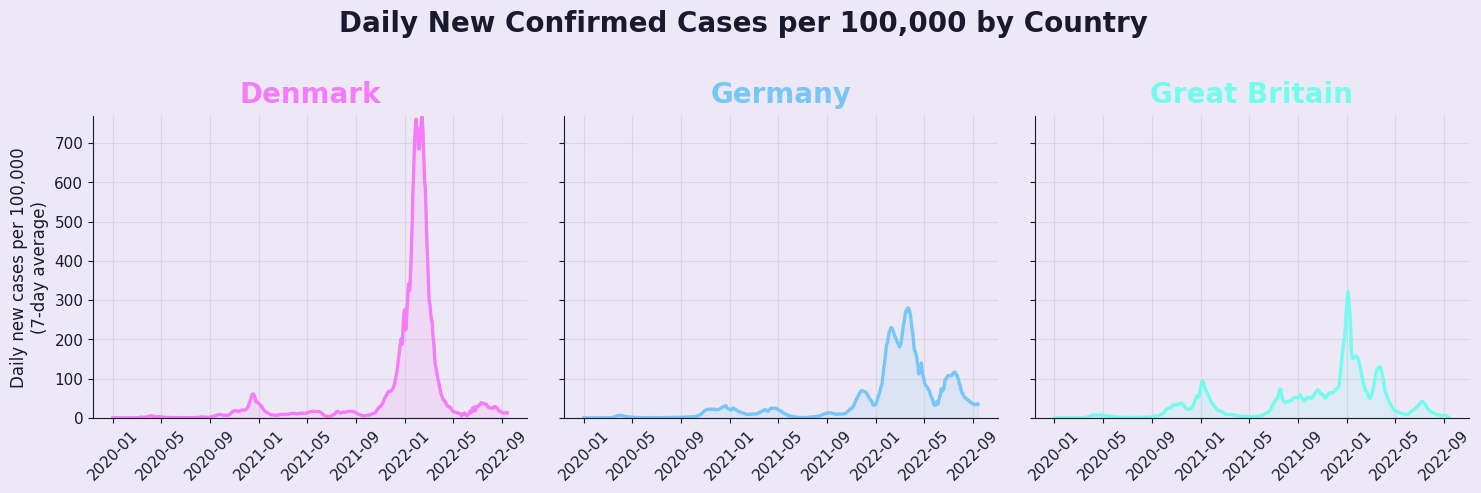

In [ ]:
# Shared y-axis maximum for fair comparison
cases_ymax = epi_compare["new_confirmed_per_100k_7d"].max()

# Prepare plotted data for saving
cases_small_multiples_df = epi_compare[
    ["date", "location_key", "country", "new_confirmed_per_100k_7d"]
].copy()

save_plot_data(
    cases_small_multiples_df,
    "small_multiples_daily_new_confirmed_cases_per_100k_7day_avg.csv"
)

# Create figure
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharex=True, sharey=True)

for ax, code in zip(axes, selected_countries):
    df_plot = epi_compare[epi_compare["location_key"] == code]
    c = COUNTRY_COLORS[code]

    ax.plot(
        df_plot["date"],
        df_plot["new_confirmed_per_100k_7d"],
        color=c,
        linewidth=2.4
    )

    ax.fill_between(
        df_plot["date"],
        df_plot["new_confirmed_per_100k_7d"],
        color=c,
        alpha=0.14
    )

    ax.set_title(country_names[code], color=c, pad=10)
    ax.tick_params(axis="x", labelrotation=45)
    ax.set_ylim(0, cases_ymax)

    style_ax(ax)

# Shared labels and title
axes[0].set_ylabel("Daily new cases per 100,000\n(7-day average)")
for ax in axes[1:]:
    ax.set_ylabel("")

fig.suptitle(
    "Daily New Confirmed Cases per 100,000 by Country",
    fontsize=20,
    fontweight="bold",
    y=1.02,
    color=TEXT
)

plt.tight_layout()

plt.show()

## Small multiples: daily new deaths per 100,000 by country

Each country is shown in its own panel, again with **shared x-axis and y-axis scales**.

The panels display the **7-day average of daily new COVID-19 deaths per 100,000 inhabitants**. Keeping the same scale across panels makes it possible to compare the relative size and timing of mortality waves fairly across the three countries.

This view is useful because it separates the country curves into individual panels while preserving a common visual scale for direct comparison.

Saved CSV to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/small_multiples_daily_new_deaths_per_100k_7day_avg.csv
Saved figure to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/small_multiples_daily_new_deaths_per_100k_7day_avg.png


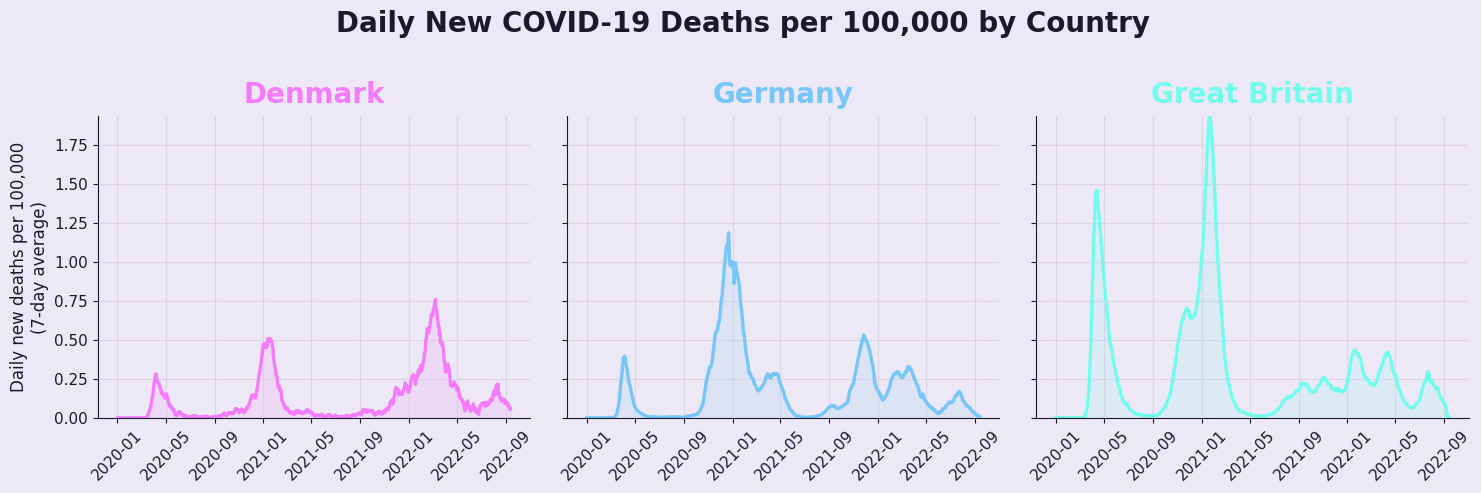

In [ ]:
# Shared y-axis maximum for fair comparison
deaths_ymax = epi_compare["new_deceased_per_100k_7d"].max()

# Prepare plotted data for saving
deaths_small_multiples_df = epi_compare[
    ["date", "location_key", "country", "new_deceased_per_100k_7d"]
].copy()

save_plot_data(
    deaths_small_multiples_df,
    "small_multiples_daily_new_deaths_per_100k_7day_avg.csv"
)

# Create figure
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharex=True, sharey=True)

for ax, code in zip(axes, selected_countries):
    df_plot = epi_compare[epi_compare["location_key"] == code]
    c = COUNTRY_COLORS[code]

    ax.plot(
        df_plot["date"],
        df_plot["new_deceased_per_100k_7d"],
        color=c,
        linewidth=2.4
    )

    ax.fill_between(
        df_plot["date"],
        df_plot["new_deceased_per_100k_7d"],
        color=c,
        alpha=0.14
    )

    ax.set_title(country_names[code], color=c, pad=10)
    ax.tick_params(axis="x", labelrotation=45)
    ax.set_ylim(0, deaths_ymax)

    style_ax(ax)

# Shared labels and title
axes[0].set_ylabel("Daily new deaths per 100,000\n(7-day average)")
for ax in axes[1:]:
    ax.set_ylabel("")

fig.suptitle(
    "Daily New COVID-19 Deaths per 100,000 by Country",
    fontsize=20,
    fontweight="bold",
    y=1.02,
    color=TEXT
)

plt.tight_layout()


plt.show()

## Small multiples: government stringency index by country

This figure shows each country's **7-day average government stringency index** in a separate panel while keeping the **same x-axis and y-axis scales** across all panels.

Because the Oxford stringency index is already standardized and bounded, shared axis scales are especially important for correct interpretation. This makes it easier to compare:

- when restrictions intensified,
- how high overall policy strictness became,
- and how long stricter periods lasted in each country.

Saved CSV to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/small_multiples_government_stringency_index_7day_avg.csv
Saved figure to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/small_multiples_government_stringency_index_7day_avg.png


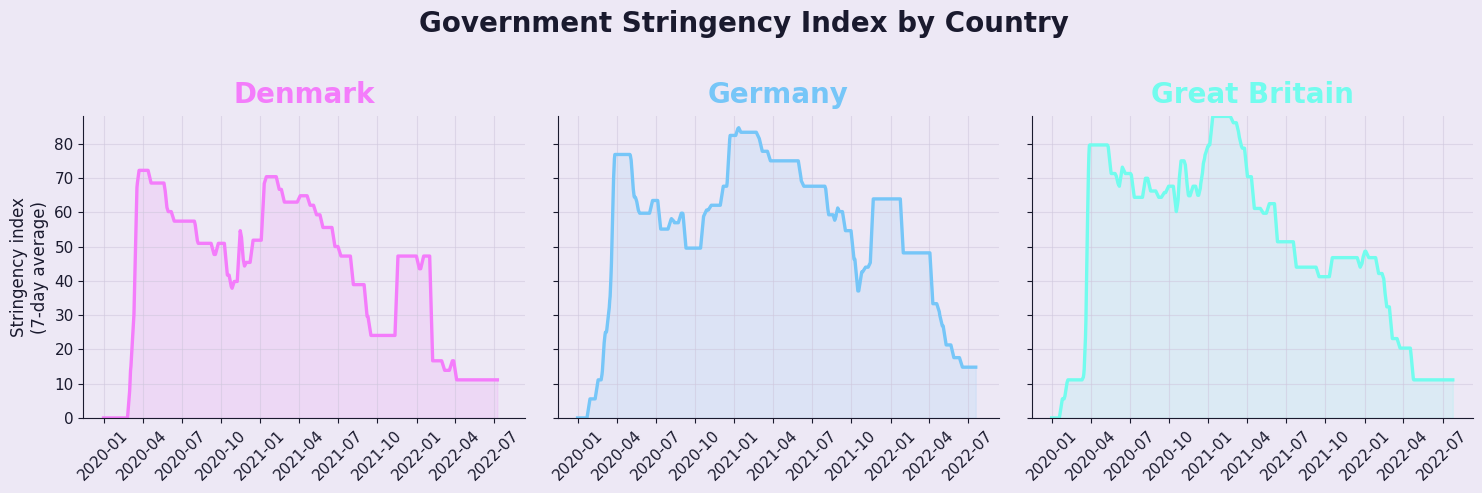

In [ ]:
# Shared y-axis maximum for fair comparison
stringency_ymax = gov_compare["stringency_7d"].max()

# Prepare plotted data for saving
stringency_small_multiples_df = gov_compare[
    ["date", "location_key", "country", "stringency_7d"]
].copy()

save_plot_data(
    stringency_small_multiples_df,
    "small_multiples_government_stringency_index_7day_avg.csv"
)

# Create figure
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharex=True, sharey=True)

for ax, code in zip(axes, selected_countries):
    df_plot = gov_compare[gov_compare["location_key"] == code]
    c = COUNTRY_COLORS[code]

    ax.plot(
        df_plot["date"],
        df_plot["stringency_7d"],
        color=c,
        linewidth=2.4
    )

    ax.fill_between(
        df_plot["date"],
        df_plot["stringency_7d"],
        color=c,
        alpha=0.14
    )

    ax.set_title(country_names[code], color=c, pad=10)
    ax.tick_params(axis="x", labelrotation=45)
    ax.set_ylim(0, stringency_ymax)

    style_ax(ax)

# Shared labels and title
axes[0].set_ylabel("Stringency index\n(7-day average)")
for ax in axes[1:]:
    ax.set_ylabel("")

fig.suptitle(
    "Government Stringency Index by Country",
    fontsize=20,
    fontweight="bold",
    y=1.02,
    color=TEXT
)

plt.tight_layout()


plt.show()

## Daily new confirmed cases and government stringency by country

Each panel combines an epidemiological measure with a policy measure for one country:

- **daily new confirmed cases per 100,000 inhabitants** on the left axis,
- **government stringency index** on the right axis.

Both measures are shown as **7-day averages** to reduce day-to-day noise.

The **left axis is shared across all countries**, which makes the case comparison fair.  
The **right axis is also shared**, which keeps stringency directly comparable.

This figure is useful because it lets us visually compare how infection waves and policy strictness evolved together within each country, while still preserving cross-country comparability.

Saved CSV to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/cases_and_government_stringency_by_country.csv
Saved figure to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/daily_new_confirmed_cases_and_government_stringency_by_country.png


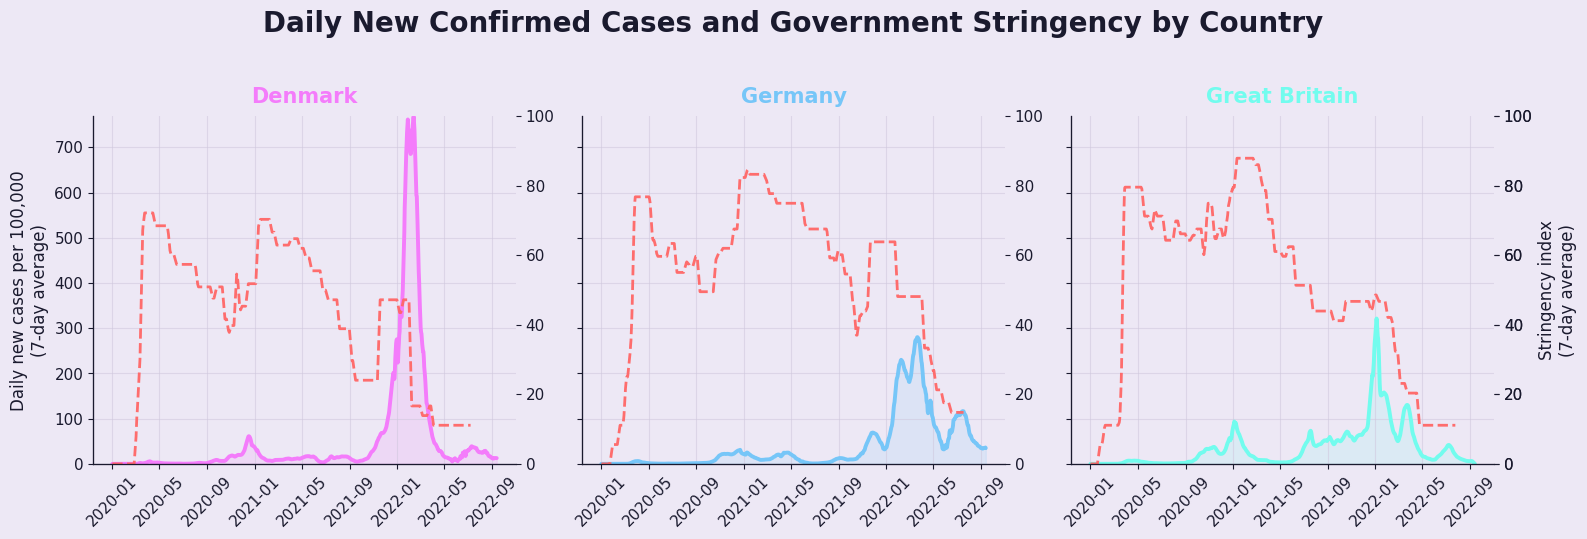

In [ ]:
# Shared axis limits for fair comparison
cases_ymax = epi_compare["new_confirmed_per_100k_7d"].max()
stringency_ymax = 100  # bounded index, clearer than using dataset max

# Prepare plotted data for saving
cases_stringency_df = (
    epi_compare[["date", "location_key", "country", "new_confirmed_per_100k_7d"]]
    .merge(
        gov_compare[["date", "location_key", "stringency_7d"]],
        on=["date", "location_key"],
        how="left"
    )
)

save_plot_data(
    cases_stringency_df,
    "cases_and_government_stringency_by_country.csv"
)

# Create figure
fig, axes = plt.subplots(1, 3, figsize=(16, 5.2), sharex=True, sharey=True)

for ax, code in zip(axes, selected_countries):
    df_plot = cases_stringency_df[cases_stringency_df["location_key"] == code].sort_values("date")
    c = COUNTRY_COLORS[code]

    # Left axis: cases per 100k
    ax.plot(
        df_plot["date"],
        df_plot["new_confirmed_per_100k_7d"],
        color=c,
        linewidth=2.8,
        solid_capstyle="round"
    )

    ax.fill_between(
        df_plot["date"],
        df_plot["new_confirmed_per_100k_7d"],
        color=c,
        alpha=0.14
    )

    ax.set_title(
        country_names[code],
        color=c,
        pad=10,
        fontsize=15,
        fontweight="bold"
    )
    ax.set_ylim(0, cases_ymax)
    ax.tick_params(axis="x", labelrotation=45)

    style_ax(ax)

    # Right axis: stringency
    ax2 = ax.twinx()
    ax2.plot(
        df_plot["date"],
        df_plot["stringency_7d"],
        color=POLICY,
        linestyle="--",
        linewidth=2.0,
        alpha=0.95
    )
    ax2.set_ylim(0, stringency_ymax)
    ax2.tick_params(axis="y", colors=TEXT)
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_color(TEXT)
    ax2.set_facecolor(BG)
    ax2.grid(False)

# Shared labels
axes[0].set_ylabel("Daily new cases per 100,000\n(7-day average)")
for ax in axes[1:]:
    ax.set_ylabel("")

# Right-side labels only on last subplot to reduce clutter
for ax in axes[:-1]:
    ax_right = ax.twinx()
    ax_right.set_yticks([])
    ax_right.set_ylabel("")

# Add right-axis label only to final panel
final_ax2 = axes[-1].twinx()
final_ax2.set_ylim(0, stringency_ymax)
final_ax2.set_ylabel("Stringency index\n(7-day average)", color=TEXT)
final_ax2.tick_params(axis="y", colors=TEXT)
final_ax2.spines["top"].set_visible(False)
final_ax2.spines["right"].set_color(TEXT)
final_ax2.set_facecolor(BG)
final_ax2.grid(False)

fig.suptitle(
    "Daily New Confirmed Cases and Government Stringency by Country",
    fontsize=20,
    fontweight="bold",
    y=1.03,
    color=TEXT
)

plt.tight_layout()


plt.show()

## Interactive comparison: daily new confirmed cases per 100,000 over time

This interactive figure allows the user to:

- zoom into specific periods,
- toggle countries on and off,
- and inspect exact values by hovering.

The chart shows the **7-day average of daily new confirmed cases per 100,000 inhabitants**, which makes the comparison more meaningful across countries of different population sizes.

This interactive view is especially useful for exploring the timing, duration, and relative size of different waves in Denmark, Germany, and Great Britain.

In [ ]:
# Prepare plotted data for interactive figure
interactive_cases_df = epi_compare[
    ["date", "location_key", "country", "new_confirmed_per_100k_7d"]
].copy()

# Save plotted data as CSV
save_plot_data(
    interactive_cases_df,
    "interactive_daily_new_confirmed_cases_per_100k_7day_avg.csv"
)

# Create interactive figure
fig = px.line(
    interactive_cases_df,
    x="date",
    y="new_confirmed_per_100k_7d",
    color="country",
    color_discrete_map={
        "Denmark": DENMARK,
        "Germany": GERMANY,
        "Great Britain": UK,
    },
    title="Interactive Comparison: Daily New Confirmed Cases per 100,000",
)

fig.update_traces(
    line=dict(width=3),
    hovertemplate=(
        "<b>%{fullData.name}</b><br>"
        "Date: %{x|%Y-%m-%d}<br>"
        "Daily new cases per 100,000 (7-day avg): %{y:.2f}<extra></extra>"
    )
)

fig.update_layout(
    paper_bgcolor=BG,
    plot_bgcolor=BG,
    font=dict(
        family="Aptos, DejaVu Sans, Arial, sans-serif",
        color=TEXT,
        size=14
    ),
    title=dict(
        text="Interactive Comparison: Daily New Confirmed Cases per 100,000",
        font=dict(size=24, color=TEXT),
        x=0.03,
        xanchor="left"
    ),
    xaxis_title="",
    yaxis_title="Daily new cases per 100,000 (7-day average)",
    legend_title="Country",
    hovermode="x unified"
)

fig.update_xaxes(
    showgrid=True,
    gridcolor=GRID,
    linecolor=TEXT,
    tickcolor=TEXT
)

fig.update_yaxes(
    showgrid=True,
    gridcolor=GRID,
    linecolor=TEXT,
    tickcolor=TEXT
)


# Display in notebook
fig.show()

Saved CSV to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/interactive_daily_new_confirmed_cases_per_100k_7day_avg.csv
Saved interactive figure to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/interactive_daily_new_confirmed_cases_per_100k_7day_avg.html


## Interactive comparison: government stringency over time

This interactive chart supports comparison of the **7-day average government stringency index** across Denmark, Germany, and Great Britain.

It allows the user to:

- zoom into specific periods,
- toggle countries on and off,
- and inspect exact values by hovering.

Because the Oxford stringency index is already standardized, it can be compared directly across countries. This interactive view is especially useful for exploring when restrictions intensified, how strict they became, and how long they remained in place.

In [ ]:
# Prepare plotted data for interactive figure
interactive_stringency_df = gov_compare[
    ["date", "location_key", "country", "stringency_7d"]
].copy()

# Save plotted data as CSV
save_plot_data(
    interactive_stringency_df,
    "interactive_government_stringency_index_7day_avg.csv"
)

# Create interactive figure
fig = px.line(
    interactive_stringency_df,
    x="date",
    y="stringency_7d",
    color="country",
    color_discrete_map={
        "Denmark": DENMARK,
        "Germany": GERMANY,
        "Great Britain": UK,
    },
    title="Interactive Comparison: Government Stringency Index",
)

fig.update_traces(
    line=dict(width=3),
    hovertemplate=(
        "<b>%{fullData.name}</b><br>"
        "Date: %{x|%Y-%m-%d}<br>"
        "Stringency index (7-day avg): %{y:.2f}<extra></extra>"
    )
)

fig.update_layout(
    paper_bgcolor=BG,
    plot_bgcolor=BG,
    font=dict(
        family="Aptos, DejaVu Sans, Arial, sans-serif",
        color=TEXT,
        size=14
    ),
    title=dict(
        text="Interactive Comparison: Government Stringency Index",
        font=dict(size=24, color=TEXT),
        x=0.03,
        xanchor="left"
    ),
    xaxis_title="",
    yaxis_title="Stringency index (7-day average)",
    legend_title="Country",
    hovermode="x unified"
)

fig.update_xaxes(
    showgrid=True,
    gridcolor=GRID,
    linecolor=TEXT,
    tickcolor=TEXT
)

fig.update_yaxes(
    showgrid=True,
    gridcolor=GRID,
    linecolor=TEXT,
    tickcolor=TEXT,
    range=[0, 100]
)


# Display in notebook
fig.show()

Saved CSV to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/interactive_government_stringency_index_7day_avg.csv
Saved interactive figure to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/interactive_government_stringency_index_7day_avg.html


## Interactive comparison: daily new deaths per 100,000 over time

This interactive chart supports comparison of the **7-day average of daily new COVID-19 deaths per 100,000 inhabitants** across Denmark, Germany, and Great Britain.

It allows the user to:

- zoom into specific periods,
- toggle countries on and off,
- and inspect exact values by hovering.

This is useful for exploring the timing, duration, and relative size of mortality waves across the three countries.

In [ ]:
# Prepare plotted data for interactive figure
interactive_deaths_df = epi_compare[
    ["date", "location_key", "country", "new_deceased_per_100k_7d"]
].copy()

# Save plotted data as CSV
save_plot_data(
    interactive_deaths_df,
    "interactive_daily_new_deaths_per_100k_7day_avg.csv"
)

# Create interactive figure
fig = px.line(
    interactive_deaths_df,
    x="date",
    y="new_deceased_per_100k_7d",
    color="country",
    color_discrete_map={
        "Denmark": DENMARK,
        "Germany": GERMANY,
        "Great Britain": UK,
    },
    title="Interactive Comparison: Daily New Deaths per 100,000",
)

fig.update_traces(
    line=dict(width=3),
    hovertemplate=(
        "<b>%{fullData.name}</b><br>"
        "Date: %{x|%Y-%m-%d}<br>"
        "Daily new deaths per 100,000 (7-day avg): %{y:.3f}<extra></extra>"
    )
)

fig.update_layout(
    paper_bgcolor=BG,
    plot_bgcolor=BG,
    font=dict(
        family="Aptos, DejaVu Sans, Arial, sans-serif",
        color=TEXT,
        size=14
    ),
    title=dict(
        text="Interactive Comparison: Daily New Deaths per 100,000",
        font=dict(size=24, color=TEXT),
        x=0.03,
        xanchor="left"
    ),
    xaxis_title="",
    yaxis_title="Daily new deaths per 100,000 (7-day average)",
    legend_title="Country",
    hovermode="x unified"
)

fig.update_xaxes(showgrid=True, gridcolor=GRID, linecolor=TEXT, tickcolor=TEXT)
fig.update_yaxes(showgrid=True, gridcolor=GRID, linecolor=TEXT, tickcolor=TEXT)


fig.show()

Saved CSV to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/interactive_daily_new_deaths_per_100k_7day_avg.csv
Saved interactive figure to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/interactive_daily_new_deaths_per_100k_7day_avg.html


## Interactive comparison of daily new confirmed cases per 100,000 with date range controls

This interactive figure adds both a **date range slider** and **range selector buttons**, allowing the user to quickly focus on shorter phases of the pandemic, such as 6 months, 1 year, or 2 years.

The chart shows the **7-day average of daily new confirmed cases per 100,000 inhabitants**, which makes the comparison more meaningful across countries with different population sizes.

This view is especially useful for exploring when specific waves began, peaked, and declined in Denmark, Germany, and Great Britain.

In [ ]:
import plotly.graph_objects as go

# Prepare plotted data for interactive figure
interactive_cases_range_df = epi_compare[
    ["date", "location_key", "country", "new_confirmed_per_100k_7d"]
].copy()

# Save plotted data as CSV
save_plot_data(
    interactive_cases_range_df,
    "interactive_daily_new_confirmed_cases_per_100k_with_date_controls.csv"
)

# Create interactive figure
fig = go.Figure()

for code in selected_countries:
    df_country = interactive_cases_range_df[
        interactive_cases_range_df["location_key"] == code
    ].sort_values("date")

    fig.add_trace(
        go.Scatter(
            x=df_country["date"],
            y=df_country["new_confirmed_per_100k_7d"],
            mode="lines",
            name=country_names[code],
            line=dict(color=COUNTRY_COLORS[code], width=3),
            hovertemplate=(
                "<b>%{fullData.name}</b><br>"
                "Date: %{x|%Y-%m-%d}<br>"
                "Daily new cases per 100,000 (7-day avg): %{y:.2f}<extra></extra>"
            )
        )
    )

fig.update_layout(
    paper_bgcolor=BG,
    plot_bgcolor=BG,
    font=dict(
        family="Aptos, DejaVu Sans, Arial, sans-serif",
        color=TEXT,
        size=14
    ),
    title=dict(
        text="Interactive Comparison: Daily New Confirmed Cases per 100,000",
        font=dict(size=24, color=TEXT),
        x=0.03,
        xanchor="left"
    ),
    xaxis_title="",
    yaxis_title="Daily new cases per 100,000 (7-day average)",
    hovermode="x unified",
    legend_title="Country"
)

fig.update_xaxes(
    showgrid=True,
    gridcolor=GRID,
    linecolor=TEXT,
    tickcolor=TEXT,
    rangeslider_visible=True,
    rangeselector=dict(
        bgcolor=ACCENT_2,
        activecolor=ACCENT_4,
        buttons=list([
            dict(count=6, label="6m", step="month", stepmode="backward"),
            dict(count=1, label="1y", step="year", stepmode="backward"),
            dict(count=2, label="2y", step="year", stepmode="backward"),
            dict(step="all", label="All")
        ])
    )
)

fig.update_yaxes(
    showgrid=True,
    gridcolor=GRID,
    linecolor=TEXT,
    tickcolor=TEXT
)


# Display in notebook
fig.show()

Saved CSV to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/interactive_daily_new_confirmed_cases_per_100k_with_date_controls.csv
Saved interactive figure to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/interactive_daily_new_confirmed_cases_per_100k_with_date_controls.html


## Interactive comparison with year and metric controls

This interactive figure allows the user to switch between:

- **daily new confirmed cases per 100,000 inhabitants**
- **daily new deaths per 100,000 inhabitants**

and between available years.

All values are shown as **7-day averages**, which reduces short-term reporting noise. Using per-capita measures makes the comparison more meaningful across Denmark, Germany, and Great Britain, since the three countries differ in population size.

This view is useful for focusing on specific phases of the pandemic and comparing how the three countries evolved within the same time window.

In [ ]:
import plotly.graph_objects as go

# Prepare plotted data
plot_df = epi_compare[
    [
        "date",
        "location_key",
        "country",
        "new_confirmed_per_100k_7d",
        "new_deceased_per_100k_7d"
    ]
].copy()

plot_df["year"] = plot_df["date"].dt.year
available_years = sorted(plot_df["year"].dropna().unique())

# Save plotted data as CSV
save_plot_data(
    plot_df,
    "interactive_country_comparison_cases_deaths_per_100k_by_year.csv"
)

# Create figure
fig = go.Figure()

trace_lookup = []

for metric_name, metric_col, value_label, value_format in [
    (
        "Cases",
        "new_confirmed_per_100k_7d",
        "Daily new cases per 100,000 (7-day avg)",
        "%{y:.2f}"
    ),
    (
        "Deaths",
        "new_deceased_per_100k_7d",
        "Daily new deaths per 100,000 (7-day avg)",
        "%{y:.3f}"
    ),
]:
    for year in available_years:
        df_year = plot_df[plot_df["year"] == year]

        for code in selected_countries:
            df_country = df_year[df_year["location_key"] == code].sort_values("date")

            fig.add_trace(
                go.Scatter(
                    x=df_country["date"],
                    y=df_country[metric_col],
                    mode="lines",
                    name=country_names[code],
                    line=dict(color=COUNTRY_COLORS[code], width=3),
                    visible=(metric_name == "Cases" and year == available_years[0]),
                    hovertemplate=(
                        "<b>%{fullData.name}</b><br>"
                        "Date: %{x|%Y-%m-%d}<br>"
                        f"{value_label}: {value_format}<extra></extra>"
                    )
                )
            )

            trace_lookup.append((metric_name, year, code))

def visibility_mask(metric, year):
    return [
        (m == metric and y == year)
        for (m, y, c) in trace_lookup
    ]

metric_year_buttons = []

for metric_name, y_title in [
    ("Cases", "Daily new cases per 100,000 (7-day average)"),
    ("Deaths", "Daily new deaths per 100,000 (7-day average)")
]:
    for year in available_years:
        metric_year_buttons.append(
            dict(
                label=f"{metric_name} — {year}",
                method="update",
                args=[
                    {"visible": visibility_mask(metric_name, year)},
                    {
                        "title": f"Interactive Country Comparison — {metric_name} in {year}",
                        "yaxis": {"title": y_title}
                    }
                ]
            )
        )

fig.update_layout(
    paper_bgcolor=BG,
    plot_bgcolor=BG,
    font=dict(
        family="Aptos, DejaVu Sans, Arial, sans-serif",
        color=TEXT,
        size=14
    ),
    title=dict(
        text=f"Interactive Country Comparison — Cases in {available_years[0]}",
        font=dict(size=24, color=TEXT),
        x=0.03,
        xanchor="left"
    ),
    xaxis_title="",
    yaxis_title="Daily new cases per 100,000 (7-day average)",
    hovermode="x unified",
    legend_title="Country",
    updatemenus=[
        dict(
            type="dropdown",
            direction="down",
            x=1.02,
            y=1.00,
            showactive=True,
            bgcolor=ACCENT_2,
            buttons=metric_year_buttons
        )
    ]
)

fig.update_xaxes(
    showgrid=True,
    gridcolor=GRID,
    linecolor=TEXT,
    tickcolor=TEXT,
    rangeslider_visible=True
)

fig.update_yaxes(
    showgrid=True,
    gridcolor=GRID,
    linecolor=TEXT,
    tickcolor=TEXT
)


# Display in notebook
fig.show()

Saved CSV to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/interactive_country_comparison_cases_deaths_per_100k_by_year.csv
Saved interactive figure to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/interactive_country_comparison_cases_deaths_per_100k_by_year.html


## Monthly aggregation for heatmaps

To compare the three countries over time more clearly, we aggregate the daily data to the **monthly** level.

For each country and month, we compute:

- average monthly **daily new confirmed cases per 100,000 inhabitants**,
- average monthly **daily new deaths per 100,000 inhabitants**,
- average monthly **government stringency index**.

These monthly summaries make it easier to identify broader temporal patterns and are especially useful for heatmaps, where the goal is to compare intensity across countries and time at a glance.

In [ ]:
# Monthly aggregation for epidemiology data
epi_monthly = epi_compare.copy()
epi_monthly["year"] = epi_monthly["date"].dt.year
epi_monthly["month"] = epi_monthly["date"].dt.month
epi_monthly["month_name"] = epi_monthly["date"].dt.strftime("%b")

epi_monthly_agg = (
    epi_monthly.groupby(
        ["location_key", "country", "year", "month", "month_name"],
        as_index=False
    )
    .agg(
        avg_cases_per_100k=("new_confirmed_per_100k_7d", "mean"),
        avg_deaths_per_100k=("new_deceased_per_100k_7d", "mean")
    )
)

# Monthly aggregation for government response data
gov_monthly = gov_compare.copy()
gov_monthly["year"] = gov_monthly["date"].dt.year
gov_monthly["month"] = gov_monthly["date"].dt.month
gov_monthly["month_name"] = gov_monthly["date"].dt.strftime("%b")

gov_monthly_agg = (
    gov_monthly.groupby(
        ["location_key", "country", "year", "month", "month_name"],
        as_index=False
    )
    .agg(
        avg_stringency=("stringency_7d", "mean")
    )
)


# Display in notebook as clean tables
display(epi_monthly_agg.head())
display(gov_monthly_agg.head())

Saved CSV to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/monthly_aggregated_epidemiology_per_100k.csv
Saved CSV to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/monthly_aggregated_government_stringency.csv


,location_key,country,year,month,month_name,avg_cases_per_100k,avg_deaths_per_100k
0,DE,Germany,2020,1,Jan,0.000256,0.000000
1,DE,Germany,2020,2,Feb,0.003251,0.000041
2,DE,Germany,2020,3,Mar,2.507261,0.082656
3,DE,Germany,2020,4,Apr,3.794540,0.246658
4,DE,Germany,2020,5,May,0.845533,0.032020


,location_key,country,year,month,month_name,avg_stringency
0,DE,Germany,2020,1,Jan,0.896774
1,DE,Germany,2020,2,Feb,8.772906
2,DE,Germany,2020,3,Mar,43.167926
3,DE,Germany,2020,4,Apr,76.850000
4,DE,Germany,2020,5,May,65.499677


## Heatmap: monthly daily new cases per 100,000 by country

This heatmap shows the **average monthly level of daily new confirmed cases per 100,000 inhabitants** for Denmark, Germany, and Great Britain.

Viewing one year at a time makes it easier to compare the timing and intensity of waves across countries. The monthly format is especially useful for seeing broader seasonal patterns and for identifying when case levels were relatively low, moderate, or high within the same calendar year.

In [ ]:
year_to_plot = 2021

month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

heat_cases = epi_monthly_agg[epi_monthly_agg["year"] == year_to_plot].copy()
heat_cases["month_name"] = pd.Categorical(
    heat_cases["month_name"],
    categories=month_order,
    ordered=True
)
heat_cases = heat_cases.sort_values(["country", "month"])

# Save plotted data as CSV
save_plot_data(
    heat_cases,
    f"heatmap_monthly_cases_per_100k_{year_to_plot}.csv"
)

fig = px.density_heatmap(
    heat_cases,
    x="month_name",
    y="country",
    z="avg_cases_per_100k",
    histfunc="avg",
    color_continuous_scale=[
        [0.00, "#EFDEF0"],
        [0.20, "#DEDAF2"],
        [0.40, "#F6B4B4"],
        [0.60, "#FF8A8A"],
        [0.80, "#FF6666"],
        [1.00, "#C94F4F"],
    ],
    title=f"Monthly Daily New Cases per 100,000 by Country — {year_to_plot}"
)

fig.update_layout(
    paper_bgcolor=BG,
    plot_bgcolor=BG,
    font=dict(
        family="Aptos, DejaVu Sans, Arial, sans-serif",
        color=TEXT,
        size=14
    ),
    title=dict(
        text=f"Monthly Daily New Cases per 100,000 by Country — {year_to_plot}",
        font=dict(size=24, color=TEXT),
        x=0.03,
        xanchor="left"
    ),
    xaxis_title="Month",
    yaxis_title="Country",
    coloraxis_colorbar=dict(
        title=dict(
            text="Avg daily cases per 100,000",
            font=dict(color=TEXT)
        ),
        tickfont=dict(color=TEXT)
    )
)

fig.update_xaxes(showgrid=False, linecolor=TEXT, tickcolor=TEXT)
fig.update_yaxes(showgrid=False, linecolor=TEXT, tickcolor=TEXT)


# Display in notebook
fig.show()

Saved CSV to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/heatmap_monthly_cases_per_100k_2021.csv
Saved interactive figure to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/heatmap_monthly_cases_per_100k_2021.html


## Heatmap: monthly daily new deaths per 100,000 by country

This heatmap shows the **average monthly level of daily new COVID-19 deaths per 100,000 inhabitants** for Denmark, Germany, and Great Britain.

Viewing one year at a time makes it easier to compare the timing and intensity of mortality waves across countries. The monthly format helps highlight broader patterns that may be less visible in the daily time series.

In [ ]:
year_to_plot = 2021

heat_deaths = epi_monthly_agg[epi_monthly_agg["year"] == year_to_plot].copy()
heat_deaths["month_name"] = pd.Categorical(
    heat_deaths["month_name"],
    categories=month_order,
    ordered=True
)
heat_deaths = heat_deaths.sort_values(["country", "month"])

# Save plotted data as CSV
save_plot_data(
    heat_deaths,
    f"heatmap_monthly_deaths_per_100k_{year_to_plot}.csv"
)

fig = px.density_heatmap(
    heat_deaths,
    x="month_name",
    y="country",
    z="avg_deaths_per_100k",
    histfunc="avg",
    color_continuous_scale=[
        [0.00, "#EFDEF0"],
        [0.20, "#E7B7C0"],
        [0.40, "#D88A9B"],
        [0.60, "#C85F72"],
        [0.80, "#B33C50"],
        [1.00, "#7A1E2C"],
    ],
    title=f"Monthly Daily New Deaths per 100,000 by Country — {year_to_plot}"
)

fig.update_layout(
    paper_bgcolor=BG,
    plot_bgcolor=BG,
    font=dict(
        family="Aptos, DejaVu Sans, Arial, sans-serif",
        color=TEXT,
        size=14
    ),
    title=dict(
        text=f"Monthly Daily New Deaths per 100,000 by Country — {year_to_plot}",
        font=dict(size=24, color=TEXT),
        x=0.03,
        xanchor="left"
    ),
    xaxis_title="Month",
    yaxis_title="Country",
    coloraxis_colorbar=dict(
        title=dict(
            text="Avg daily deaths per 100,000",
            font=dict(color=TEXT)
        ),
        tickfont=dict(color=TEXT)
    )
)

fig.update_xaxes(showgrid=False, linecolor=TEXT, tickcolor=TEXT)
fig.update_yaxes(showgrid=False, linecolor=TEXT, tickcolor=TEXT)


# Display in notebook
fig.show()

Saved CSV to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/heatmap_monthly_deaths_per_100k_2021.csv
Saved interactive figure to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/heatmap_monthly_deaths_per_100k_2021.html


## Heatmap: monthly government stringency by country

This heatmap shows the **average monthly government stringency index** for Denmark, Germany, and Great Britain.

Viewing one year at a time makes it easier to compare when restrictions intensified, how strict policy responses became, and how long stricter periods remained in place. Because the Oxford stringency index is already standardized, it can be compared directly across countries.

In [ ]:
year_to_plot = 2021

heat_stringency = gov_monthly_agg[gov_monthly_agg["year"] == year_to_plot].copy()
heat_stringency["month_name"] = pd.Categorical(
    heat_stringency["month_name"],
    categories=month_order,
    ordered=True
)
heat_stringency = heat_stringency.sort_values(["country", "month"])

# Save plotted data as CSV
save_plot_data(
    heat_stringency,
    f"heatmap_monthly_government_stringency_{year_to_plot}.csv"
)

fig = px.density_heatmap(
    heat_stringency,
    x="month_name",
    y="country",
    z="avg_stringency",
    histfunc="avg",
    color_continuous_scale=[
        [0.00, "#E1ECF3"],
        [0.25, "#CDE1ED"],
        [0.50, "#DEDAF2"],
        [0.75, "#D8ECEA"],
        [1.00, "#FF6666"],
    ],
    title=f"Monthly Government Stringency by Country — {year_to_plot}"
)

fig.update_layout(
    paper_bgcolor=BG,
    plot_bgcolor=BG,
    font=dict(
        family="Aptos, DejaVu Sans, Arial, sans-serif",
        color=TEXT,
        size=14
    ),
    title=dict(
        text=f"Monthly Government Stringency by Country — {year_to_plot}",
        font=dict(size=24, color=TEXT),
        x=0.03,
        xanchor="left"
    ),
    xaxis_title="Month",
    yaxis_title="Country",
    coloraxis_colorbar=dict(
        title=dict(
            text="Avg stringency",
            font=dict(color=TEXT)
        ),
        tickfont=dict(color=TEXT)
    )
)

fig.update_xaxes(showgrid=False, linecolor=TEXT, tickcolor=TEXT)
fig.update_yaxes(showgrid=False, linecolor=TEXT, tickcolor=TEXT)


# Display in notebook
fig.show()

Saved CSV to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/heatmap_monthly_government_stringency_2021.csv
Saved interactive figure to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/heatmap_monthly_government_stringency_2021.html


## Interactive heatmap with year dropdown

This interactive heatmap allows the user to switch between years and compare the **average monthly level of daily new confirmed cases per 100,000 inhabitants** across Denmark, Germany, and Great Britain.

The dropdown makes it easy to focus on one calendar year at a time, which helps reveal when case intensity was low, moderate, or high within the same monthly structure.

In [ ]:
import plotly.graph_objects as go

# Save source data used for the interactive heatmap
save_plot_data(
    epi_monthly_agg,
    "interactive_heatmap_monthly_cases_per_100k_all_years.csv"
)

fig = go.Figure()

heat_years = sorted(epi_monthly_agg["year"].dropna().unique())
trace_info = []

for year in heat_years:
    heat_cases = epi_monthly_agg[epi_monthly_agg["year"] == year].copy()
    heat_cases["month_name"] = pd.Categorical(
        heat_cases["month_name"],
        categories=month_order,
        ordered=True
    )
    heat_cases = heat_cases.sort_values(["country", "month"])

    pivot_df = (
        heat_cases
        .pivot(index="country", columns="month_name", values="avg_cases_per_100k")
        .reindex(columns=month_order)
    )

    fig.add_trace(
        go.Heatmap(
            z=pivot_df.values,
            x=pivot_df.columns,
            y=pivot_df.index,
            colorscale=[
                [0.00, "#EFDEF0"],
                [0.20, "#DEDAF2"],
                [0.40, "#F6B4B4"],
                [0.60, "#FF8A8A"],
                [0.80, "#FF6666"],
                [1.00, "#C94F4F"],
            ],
            visible=(year == heat_years[0]),
            colorbar=dict(
                title=dict(
                    text="Avg daily cases per 100,000",
                    font=dict(color=TEXT)
                ),
                tickfont=dict(color=TEXT)
            ),
            hovertemplate=(
                "Country: %{y}<br>"
                "Month: %{x}<br>"
                "Avg daily cases per 100,000: %{z:.2f}<extra></extra>"
            )
        )
    )
    trace_info.append(year)

buttons = []
for year in heat_years:
    buttons.append(
        dict(
            label=str(year),
            method="update",
            args=[
                {"visible": [y == year for y in trace_info]},
                {"title": f"Monthly Daily New Cases per 100,000 by Country — {year}"}
            ]
        )
    )

fig.update_layout(
    paper_bgcolor=BG,
    plot_bgcolor=BG,
    font=dict(
        family="Aptos, DejaVu Sans, Arial, sans-serif",
        color=TEXT,
        size=14
    ),
    title=dict(
        text=f"Monthly Daily New Cases per 100,000 by Country — {heat_years[0]}",
        font=dict(size=24, color=TEXT),
        x=0.03,
        xanchor="left"
    ),
    xaxis_title="Month",
    yaxis_title="Country",
    updatemenus=[
        dict(
            type="dropdown",
            direction="down",
            x=1.02,
            y=1.00,
            showactive=True,
            bgcolor=ACCENT_2,
            buttons=buttons
        )
    ]
)

fig.update_xaxes(showgrid=False, linecolor=TEXT, tickcolor=TEXT)
fig.update_yaxes(showgrid=False, linecolor=TEXT, tickcolor=TEXT)


# Display in notebook
fig.show()

Saved CSV to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/interactive_heatmap_monthly_cases_per_100k_all_years.csv
Saved interactive figure to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/interactive_heatmap_monthly_cases_per_100k_all_years.html


## Population-adjusted comparison: daily new confirmed cases and government response

To compare Denmark, Germany, and Great Britain more fairly, we use **population-adjusted case rates** rather than raw case counts.

In this figure, each country panel combines:

- **daily new confirmed cases per 100,000 inhabitants** on the left axis,
- **government stringency index** on the right axis.

Both series are shown as **7-day averages** to reduce day-to-day reporting noise.

This makes the case curves more comparable across countries with different population sizes, while still allowing us to compare how infection waves and policy strictness evolved together within each country.

To ensure fair visual comparison:

- all country panels use the **same x-axis scale**,
- the **left y-axis** is shared across countries,
- and the **right y-axis** is also shared across countries.

Saved CSV to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/population_adjusted_cases_and_government_response_by_country.csv
Saved figure to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/population_adjusted_cases_and_government_response_by_country.png


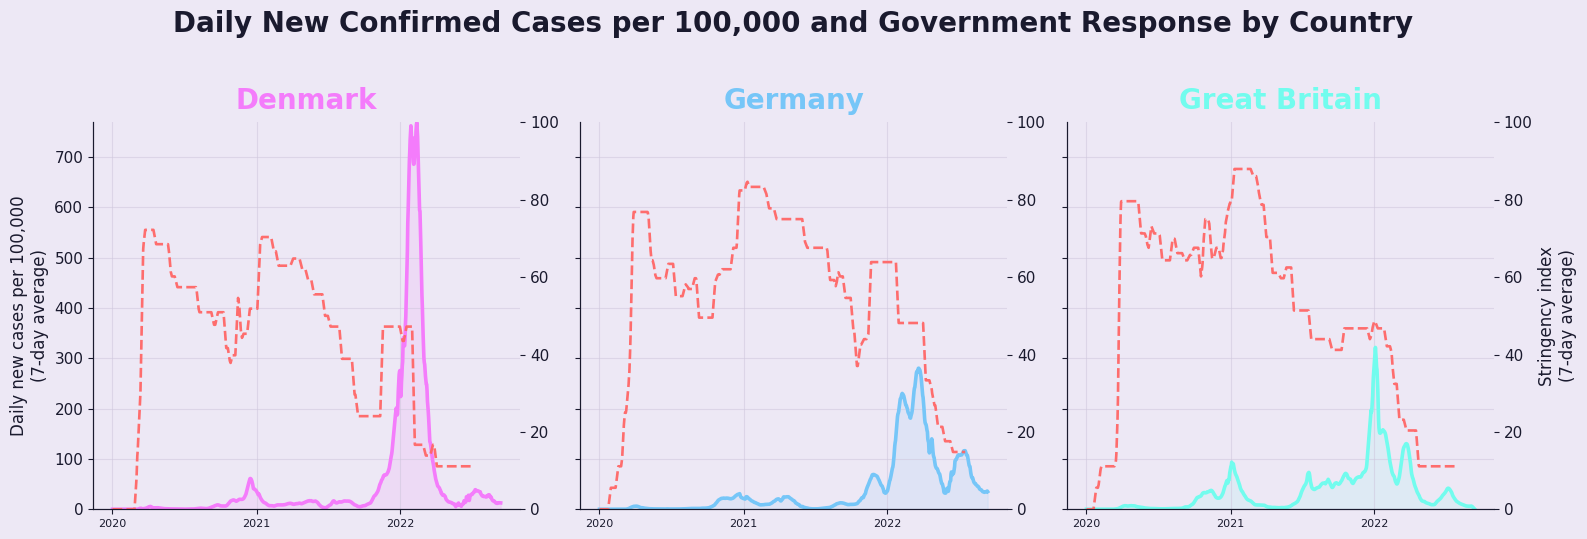

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Prepare plotted data by combining epidemiology and stringency
cases_stringency_pop_df = (
    epi_compare[["date", "location_key", "country", "new_confirmed_per_100k_7d"]]
    .merge(
        gov_compare[["date", "location_key", "stringency_7d"]],
        on=["date", "location_key"],
        how="left"
    )
)

# Save plotted data as CSV
save_plot_data(
    cases_stringency_pop_df,
    "population_adjusted_cases_and_government_response_by_country.csv"
)

# Shared axis limits for fair comparison
cases_per_100k_ymax = cases_stringency_pop_df["new_confirmed_per_100k_7d"].max()
stringency_ymax = 100  # bounded index

# Create figure
fig, axes = plt.subplots(1, 3, figsize=(16, 5.2), sharex=True, sharey=True)
right_axes = []

for ax, code in zip(axes, selected_countries):
    df_plot = (
        cases_stringency_pop_df[cases_stringency_pop_df["location_key"] == code]
        .sort_values("date")
        .copy()
    )

    c = COUNTRY_COLORS[code]

    # Left axis: cases per 100k
    ax.plot(
        df_plot["date"],
        df_plot["new_confirmed_per_100k_7d"],
        color=c,
        linewidth=2.6
    )

    ax.fill_between(
        df_plot["date"],
        df_plot["new_confirmed_per_100k_7d"],
        color=c,
        alpha=0.12
    )

    ax.set_title(country_names[code], color=c, pad=10)
    ax.set_ylim(0, cases_per_100k_ymax)

    # Cleaner date ticks
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(axis="x", labelsize=8)

    style_ax(ax)

    # Right axis: stringency
    ax2 = ax.twinx()
    ax2.plot(
        df_plot["date"],
        df_plot["stringency_7d"],
        color=POLICY,
        linestyle="--",
        linewidth=1.9,
        alpha=0.95
    )
    ax2.set_ylim(0, stringency_ymax)
    ax2.tick_params(axis="y", colors=TEXT)
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_color(TEXT)
    ax2.set_facecolor(BG)
    ax2.grid(False)

    right_axes.append(ax2)

# Shared labels
axes[0].set_ylabel("Daily new cases per 100,000\n(7-day average)")
for ax in axes[1:]:
    ax.set_ylabel("")

# Only show right-axis label on final panel
for ax2 in right_axes[:-1]:
    ax2.set_ylabel("")

right_axes[-1].set_ylabel("Stringency index\n(7-day average)", color=TEXT)

fig.suptitle(
    "Daily New Confirmed Cases per 100,000 and Government Response by Country",
    fontsize=20,
    fontweight="bold",
    y=1.03,
    color=TEXT
)

plt.tight_layout()


plt.show()

## Population-adjusted comparison: daily new deaths and government response

To compare Denmark, Germany, and Great Britain more fairly, we use **population-adjusted death rates** rather than raw death counts.

In this figure, each country panel combines:

- **daily new COVID-19 deaths per 100,000 inhabitants** on the left axis,
- **government stringency index** on the right axis.

Both series are shown as **7-day averages** to reduce day-to-day reporting noise.

This makes the death curves more comparable across countries with different population sizes, while also allowing us to compare how mortality waves and policy strictness evolved together within each country.

To ensure fair visual comparison:

- all country panels use the **same x-axis scale**,
- the **left y-axis** is shared across countries,
- and the **right y-axis** is also shared across countries.

Saved CSV to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/population_adjusted_deaths_and_government_response_by_country.csv
Saved figure to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/population_adjusted_deaths_and_government_response_by_country.png


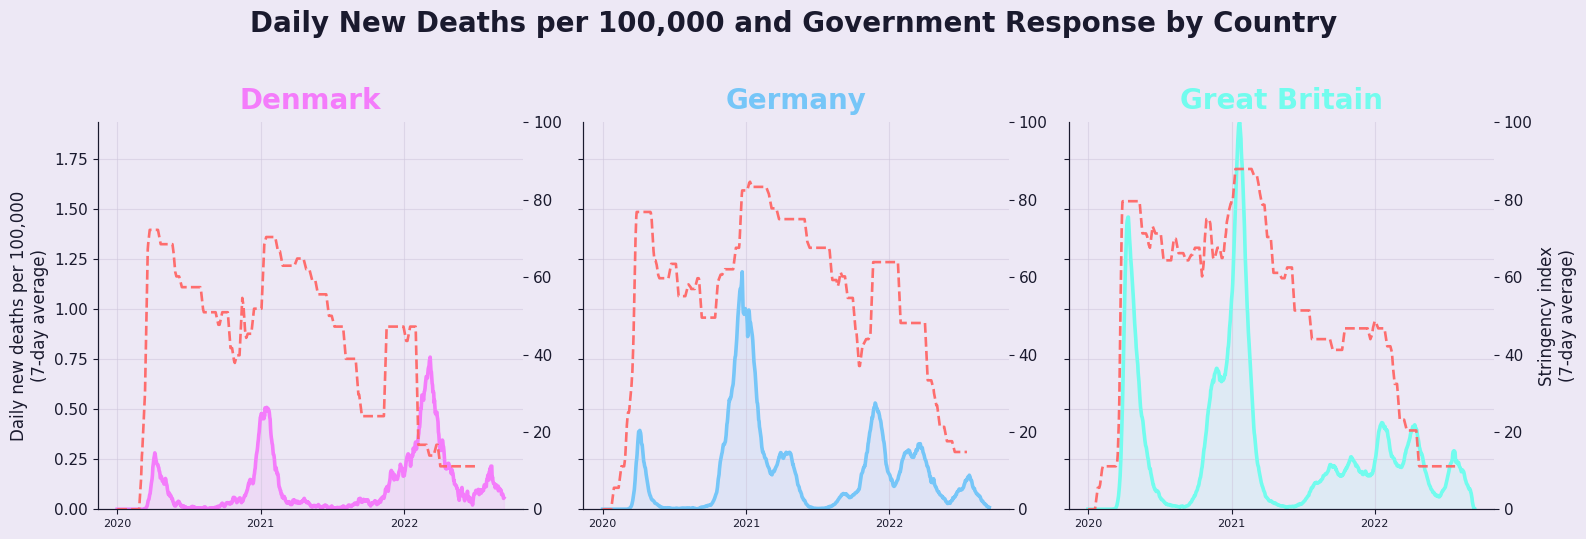

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Prepare plotted data by combining epidemiology and stringency
deaths_stringency_pop_df = (
    epi_compare[["date", "location_key", "country", "new_deceased_per_100k_7d"]]
    .merge(
        gov_compare[["date", "location_key", "stringency_7d"]],
        on=["date", "location_key"],
        how="left"
    )
)

# Save plotted data as CSV
save_plot_data(
    deaths_stringency_pop_df,
    "population_adjusted_deaths_and_government_response_by_country.csv"
)

# Shared axis limits for fair comparison
deaths_per_100k_ymax = deaths_stringency_pop_df["new_deceased_per_100k_7d"].max()
stringency_ymax = 100  # bounded index

# Create figure
fig, axes = plt.subplots(1, 3, figsize=(16, 5.2), sharex=True, sharey=True)
right_axes = []

for ax, code in zip(axes, selected_countries):
    df_plot = (
        deaths_stringency_pop_df[deaths_stringency_pop_df["location_key"] == code]
        .sort_values("date")
        .copy()
    )

    c = COUNTRY_COLORS[code]

    # Left axis: deaths per 100k
    ax.plot(
        df_plot["date"],
        df_plot["new_deceased_per_100k_7d"],
        color=c,
        linewidth=2.6
    )

    ax.fill_between(
        df_plot["date"],
        df_plot["new_deceased_per_100k_7d"],
        color=c,
        alpha=0.12
    )

    ax.set_title(country_names[code], color=c, pad=10)
    ax.set_ylim(0, deaths_per_100k_ymax)

    # Cleaner date ticks
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(axis="x", labelsize=8)

    style_ax(ax)

    # Right axis: stringency
    ax2 = ax.twinx()
    ax2.plot(
        df_plot["date"],
        df_plot["stringency_7d"],
        color=POLICY,
        linestyle="--",
        linewidth=1.9,
        alpha=0.95
    )
    ax2.set_ylim(0, stringency_ymax)
    ax2.tick_params(axis="y", colors=TEXT)
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_color(TEXT)
    ax2.set_facecolor(BG)
    ax2.grid(False)

    right_axes.append(ax2)

# Shared labels
axes[0].set_ylabel("Daily new deaths per 100,000\n(7-day average)")
for ax in axes[1:]:
    ax.set_ylabel("")

# Only show right-axis label on final panel
for ax2 in right_axes[:-1]:
    ax2.set_ylabel("")

right_axes[-1].set_ylabel("Stringency index\n(7-day average)", color=TEXT)

fig.suptitle(
    "Daily New Deaths per 100,000 and Government Response by Country",
    fontsize=20,
    fontweight="bold",
    y=1.03,
    color=TEXT
)

plt.tight_layout()


plt.show()

## Bar chart comparison: cumulative confirmed cases and deaths per 100,000 inhabitants

Absolute totals are useful for showing the overall burden of the pandemic, but they are not ideal for comparing countries with different population sizes.

To make Denmark, Germany, and Great Britain more comparable, we calculate:

- **cumulative confirmed cases per 100,000 inhabitants**
- **cumulative deaths per 100,000 inhabitants**

These measures provide a fairer comparison of the relative COVID-19 burden across the three countries by adjusting for population size.

In [ ]:
# Selected countries
selected_countries = ["DK", "DE", "GB"]

country_names = {
    "DK": "Denmark",
    "DE": "Germany",
    "GB": "Great Britain"
}

# Population values used for normalization
# Keep these consistent with the official-source figures used earlier
population = {
    "DK": 6029607,
    "DE": 83200000,
    "GB": 66796807
}

## Compute per-capita values

To compare Denmark, Germany, and Great Britain more fairly, we use the **latest cumulative country-level totals** from the epidemiology dataset and convert them to:

- **cumulative confirmed cases per 100,000 inhabitants**
- **cumulative deaths per 100,000 inhabitants**

This gives a population-adjusted summary of the overall COVID-19 burden in each country.

In [ ]:
latest_compare = (
    epi_country[epi_country["location_key"].isin(selected_countries)]
    .sort_values(["location_key", "date"])
    .groupby("location_key", as_index=False)[
        ["date", "cumulative_confirmed", "cumulative_deceased"]
    ]
    .last()
    .copy()
)

latest_compare["country"] = latest_compare["location_key"].map(country_names)
latest_compare["population"] = latest_compare["location_key"].map(population)

latest_compare["cases_per_100k"] = (
    latest_compare["cumulative_confirmed"] / latest_compare["population"] * 100000
)

latest_compare["deaths_per_100k"] = (
    latest_compare["cumulative_deceased"] / latest_compare["population"] * 100000
)

# Keep a clean output table
latest_compare = latest_compare[
    [
        "location_key",
        "country",
        "date",
        "population",
        "cumulative_confirmed",
        "cumulative_deceased",
        "cases_per_100k",
        "deaths_per_100k",
    ]
].copy()


# Display in notebook
display(
    latest_compare.style.format({
        "population": "{:,.0f}",
        "cumulative_confirmed": "{:,.0f}",
        "cumulative_deceased": "{:,.0f}",
        "cases_per_100k": "{:,.2f}",
        "deaths_per_100k": "{:,.2f}",
    })
)

Saved CSV to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/latest_cumulative_cases_and_deaths_per_100k_selected_countries.csv


,location_key,country,date,population,cumulative_confirmed,cumulative_deceased,cases_per_100k,deaths_per_100k
0,DE,Germany,2022-09-13 00:00:00,"83,200,000","32,604,993","148,728","39,188.69",178.76
1,DK,Denmark,2022-09-13 00:00:00,"6,029,607","3,283,706","6,987","54,459.70",115.88
2,GB,Great Britain,2022-09-13 00:00:00,"66,796,807","23,554,971","189,026","35,263.62",282.99


## Country totals and population normalization

To compare countries more fairly, we normalize cumulative confirmed cases and cumulative deaths by population size.

We first take the **latest cumulative country-level totals** from the epidemiology dataset, then divide by population and scale the results to **per 100,000 inhabitants**.

Because the epidemiology dataset does not include population, we add population values manually from official national statistical sources.

In [ ]:
import pandas as pd
import numpy as np

selected_countries = ["DK", "DE", "GB"]

country_names = {
    "DK": "Denmark",
    "DE": "Germany",
    "GB": "Great Britain"
}

country_colors = {
    "DK": DENMARK,
    "DE": GERMANY,
    "GB": UK,
}

# Population values from the official sources used earlier
population_lookup = {
    "DK": 6029607,
    "DE": 83200000,
    "GB": 66796807,
}

latest_country_totals = (
    epi_country[epi_country["location_key"].isin(selected_countries)]
    .sort_values(["location_key", "date"])
    .groupby("location_key", as_index=False)[
        ["date", "cumulative_confirmed", "cumulative_deceased"]
    ]
    .last()
    .copy()
)

latest_country_totals["country"] = latest_country_totals["location_key"].map(country_names)
latest_country_totals["population"] = latest_country_totals["location_key"].map(population_lookup)

latest_country_totals["cases_per_100k"] = (
    latest_country_totals["cumulative_confirmed"] / latest_country_totals["population"] * 100000
)

latest_country_totals["deaths_per_100k"] = (
    latest_country_totals["cumulative_deceased"] / latest_country_totals["population"] * 100000
)

latest_country_totals = latest_country_totals[
    [
        "location_key",
        "country",
        "date",
        "population",
        "cumulative_confirmed",
        "cumulative_deceased",
        "cases_per_100k",
        "deaths_per_100k",
    ]
].copy()

display(
    latest_country_totals.style.format({
        "population": "{:,.0f}",
        "cumulative_confirmed": "{:,.0f}",
        "cumulative_deceased": "{:,.0f}",
        "cases_per_100k": "{:,.2f}",
        "deaths_per_100k": "{:,.2f}",
    })
)

,location_key,country,date,population,cumulative_confirmed,cumulative_deceased,cases_per_100k,deaths_per_100k
0,DE,Germany,2022-09-13 00:00:00,"83,200,000","32,604,993","148,728","39,188.69",178.76
1,DK,Denmark,2022-09-13 00:00:00,"6,029,607","3,283,706","6,987","54,459.70",115.88
2,GB,Great Britain,2022-09-13 00:00:00,"66,796,807","23,554,971","189,026","35,263.62",282.99


## Static bar chart: cumulative cases and deaths per 100,000

This figure compares Denmark, Germany, and Great Britain using **population-normalized cumulative values**.

Normalization is important because raw totals are strongly influenced by country size. By using values **per 100,000 inhabitants**, the comparison becomes more meaningful and better reflects the relative COVID-19 burden in each country.

The chart shows:

- **cumulative confirmed cases per 100,000 inhabitants**
- **cumulative deaths per 100,000 inhabitants**

Saved CSV to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/bar_chart_cumulative_cases_and_deaths_per_100k.csv
Saved figure to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/bar_chart_cumulative_cases_and_deaths_per_100k.png


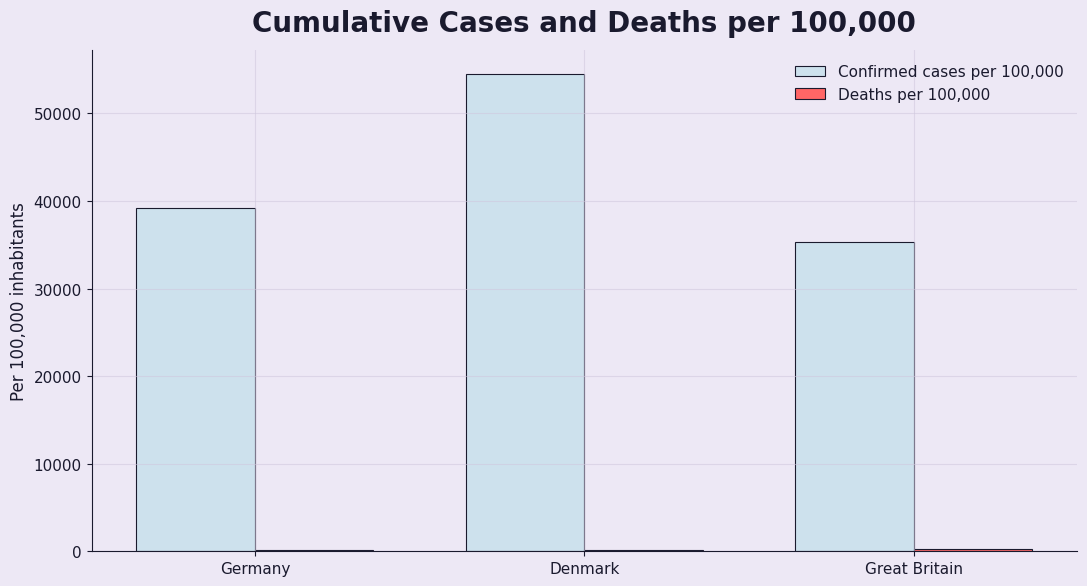

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Use the already prepared table
plot_df = latest_country_totals.copy().sort_values("location_key")

# Save only the plotted data, since this is a final-presentable figure
save_plot_data(
    plot_df[["location_key", "country", "cases_per_100k", "deaths_per_100k"]],
    "bar_chart_cumulative_cases_and_deaths_per_100k.csv"
)

x = np.arange(len(plot_df))
width = 0.36

fig, ax = plt.subplots(figsize=(11, 6))

bars1 = ax.bar(
    x - width/2,
    plot_df["cases_per_100k"],
    width,
    label="Confirmed cases per 100,000",
    color=ACCENT_3,
    edgecolor=TEXT,
    linewidth=0.8
)

bars2 = ax.bar(
    x + width/2,
    plot_df["deaths_per_100k"],
    width,
    label="Deaths per 100,000",
    color=POLICY,
    edgecolor=TEXT,
    linewidth=0.8
)

ax.set_xticks(x)
ax.set_xticklabels(plot_df["country"])

style_ax(
    ax,
    title="Cumulative Cases and Deaths per 100,000",
    ylabel="Per 100,000 inhabitants"
)

ax.legend(frameon=False)

plt.tight_layout()


plt.show()

## Interactive bar chart: cumulative cases and deaths per 100,000

This interactive Plotly version supports:

- hover details,
- cleaner visual presentation,
- and easier later integration into a website.

It compares the same two population-normalized cumulative metrics:

- **confirmed cases per 100,000 inhabitants**
- **deaths per 100,000 inhabitants**

Using per-capita values makes the comparison more meaningful across countries of different population sizes.

In [ ]:
import plotly.graph_objects as go

plot_df = latest_country_totals.copy().sort_values("location_key")

# Save plotted data since this is a presentable website figure
save_plot_data(
    plot_df[["location_key", "country", "cases_per_100k", "deaths_per_100k"]],
    "interactive_bar_chart_cumulative_cases_and_deaths_per_100k.csv"
)

fig = go.Figure()

fig.add_trace(go.Bar(
    x=plot_df["country"],
    y=plot_df["cases_per_100k"],
    name="Confirmed cases per 100,000",
    marker=dict(
        color=ACCENT_3,
        line=dict(color=TEXT, width=1)
    ),
    hovertemplate="<b>%{x}</b><br>Confirmed cases per 100,000: %{y:,.1f}<extra></extra>"
))

fig.add_trace(go.Bar(
    x=plot_df["country"],
    y=plot_df["deaths_per_100k"],
    name="Deaths per 100,000",
    marker=dict(
        color=POLICY,
        line=dict(color=TEXT, width=1)
    ),
    hovertemplate="<b>%{x}</b><br>Deaths per 100,000: %{y:,.1f}<extra></extra>"
))

fig.update_layout(
    barmode="group",
    paper_bgcolor=BG,
    plot_bgcolor=BG,
    font=dict(
        family="Aptos, DejaVu Sans, Arial, sans-serif",
        color=TEXT,
        size=13
    ),
    title=dict(
        text="Cumulative Cases and Deaths per 100,000",
        x=0.03,
        xanchor="left",
        font=dict(size=24, color=TEXT)
    ),
    xaxis_title="",
    yaxis_title="Per 100,000 inhabitants",
    legend_title="Metric"
)

fig.update_xaxes(
    showgrid=False,
    linecolor=TEXT,
    tickcolor=TEXT
)

fig.update_yaxes(
    showgrid=True,
    gridcolor=GRID,
    linecolor=TEXT,
    tickcolor=TEXT
)


fig.show()

Saved CSV to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/interactive_bar_chart_cumulative_cases_and_deaths_per_100k.csv
Saved interactive figure to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/interactive_bar_chart_cumulative_cases_and_deaths_per_100k.html


## Split view: separate bar charts for cumulative cases and deaths per 100,000

If grouped bars feel visually crowded, it can be more effective to separate the two metrics into different charts.

This split view improves readability and avoids scale confusion by showing:

- **cumulative confirmed cases per 100,000 inhabitants**
- **cumulative deaths per 100,000 inhabitants**

in separate panels.

Because both measures are population-normalized, the comparison remains fair across Denmark, Germany, and Great Britain.

Saved CSV to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/split_bar_charts_cumulative_cases_and_deaths_per_100k.csv
Saved figure to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/split_bar_charts_cumulative_cases_and_deaths_per_100k.png


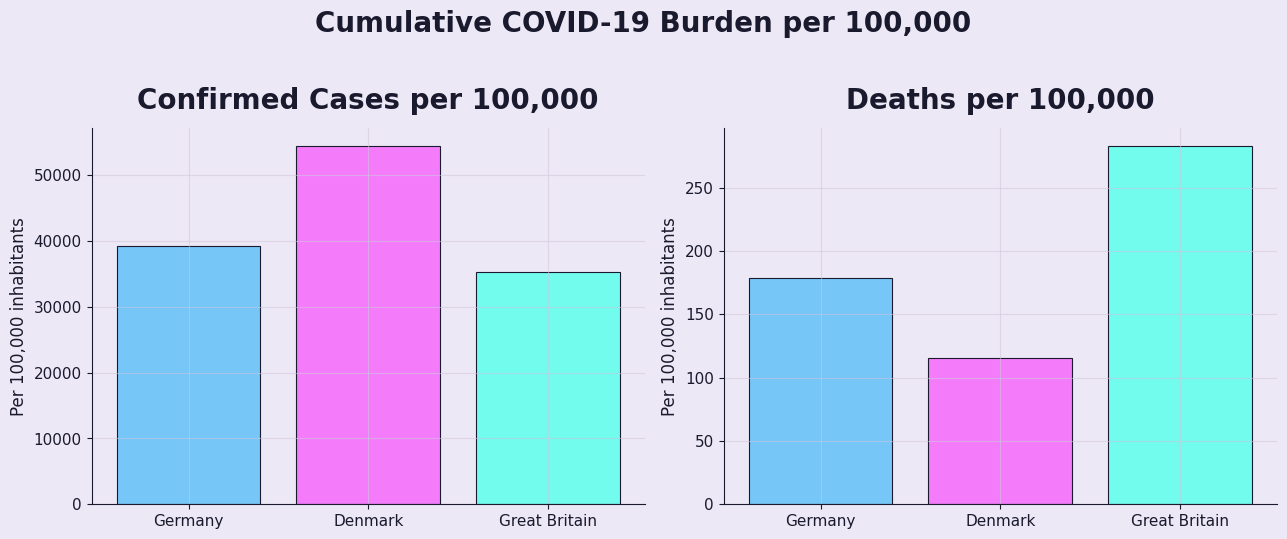

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2), sharey=False)

plot_df = latest_country_totals.copy().sort_values("location_key")

# Save plotted data since this is a presentable website figure
save_plot_data(
    plot_df[["location_key", "country", "cases_per_100k", "deaths_per_100k"]],
    "split_bar_charts_cumulative_cases_and_deaths_per_100k.csv"
)

# Cases panel
axes[0].bar(
    plot_df["country"],
    plot_df["cases_per_100k"],
    color=[COUNTRY_COLORS[c] for c in plot_df["location_key"]],
    edgecolor=TEXT,
    linewidth=0.8
)

style_ax(
    axes[0],
    title="Confirmed Cases per 100,000",
    ylabel="Per 100,000 inhabitants"
)

# Deaths panel
axes[1].bar(
    plot_df["country"],
    plot_df["deaths_per_100k"],
    color=[COUNTRY_COLORS[c] for c in plot_df["location_key"]],
    edgecolor=TEXT,
    linewidth=0.8
)

style_ax(
    axes[1],
    title="Deaths per 100,000",
    ylabel="Per 100,000 inhabitants"
)

fig.suptitle(
    "Cumulative COVID-19 Burden per 100,000",
    fontsize=20,
    fontweight="bold",
    y=1.03,
    color=TEXT
)

plt.tight_layout()


plt.show()

**Interpretation note:**  
These values are normalized per 100,000 inhabitants in order to make the country comparison fairer. Raw cumulative totals would otherwise be dominated by country size.

## Heatmap: monthly daily new cases per 100,000 by country

This heatmap shows the **average monthly level of daily new confirmed cases per 100,000 inhabitants** for one year at a time.

A year-by-year view makes it easier to compare the changing shape of the pandemic across Denmark, Germany, and Great Britain. The monthly structure helps highlight broader patterns that may be less visible in the daily time series.

In [ ]:
year_to_plot = 2021

heat_cases = epi_monthly_agg[epi_monthly_agg["year"] == year_to_plot].copy()
heat_cases["month_name"] = pd.Categorical(
    heat_cases["month_name"],
    categories=month_order,
    ordered=True
)
heat_cases = heat_cases.sort_values(["country", "month"])

# Save only because this is a presentable figure
save_plot_data(
    heat_cases,
    f"heatmap_monthly_cases_per_100k_{year_to_plot}.csv"
)

fig = px.density_heatmap(
    heat_cases,
    x="month_name",
    y="country",
    z="avg_cases_per_100k",
    histfunc="avg",
    color_continuous_scale=[
        [0.00, "#EFDEF0"],
        [0.20, "#DEDAF2"],
        [0.40, "#D9B8E1"],
        [0.60, "#B78AC5"],
        [0.80, "#8E5A9E"],
        [1.00, "#5F3D73"],
    ],
    title=f"Monthly Daily New Cases per 100,000 by Country — {year_to_plot}"
)

fig.update_layout(
    paper_bgcolor=BG,
    plot_bgcolor=BG,
    font=dict(
        family="Aptos, DejaVu Sans, Arial, sans-serif",
        color=TEXT,
        size=14
    ),
    title=dict(
        text=f"Monthly Daily New Cases per 100,000 by Country — {year_to_plot}",
        font=dict(size=24, color=TEXT),
        x=0.03,
        xanchor="left"
    ),
    xaxis_title="Month",
    yaxis_title="Country",
    coloraxis_colorbar=dict(
        title=dict(
            text="Avg daily cases per 100,000",
            font=dict(color=TEXT)
        ),
        tickfont=dict(color=TEXT)
    )
)

fig.update_xaxes(showgrid=False, linecolor=TEXT, tickcolor=TEXT)
fig.update_yaxes(showgrid=False, linecolor=TEXT, tickcolor=TEXT)


fig.show()

Saved CSV to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/heatmap_monthly_cases_per_100k_2021.csv
Saved interactive figure to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/heatmap_monthly_cases_per_100k_2021.html


## Heatmap: monthly daily new deaths per 100,000 by country

This heatmap shows the **average monthly level of daily new COVID-19 deaths per 100,000 inhabitants** for the selected year.

A year-by-year view makes it easier to compare when mortality was relatively low, moderate, or high across Denmark, Germany, and Great Britain. The monthly structure helps reveal broader death-wave patterns that are less obvious in the daily time series.

In [ ]:
year_to_plot = 2021

heat_deaths = epi_monthly_agg[epi_monthly_agg["year"] == year_to_plot].copy()
heat_deaths["month_name"] = pd.Categorical(
    heat_deaths["month_name"],
    categories=month_order,
    ordered=True
)
heat_deaths = heat_deaths.sort_values(["country", "month"])

# Save only because this is a presentable figure
save_plot_data(
    heat_deaths,
    f"heatmap_monthly_deaths_per_100k_{year_to_plot}.csv"
)

fig = px.density_heatmap(
    heat_deaths,
    x="month_name",
    y="country",
    z="avg_deaths_per_100k",
    histfunc="avg",
    color_continuous_scale=[
        [0.00, "#EFDEF0"],
        [0.20, "#E7B7C0"],
        [0.40, "#D88A9B"],
        [0.60, "#C85F72"],
        [0.80, "#B33C50"],
        [1.00, "#7A1E2C"],
    ],
    title=f"Monthly Daily New Deaths per 100,000 by Country — {year_to_plot}"
)

fig.update_layout(
    paper_bgcolor=BG,
    plot_bgcolor=BG,
    font=dict(
        family="Aptos, DejaVu Sans, Arial, sans-serif",
        color=TEXT,
        size=14
    ),
    title=dict(
        text=f"Monthly Daily New Deaths per 100,000 by Country — {year_to_plot}",
        font=dict(size=24, color=TEXT),
        x=0.03,
        xanchor="left"
    ),
    xaxis_title="Month",
    yaxis_title="Country",
    coloraxis_colorbar=dict(
        title=dict(
            text="Avg daily deaths per 100,000",
            font=dict(color=TEXT)
        ),
        tickfont=dict(color=TEXT)
    )
)

fig.update_xaxes(showgrid=False, linecolor=TEXT, tickcolor=TEXT)
fig.update_yaxes(showgrid=False, linecolor=TEXT, tickcolor=TEXT)



fig.show()

Saved CSV to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/heatmap_monthly_deaths_per_100k_2021.csv
Saved interactive figure to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/heatmap_monthly_deaths_per_100k_2021.html


## Heatmap: monthly government stringency by country

This heatmap shows the **average monthly government stringency index** for the selected year.

A year-by-year view makes it easier to compare when restrictions intensified, how strict policy responses became, and how long stricter periods lasted across Denmark, Germany, and Great Britain. Because the Oxford stringency index is already standardized, it can be compared directly across countries.

In [ ]:
year_to_plot = 2021

heat_stringency = gov_monthly_agg[gov_monthly_agg["year"] == year_to_plot].copy()
heat_stringency["month_name"] = pd.Categorical(
    heat_stringency["month_name"],
    categories=month_order,
    ordered=True
)
heat_stringency = heat_stringency.sort_values(["country", "month"])

# Save only because this is a presentable figure
save_plot_data(
    heat_stringency,
    f"heatmap_monthly_government_stringency_{year_to_plot}.csv"
)

fig = px.density_heatmap(
    heat_stringency,
    x="month_name",
    y="country",
    z="avg_stringency",
    histfunc="avg",
    color_continuous_scale=[
        [0.00, "#E1ECF3"],
        [0.25, "#CDE1ED"],
        [0.50, "#DEDAF2"],
        [0.75, "#D8ECEA"],
        [1.00, "#FF6666"],
    ],
    title=f"Monthly Government Stringency by Country — {year_to_plot}"
)

fig.update_layout(
    paper_bgcolor=BG,
    plot_bgcolor=BG,
    font=dict(
        family="Aptos, DejaVu Sans, Arial, sans-serif",
        color=TEXT,
        size=14
    ),
    title=dict(
        text=f"Monthly Government Stringency by Country — {year_to_plot}",
        font=dict(size=24, color=TEXT),
        x=0.03,
        xanchor="left"
    ),
    xaxis_title="Month",
    yaxis_title="Country",
    coloraxis_colorbar=dict(
        title=dict(
            text="Avg stringency",
            font=dict(color=TEXT)
        ),
        tickfont=dict(color=TEXT)
    )
)

fig.update_xaxes(showgrid=False, linecolor=TEXT, tickcolor=TEXT)
fig.update_yaxes(showgrid=False, linecolor=TEXT, tickcolor=TEXT)



fig.show()

Saved CSV to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/heatmap_monthly_government_stringency_2021.csv
Saved interactive figure to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/heatmap_monthly_government_stringency_2021.html


## Interactive heatmap with year dropdown

This interactive heatmap allows the user to switch between years and compare the **average monthly level of daily new confirmed cases per 100,000 inhabitants** across Denmark, Germany, and Great Britain.

The dropdown makes it easy to focus on one calendar year at a time, which helps reveal when case intensity was relatively low, moderate, or high within the same monthly structure.

In [ ]:
import plotly.graph_objects as go

fig = go.Figure()

heat_years = sorted(epi_monthly_agg["year"].dropna().unique())
trace_info = []

# Save only because this is a presentable figure
save_plot_data(
    epi_monthly_agg,
    "interactive_heatmap_monthly_cases_per_100k_all_years.csv"
)

for year in heat_years:
    heat_cases = epi_monthly_agg[epi_monthly_agg["year"] == year].copy()
    heat_cases["month_name"] = pd.Categorical(
        heat_cases["month_name"],
        categories=month_order,
        ordered=True
    )
    heat_cases = heat_cases.sort_values(["country", "month"])

    pivot_df = (
        heat_cases
        .pivot(index="country", columns="month_name", values="avg_cases_per_100k")
        .reindex(columns=month_order)
    )

    fig.add_trace(
        go.Heatmap(
            z=pivot_df.values,
            x=pivot_df.columns,
            y=pivot_df.index,
            colorscale=[
                [0.00, "#EFDEF0"],
                [0.20, "#DEDAF2"],
                [0.40, "#D9B8E1"],
                [0.60, "#B78AC5"],
                [0.80, "#8E5A9E"],
                [1.00, "#5F3D73"],
            ],
            visible=(year == heat_years[0]),
            colorbar=dict(
                title=dict(
                    text="Avg daily cases per 100,000",
                    font=dict(color=TEXT)
                ),
                tickfont=dict(color=TEXT)
            ),
            hovertemplate=(
                "Country: %{y}<br>"
                "Month: %{x}<br>"
                "Avg daily cases per 100,000: %{z:.2f}<extra></extra>"
            )
        )
    )
    trace_info.append(year)

buttons = []
for year in heat_years:
    buttons.append(
        dict(
            label=str(year),
            method="update",
            args=[
                {"visible": [y == year for y in trace_info]},
                {"title": f"Monthly Daily New Cases per 100,000 by Country — {year}"}
            ]
        )
    )

fig.update_layout(
    paper_bgcolor=BG,
    plot_bgcolor=BG,
    font=dict(
        family="Aptos, DejaVu Sans, Arial, sans-serif",
        color=TEXT,
        size=14
    ),
    title=dict(
        text=f"Monthly Daily New Cases per 100,000 by Country — {heat_years[0]}",
        font=dict(size=24, color=TEXT),
        x=0.03,
        xanchor="left"
    ),
    xaxis_title="Month",
    yaxis_title="Country",
    updatemenus=[
        dict(
            type="dropdown",
            direction="down",
            x=1.02,
            y=1.0,
            showactive=True,
            bgcolor=ACCENT_2,
            buttons=buttons
        )
    ]
)

fig.update_xaxes(showgrid=False, linecolor=TEXT, tickcolor=TEXT)
fig.update_yaxes(showgrid=False, linecolor=TEXT, tickcolor=TEXT)


fig.show()

Saved CSV to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/interactive_heatmap_monthly_cases_per_100k_all_years.csv
Saved interactive figure to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/interactive_heatmap_monthly_cases_per_100k_all_years.html


## How to interpret Oxford policy scales

Several variables in the Oxford Government Response dataset, such as **school closing** and **workplace closing**, are recorded on small numeric scales like **0 to 3**.

These scales are **ordinal policy indicators**. This means they represent **ordered levels of policy strictness**, not continuous measured quantities.

In general, they should be interpreted as:

- a **higher value** means a **stricter policy**
- a **lower value** means a **less strict policy**

For example, a workplace-closing variable may follow this pattern:

- **0** = no measures
- **1** = recommendation
- **2** = partial requirement
- **3** = broad or full requirement

The same general logic applies to school-closing and similar Oxford response variables.

### Important interpretation note
These variables are **not** like cases, deaths, temperature, or income, where the numbers represent continuous measured amounts.  
Instead, they are **coded categories** placed in order from less strict to more strict.

This means:

- **3** is stricter than **2**
- **2** is stricter than **1**
- but the step from **1 to 2** should not automatically be treated as the same quantitative jump as the step from **2 to 3**

### What these scales are useful for
These policy indicators are helpful for showing:

- when governments introduced restrictions,
- when restrictions became stricter or more relaxed,
- and how policy timing relates to changes in cases or deaths.

### What they should not be used for
These scales should **not** be interpreted as exact measurements of how many people, schools, or workplaces were affected.  
They describe the **level of policy response**, not its exact real-world magnitude.

## Cases per 100,000 and school closings by country

This figure compares **Denmark, Germany, and Great Britain** using two aligned views for each country.

### Top row: new confirmed cases
The upper panels show **new confirmed COVID-19 cases per 100,000 people**, smoothed with a **7-day rolling average**.  
Using cases per 100,000 makes the countries more comparable by adjusting for population size.

### Bottom row: school closing policy
The lower panels show the **school closing policy level** from the Oxford Government Response dataset.  
This variable is an **ordinal policy measure**, not a population-normalized quantity, so it is shown on its own scale from **0 to 3**.

The values represent:

- **0** = no measures
- **1** = recommend closing or altered attendance
- **2** = require closing some levels or categories
- **3** = require closing all levels

### Why this layout is fair
We do **not** place cases and school closing on the same axis, because they measure fundamentally different things.  
Instead, we align them vertically and keep the scales consistent across countries:

- the **same case scale** is used for all countries in the top row
- the **same school-closing scale** is used for all countries in the bottom row

This allows us to compare:
- when case waves occurred,
- when school-closing policies became stricter or more relaxed,
- and whether changes in policy happened before, during, or after major waves.

Saved CSV to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/cases_per_100k_and_school_closing_by_country.csv


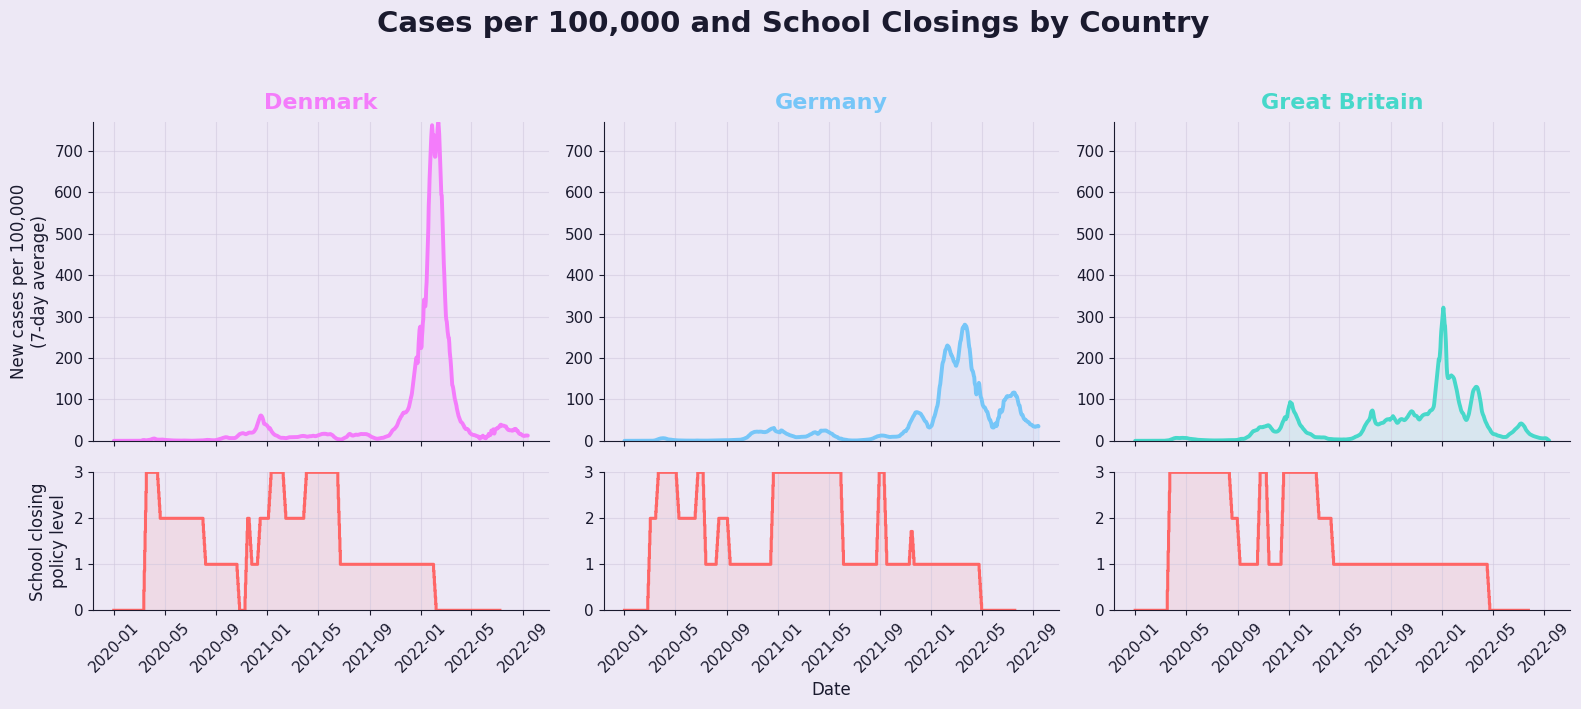

In [ ]:
# Prepare government comparison table for school closing
gov_school_compare = (
    gov_country[gov_country["location_key"].isin(selected_countries)]
    .copy()
    .sort_values(["location_key", "date"])
)

gov_school_compare["country"] = gov_school_compare["location_key"].map(country_names)

# Smooth school closing slightly for visual readability
gov_school_compare["school_closing_7d"] = (
    gov_school_compare.groupby("location_key")["school_closing"]
    .transform(lambda s: s.rolling(7, min_periods=1).mean())
)

# Prepare plotted data for saving
cases_school_df = (
    epi_compare[["date", "location_key", "country", "new_confirmed_per_100k_7d"]]
    .merge(
        gov_school_compare[["date", "location_key", "school_closing_7d"]],
        on=["date", "location_key"],
        how="left"
    )
)

save_plot_data(
    cases_school_df,
    "cases_per_100k_and_school_closing_by_country.csv"
)

# Shared scales for fair comparison
cases_ymax = epi_compare["new_confirmed_per_100k_7d"].max()
school_ymin = 0
school_ymax = 3

# Updated country colors
COUNTRY_COLORS = {
    "DK": "#F47CFB",
    "DE": "#76C6F8",
    "GB": "#47D8CA",
}

# Plot: 2 rows x 3 columns
fig, axes = plt.subplots(
    2, 3,
    figsize=(16, 7.2),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1.3]}
)

for col, code in enumerate(selected_countries):
    df_plot = cases_school_df[cases_school_df["location_key"] == code].sort_values("date")
    c = COUNTRY_COLORS[code]

    ax_top = axes[0, col]
    ax_bottom = axes[1, col]

    # ---------- Top: cases per 100k ----------
    ax_top.plot(
        df_plot["date"],
        df_plot["new_confirmed_per_100k_7d"],
        color=c,
        linewidth=2.8,
        solid_capstyle="round"
    )

    ax_top.fill_between(
        df_plot["date"],
        df_plot["new_confirmed_per_100k_7d"],
        color=c,
        alpha=0.12
    )

    ax_top.set_title(
        country_names[code],
        color=c,
        pad=10,
        fontsize=16,
        fontweight="bold"
    )
    ax_top.set_ylim(0, cases_ymax)

    style_ax(ax_top)

    # ---------- Bottom: school closing ----------
    ax_bottom.step(
        df_plot["date"],
        df_plot["school_closing_7d"],
        where="mid",
        color=POLICY,
        linewidth=2.2
    )

    ax_bottom.fill_between(
        df_plot["date"],
        df_plot["school_closing_7d"],
        step="mid",
        color=POLICY,
        alpha=0.10
    )

    ax_bottom.set_ylim(school_ymin, school_ymax)
    ax_bottom.set_yticks([0, 1, 2, 3])
    ax_bottom.tick_params(axis="x", labelrotation=45)

    style_ax(ax_bottom)

# Shared y-labels
axes[0, 0].set_ylabel("New cases per 100,000\n(7-day average)")
axes[1, 0].set_ylabel("School closing\npolicy level")

for col in [1, 2]:
    axes[0, col].set_ylabel("")
    axes[1, col].set_ylabel("")

# Only add x-axis label in center bottom
axes[1, 1].set_xlabel("Date")
axes[1, 0].set_xlabel("")
axes[1, 2].set_xlabel("")

fig.suptitle(
    "Cases per 100,000 and School Closings by Country",
    fontsize=21,
    fontweight="bold",
    y=0.98,
    color=TEXT
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Daily new confirmed cases per 100,000 and workplace closing policy by country

This figure compares **Denmark, Germany, and Great Britain** using two aligned views for each country.

### Top row: daily new confirmed cases
The upper panels show the **7-day average of daily new confirmed COVID-19 cases per 100,000 inhabitants**.  
Using cases per 100,000 makes the countries more comparable by adjusting for population size.

### Bottom row: workplace closing policy
The lower panels show the **workplace closing policy level** from the Oxford Government Response dataset.  
This variable is an **ordinal policy measure**, not a population-normalized quantity, so it is shown on its own scale from **0 to 3**.

The values represent:

- **0** = no measures
- **1** = recommend closing or working from home
- **2** = require closing for some sectors or categories of workers
- **3** = require closing for all-but-essential workplaces

### Why this layout is appropriate
We do **not** place cases and workplace closing on the same axis, because they measure fundamentally different things.  
Instead, we align them vertically and keep the scales consistent across countries:

- the **same case scale** is used for all countries in the top row
- the **same workplace-closing scale** is used for all countries in the bottom row

This allows us to compare:

- when case waves occurred,
- when workplace-closing policies became stricter or more relaxed,
- and whether policy changes happened before, during, or after major waves.

Saved CSV to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/cases_per_100k_and_workplace_closing_by_country.csv
Saved figure to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/cases_per_100k_and_workplace_closing_by_country.png


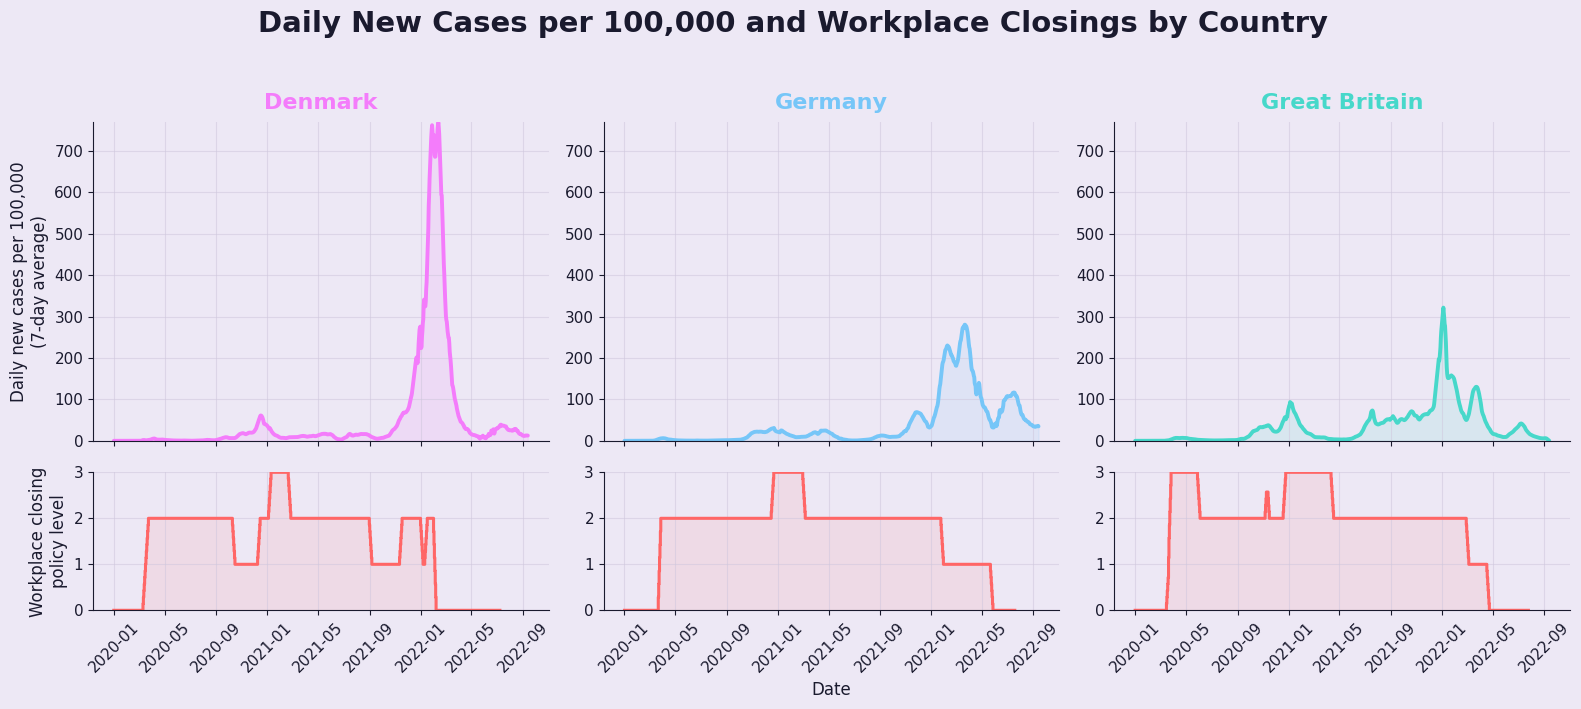

In [ ]:
# Prepare government comparison table for workplace closing
gov_workplace_compare = (
    gov_country[gov_country["location_key"].isin(selected_countries)]
    .copy()
    .sort_values(["location_key", "date"])
)

gov_workplace_compare["country"] = gov_workplace_compare["location_key"].map(country_names)

# Smooth workplace closing slightly for visual readability
gov_workplace_compare["workplace_closing_7d"] = (
    gov_workplace_compare.groupby("location_key")["workplace_closing"]
    .transform(lambda s: s.rolling(7, min_periods=1).mean())
)

# Prepare plotted data for saving
cases_workplace_df = (
    epi_compare[["date", "location_key", "country", "new_confirmed_per_100k_7d"]]
    .merge(
        gov_workplace_compare[["date", "location_key", "workplace_closing_7d"]],
        on=["date", "location_key"],
        how="left"
    )
)

save_plot_data(
    cases_workplace_df,
    "cases_per_100k_and_workplace_closing_by_country.csv"
)

# Shared scales for fair comparison
cases_ymax = epi_compare["new_confirmed_per_100k_7d"].max()
workplace_ymin = 0
workplace_ymax = 3

# Updated country colors
COUNTRY_COLORS = {
    "DK": "#F47CFB",
    "DE": "#76C6F8",
    "GB": "#47D8CA",
}

# Plot: 2 rows x 3 columns
fig, axes = plt.subplots(
    2, 3,
    figsize=(16, 7.2),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1.3]}
)

for col, code in enumerate(selected_countries):
    df_plot = cases_workplace_df[cases_workplace_df["location_key"] == code].sort_values("date")
    c = COUNTRY_COLORS[code]

    ax_top = axes[0, col]
    ax_bottom = axes[1, col]

    # ---------- Top: cases per 100k ----------
    ax_top.plot(
        df_plot["date"],
        df_plot["new_confirmed_per_100k_7d"],
        color=c,
        linewidth=2.8,
        solid_capstyle="round"
    )

    ax_top.fill_between(
        df_plot["date"],
        df_plot["new_confirmed_per_100k_7d"],
        color=c,
        alpha=0.12
    )

    ax_top.set_title(
        country_names[code],
        color=c,
        pad=10,
        fontsize=16,
        fontweight="bold"
    )
    ax_top.set_ylim(0, cases_ymax)

    style_ax(ax_top)

    # ---------- Bottom: workplace closing ----------
    ax_bottom.step(
        df_plot["date"],
        df_plot["workplace_closing_7d"],
        where="mid",
        color=POLICY,
        linewidth=2.2
    )

    ax_bottom.fill_between(
        df_plot["date"],
        df_plot["workplace_closing_7d"],
        step="mid",
        color=POLICY,
        alpha=0.10
    )

    ax_bottom.set_ylim(workplace_ymin, workplace_ymax)
    ax_bottom.set_yticks([0, 1, 2, 3])
    ax_bottom.tick_params(axis="x", labelrotation=45)

    style_ax(ax_bottom)

# Shared y-labels
axes[0, 0].set_ylabel("Daily new cases per 100,000\n(7-day average)")
axes[1, 0].set_ylabel("Workplace closing\npolicy level")

for col in [1, 2]:
    axes[0, col].set_ylabel("")
    axes[1, col].set_ylabel("")

# Only add x-axis label in center bottom
axes[1, 1].set_xlabel("Date")
axes[1, 0].set_xlabel("")
axes[1, 2].set_xlabel("")

fig.suptitle(
    "Daily New Cases per 100,000 and Workplace Closings by Country",
    fontsize=21,
    fontweight="bold",
    y=0.98,
    color=TEXT
)

plt.tight_layout(rect=[0, 0, 1, 0.95])



plt.show()

## Daily new confirmed cases per 100,000 and facial covering policy by country

This figure compares **Denmark, Germany, and Great Britain** using two aligned views for each country.

### Top row: daily new confirmed cases
The upper panels show the **7-day average of daily new confirmed COVID-19 cases per 100,000 inhabitants**.  
Using cases per 100,000 makes the countries more comparable by adjusting for population size.

### Bottom row: facial covering policy
The lower panels show the **facial covering policy level** from the Oxford Government Response dataset.  
This variable is an **ordinal policy measure**, not a population-normalized quantity, so it is shown on its own scale.

Higher values indicate stricter facial-covering requirements.

### Why this layout is appropriate
We do **not** place cases and facial covering restrictions on the same axis, because they measure fundamentally different things.  
Instead, we align them vertically and keep the scales consistent across countries:

- the **same case scale** is used for all countries in the top row
- the **same facial-covering scale** is used for all countries in the bottom row

This allows us to compare:

- when case waves occurred,
- when facial-covering policies became stricter or more relaxed,
- and whether policy changes happened before, during, or after major waves.

Saved CSV to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/cases_per_100k_and_facial_coverings_by_country.csv
Saved figure to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/cases_per_100k_and_facial_coverings_by_country.png


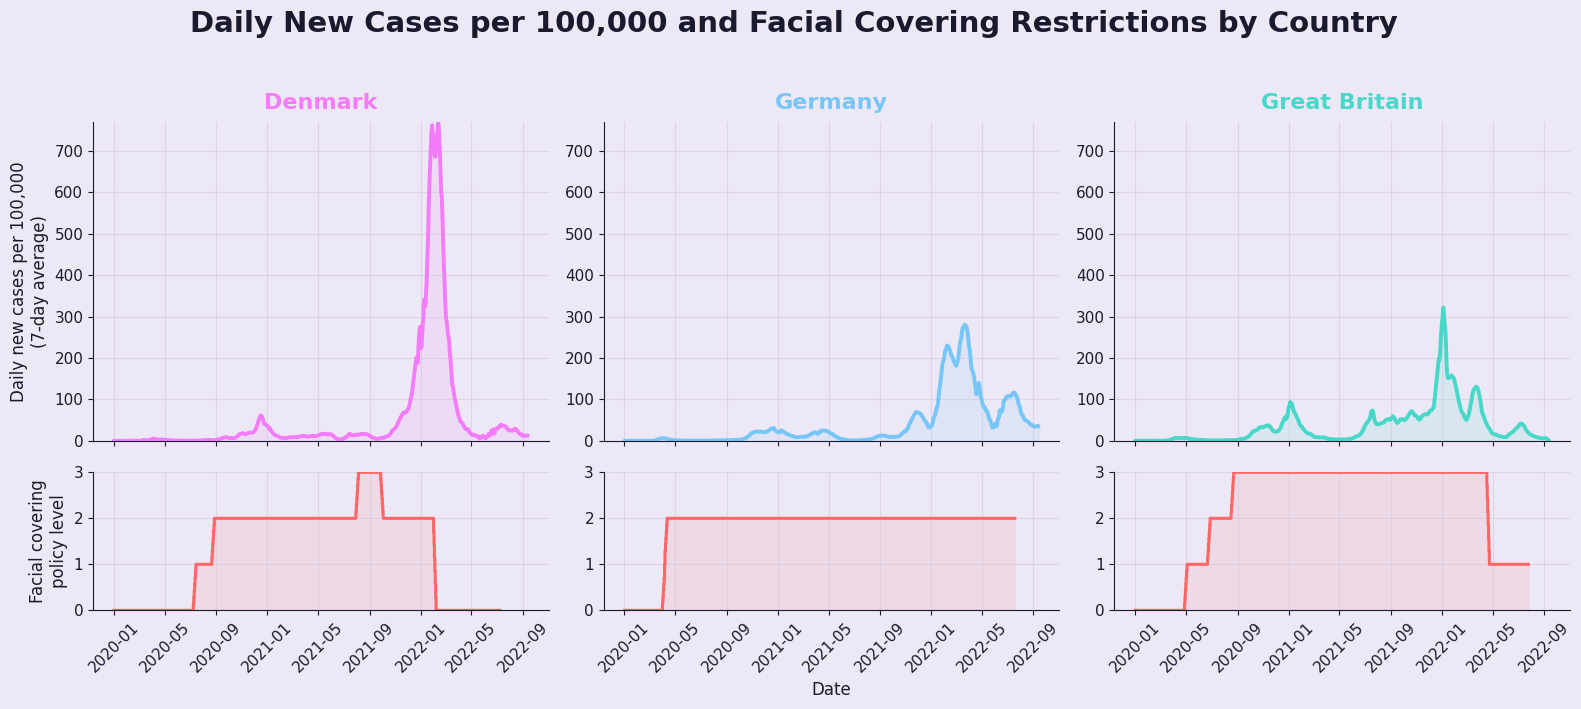

In [ ]:
# Prepare government comparison table for facial coverings
gov_facial_compare = (
    gov_country[gov_country["location_key"].isin(selected_countries)]
    .copy()
    .sort_values(["location_key", "date"])
)

gov_facial_compare["country"] = gov_facial_compare["location_key"].map(country_names)

# Smooth facial covering policy slightly for visual readability
gov_facial_compare["facial_coverings_7d"] = (
    gov_facial_compare.groupby("location_key")["facial_coverings"]
    .transform(lambda s: s.rolling(7, min_periods=1).mean())
)

# Prepare plotted data for saving
cases_facial_df = (
    epi_compare[["date", "location_key", "country", "new_confirmed_per_100k_7d"]]
    .merge(
        gov_facial_compare[["date", "location_key", "facial_coverings_7d"]],
        on=["date", "location_key"],
        how="left"
    )
)

save_plot_data(
    cases_facial_df,
    "cases_per_100k_and_facial_coverings_by_country.csv"
)

# Shared scales for fair comparison
cases_ymax = epi_compare["new_confirmed_per_100k_7d"].max()
facial_ymin = 0
facial_ymax = gov_facial_compare["facial_coverings_7d"].max()

# Updated country colors
COUNTRY_COLORS = {
    "DK": "#F47CFB",
    "DE": "#76C6F8",
    "GB": "#47D8CA",
}

# Plot: 2 rows x 3 columns
fig, axes = plt.subplots(
    2, 3,
    figsize=(16, 7.2),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1.3]}
)

for col, code in enumerate(selected_countries):
    df_plot = cases_facial_df[cases_facial_df["location_key"] == code].sort_values("date")
    c = COUNTRY_COLORS[code]

    ax_top = axes[0, col]
    ax_bottom = axes[1, col]

    # ---------- Top: cases per 100k ----------
    ax_top.plot(
        df_plot["date"],
        df_plot["new_confirmed_per_100k_7d"],
        color=c,
        linewidth=2.8,
        solid_capstyle="round"
    )

    ax_top.fill_between(
        df_plot["date"],
        df_plot["new_confirmed_per_100k_7d"],
        color=c,
        alpha=0.12
    )

    ax_top.set_title(
        country_names[code],
        color=c,
        pad=10,
        fontsize=16,
        fontweight="bold"
    )
    ax_top.set_ylim(0, cases_ymax)

    style_ax(ax_top)

    # ---------- Bottom: facial coverings ----------
    ax_bottom.step(
        df_plot["date"],
        df_plot["facial_coverings_7d"],
        where="mid",
        color=POLICY,
        linewidth=2.2
    )

    ax_bottom.fill_between(
        df_plot["date"],
        df_plot["facial_coverings_7d"],
        step="mid",
        color=POLICY,
        alpha=0.10
    )

    ax_bottom.set_ylim(facial_ymin, facial_ymax)
    ax_bottom.tick_params(axis="x", labelrotation=45)

    style_ax(ax_bottom)

# Shared y-labels
axes[0, 0].set_ylabel("Daily new cases per 100,000\n(7-day average)")
axes[1, 0].set_ylabel("Facial covering\npolicy level")

for col in [1, 2]:
    axes[0, col].set_ylabel("")
    axes[1, col].set_ylabel("")

# Only add x-axis label in center bottom
axes[1, 1].set_xlabel("Date")
axes[1, 0].set_xlabel("")
axes[1, 2].set_xlabel("")

fig.suptitle(
    "Daily New Cases per 100,000 and Facial Covering Restrictions by Country",
    fontsize=21,
    fontweight="bold",
    y=0.98,
    color=TEXT
)

plt.tight_layout(rect=[0, 0, 1, 0.95])


plt.show()

## Daily new confirmed cases per 100,000 and public transport closing policy by country

This figure compares **Denmark, Germany, and Great Britain** using two aligned views for each country.

### Top row: daily new confirmed cases
The upper panels show the **7-day average of daily new confirmed COVID-19 cases per 100,000 inhabitants**.  
Using cases per 100,000 makes the countries more comparable by adjusting for population size.

### Bottom row: public transport closing policy
The lower panels show the **public transport closing policy level** from the Oxford Government Response dataset.  
This variable is an **ordinal policy measure**, not a population-normalized quantity, so it is shown on its own scale.

Higher values indicate stricter public-transport closure measures.

### Why this layout is appropriate
We do **not** place cases and public transport closings on the same axis, because they measure fundamentally different things.  
Instead, we align them vertically and keep the scales consistent across countries:

- the **same case scale** is used for all countries in the top row
- the **same public-transport-closing scale** is used for all countries in the bottom row

This allows us to compare:

- when case waves occurred,
- when public transport restrictions became stricter or more relaxed,
- and whether policy changes happened before, during, or after major waves.

Saved CSV to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/cases_per_100k_and_public_transport_closing_by_country.csv
Saved figure to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/cases_per_100k_and_public_transport_closing_by_country.png


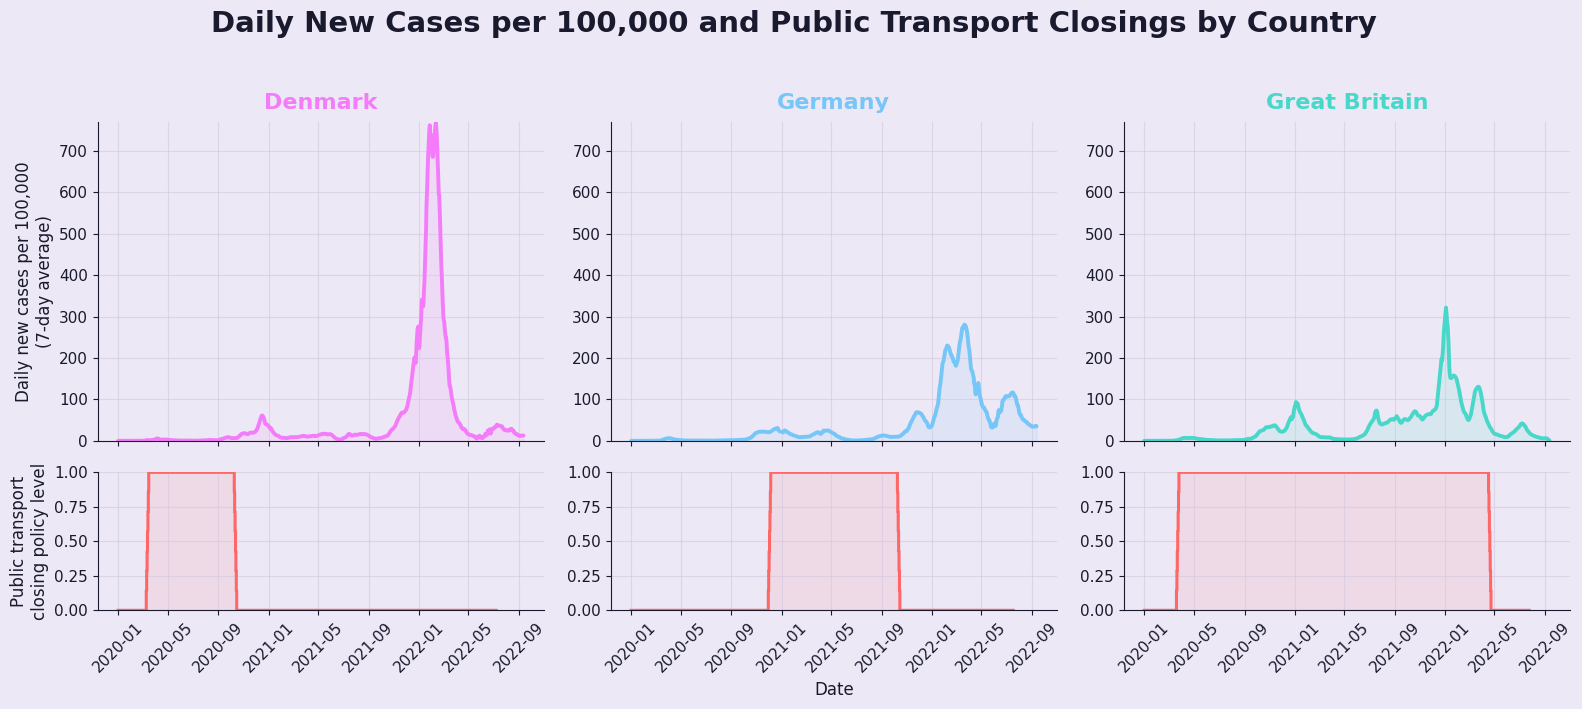

In [ ]:
# Prepare government comparison table for public transport closing
gov_transport_compare = (
    gov_country[gov_country["location_key"].isin(selected_countries)]
    .copy()
    .sort_values(["location_key", "date"])
)

gov_transport_compare["country"] = gov_transport_compare["location_key"].map(country_names)

# Smooth public transport closing slightly for visual readability
gov_transport_compare["public_transport_closing_7d"] = (
    gov_transport_compare.groupby("location_key")["public_transport_closing"]
    .transform(lambda s: s.rolling(7, min_periods=1).mean())
)

# Prepare plotted data for saving
cases_transport_df = (
    epi_compare[["date", "location_key", "country", "new_confirmed_per_100k_7d"]]
    .merge(
        gov_transport_compare[["date", "location_key", "public_transport_closing_7d"]],
        on=["date", "location_key"],
        how="left"
    )
)

save_plot_data(
    cases_transport_df,
    "cases_per_100k_and_public_transport_closing_by_country.csv"
)

# Shared scales for fair comparison
cases_ymax = epi_compare["new_confirmed_per_100k_7d"].max()
transport_ymin = 0
transport_ymax = gov_transport_compare["public_transport_closing_7d"].max()

# Updated country colors
COUNTRY_COLORS = {
    "DK": "#F47CFB",
    "DE": "#76C6F8",
    "GB": "#47D8CA",
}

# Plot: 2 rows x 3 columns
fig, axes = plt.subplots(
    2, 3,
    figsize=(16, 7.2),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1.3]}
)

for col, code in enumerate(selected_countries):
    df_plot = cases_transport_df[cases_transport_df["location_key"] == code].sort_values("date")
    c = COUNTRY_COLORS[code]

    ax_top = axes[0, col]
    ax_bottom = axes[1, col]

    # ---------- Top: cases per 100k ----------
    ax_top.plot(
        df_plot["date"],
        df_plot["new_confirmed_per_100k_7d"],
        color=c,
        linewidth=2.8,
        solid_capstyle="round"
    )

    ax_top.fill_between(
        df_plot["date"],
        df_plot["new_confirmed_per_100k_7d"],
        color=c,
        alpha=0.12
    )

    ax_top.set_title(
        country_names[code],
        color=c,
        pad=10,
        fontsize=16,
        fontweight="bold"
    )
    ax_top.set_ylim(0, cases_ymax)

    style_ax(ax_top)

    # ---------- Bottom: public transport closing ----------
    ax_bottom.step(
        df_plot["date"],
        df_plot["public_transport_closing_7d"],
        where="mid",
        color=POLICY,
        linewidth=2.2
    )

    ax_bottom.fill_between(
        df_plot["date"],
        df_plot["public_transport_closing_7d"],
        step="mid",
        color=POLICY,
        alpha=0.10
    )

    ax_bottom.set_ylim(transport_ymin, transport_ymax)
    ax_bottom.tick_params(axis="x", labelrotation=45)

    style_ax(ax_bottom)

# Shared y-labels
axes[0, 0].set_ylabel("Daily new cases per 100,000\n(7-day average)")
axes[1, 0].set_ylabel("Public transport\nclosing policy level")

for col in [1, 2]:
    axes[0, col].set_ylabel("")
    axes[1, col].set_ylabel("")

# Only add x-axis label in center bottom
axes[1, 1].set_xlabel("Date")
axes[1, 0].set_xlabel("")
axes[1, 2].set_xlabel("")

fig.suptitle(
    "Daily New Cases per 100,000 and Public Transport Closings by Country",
    fontsize=21,
    fontweight="bold",
    y=0.98,
    color=TEXT
)

plt.tight_layout(rect=[0, 0, 1, 0.95])



plt.show()

## Daily new confirmed cases per 100,000 and testing policy by country

This figure compares **Denmark, Germany, and Great Britain** using two aligned views for each country.

### Top row: daily new confirmed cases
The upper panels show the **7-day average of daily new confirmed COVID-19 cases per 100,000 inhabitants**.  
Using cases per 100,000 makes the countries more comparable by adjusting for population size.

### Bottom row: testing policy
The lower panels show the **testing policy level** from the Oxford Government Response dataset.  
This variable is an **ordinal policy measure**, not a population-normalized quantity, so it is shown on its own scale.

Higher values indicate broader or more intensive testing policy.

### Why this layout is appropriate
We do **not** place cases and testing policy on the same axis, because they measure fundamentally different things.  
Instead, we align them vertically and keep the scales consistent across countries:

- the **same case scale** is used for all countries in the top row
- the **same testing-policy scale** is used for all countries in the bottom row

This allows us to compare:

- when case waves occurred,
- when testing policy became broader or more restrictive,
- and whether policy changes happened before, during, or after major waves.

Saved CSV to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/cases_per_100k_and_testing_policy_by_country.csv
Saved figure to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/cases_per_100k_and_testing_policy_by_country.png


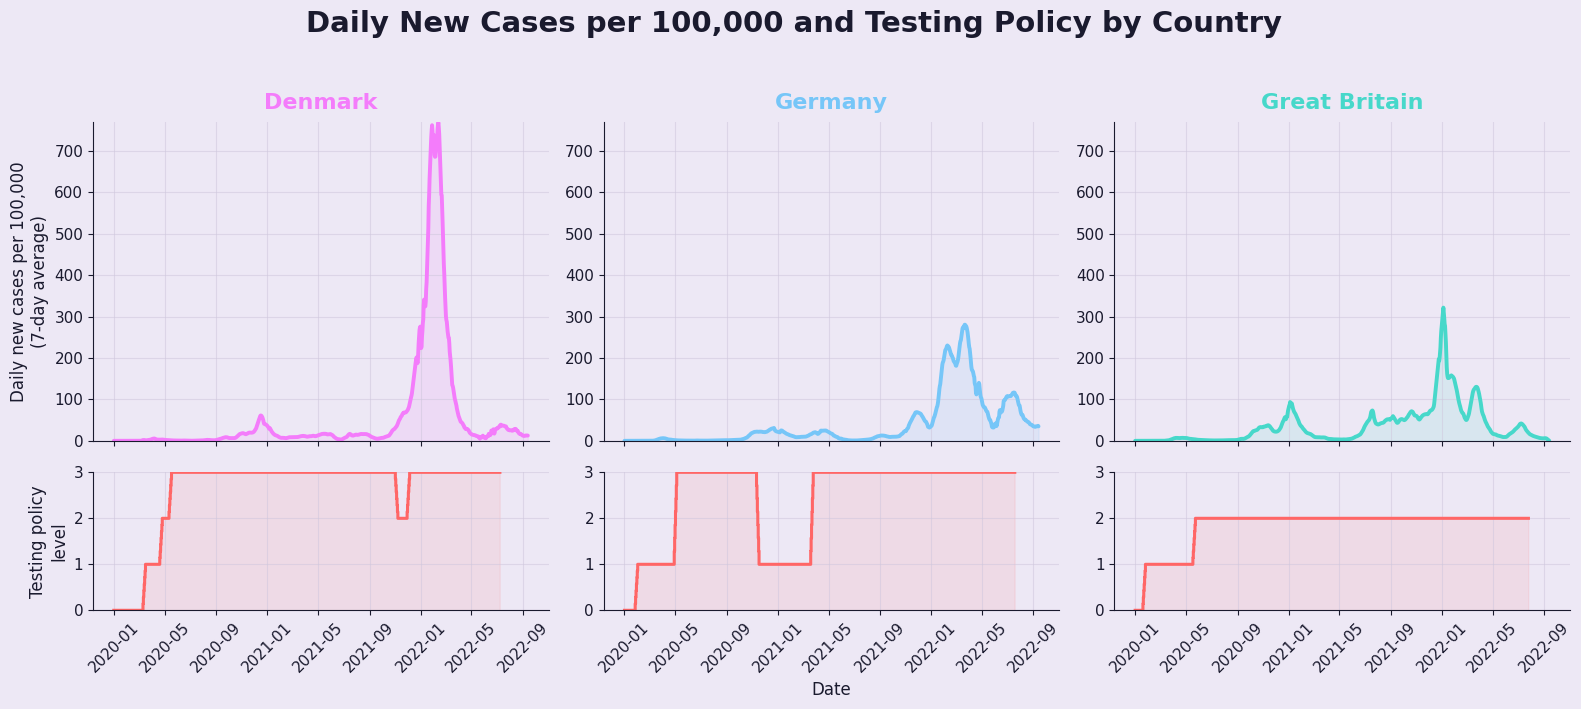

In [ ]:
# Prepare government comparison table for testing policy
gov_testing_compare = (
    gov_country[gov_country["location_key"].isin(selected_countries)]
    .copy()
    .sort_values(["location_key", "date"])
)

gov_testing_compare["country"] = gov_testing_compare["location_key"].map(country_names)

# Smooth testing policy slightly for visual readability
gov_testing_compare["testing_policy_7d"] = (
    gov_testing_compare.groupby("location_key")["testing_policy"]
    .transform(lambda s: s.rolling(7, min_periods=1).mean())
)

# Prepare plotted data for saving
cases_testing_df = (
    epi_compare[["date", "location_key", "country", "new_confirmed_per_100k_7d"]]
    .merge(
        gov_testing_compare[["date", "location_key", "testing_policy_7d"]],
        on=["date", "location_key"],
        how="left"
    )
)

save_plot_data(
    cases_testing_df,
    "cases_per_100k_and_testing_policy_by_country.csv"
)

# Shared scales for fair comparison
cases_ymax = epi_compare["new_confirmed_per_100k_7d"].max()
testing_ymin = 0
testing_ymax = gov_testing_compare["testing_policy_7d"].max()

# Updated country colors
COUNTRY_COLORS = {
    "DK": "#F47CFB",
    "DE": "#76C6F8",
    "GB": "#47D8CA",
}

# Plot: 2 rows x 3 columns
fig, axes = plt.subplots(
    2, 3,
    figsize=(16, 7.2),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1.3]}
)

for col, code in enumerate(selected_countries):
    df_plot = cases_testing_df[cases_testing_df["location_key"] == code].sort_values("date")
    c = COUNTRY_COLORS[code]

    ax_top = axes[0, col]
    ax_bottom = axes[1, col]

    # ---------- Top: cases per 100k ----------
    ax_top.plot(
        df_plot["date"],
        df_plot["new_confirmed_per_100k_7d"],
        color=c,
        linewidth=2.8,
        solid_capstyle="round"
    )

    ax_top.fill_between(
        df_plot["date"],
        df_plot["new_confirmed_per_100k_7d"],
        color=c,
        alpha=0.12
    )

    ax_top.set_title(
        country_names[code],
        color=c,
        pad=10,
        fontsize=16,
        fontweight="bold"
    )
    ax_top.set_ylim(0, cases_ymax)

    style_ax(ax_top)

    # ---------- Bottom: testing policy ----------
    ax_bottom.step(
        df_plot["date"],
        df_plot["testing_policy_7d"],
        where="mid",
        color=POLICY,
        linewidth=2.2
    )

    ax_bottom.fill_between(
        df_plot["date"],
        df_plot["testing_policy_7d"],
        step="mid",
        color=POLICY,
        alpha=0.10
    )

    ax_bottom.set_ylim(testing_ymin, testing_ymax)
    ax_bottom.tick_params(axis="x", labelrotation=45)

    style_ax(ax_bottom)

# Shared y-labels
axes[0, 0].set_ylabel("Daily new cases per 100,000\n(7-day average)")
axes[1, 0].set_ylabel("Testing policy\nlevel")

for col in [1, 2]:
    axes[0, col].set_ylabel("")
    axes[1, col].set_ylabel("")

# Only add x-axis label in center bottom
axes[1, 1].set_xlabel("Date")
axes[1, 0].set_xlabel("")
axes[1, 2].set_xlabel("")

fig.suptitle(
    "Daily New Cases per 100,000 and Testing Policy by Country",
    fontsize=21,
    fontweight="bold",
    y=0.98,
    color=TEXT
)

plt.tight_layout(rect=[0, 0, 1, 0.95])



plt.show()

## Daily new confirmed cases per 100,000 and stay-at-home requirements by country

This figure compares **Denmark, Germany, and Great Britain** using two aligned views for each country.

### Top row: daily new confirmed cases
The upper panels show the **7-day average of daily new confirmed COVID-19 cases per 100,000 inhabitants**.  
Using cases per 100,000 makes the countries more comparable by adjusting for population size.

### Bottom row: stay-at-home requirements
The lower panels show the **stay-at-home requirements policy level** from the Oxford Government Response dataset.  
This variable is an **ordinal policy measure**, not a population-normalized quantity, so it is shown on its own scale.

Higher values indicate stricter stay-at-home requirements.

### Why this layout is appropriate
We do **not** place cases and stay-at-home requirements on the same axis, because they measure fundamentally different things.  
Instead, we align them vertically and keep the scales consistent across countries:

- the **same case scale** is used for all countries in the top row
- the **same stay-at-home scale** is used for all countries in the bottom row

This allows us to compare:

- when case waves occurred,
- when stay-at-home requirements became stricter or more relaxed,
- and whether policy changes happened before, during, or after major waves.

Saved CSV to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/cases_per_100k_and_stay_at_home_requirements_by_country.csv
Saved figure to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/cases_per_100k_and_stay_at_home_requirements_by_country.png


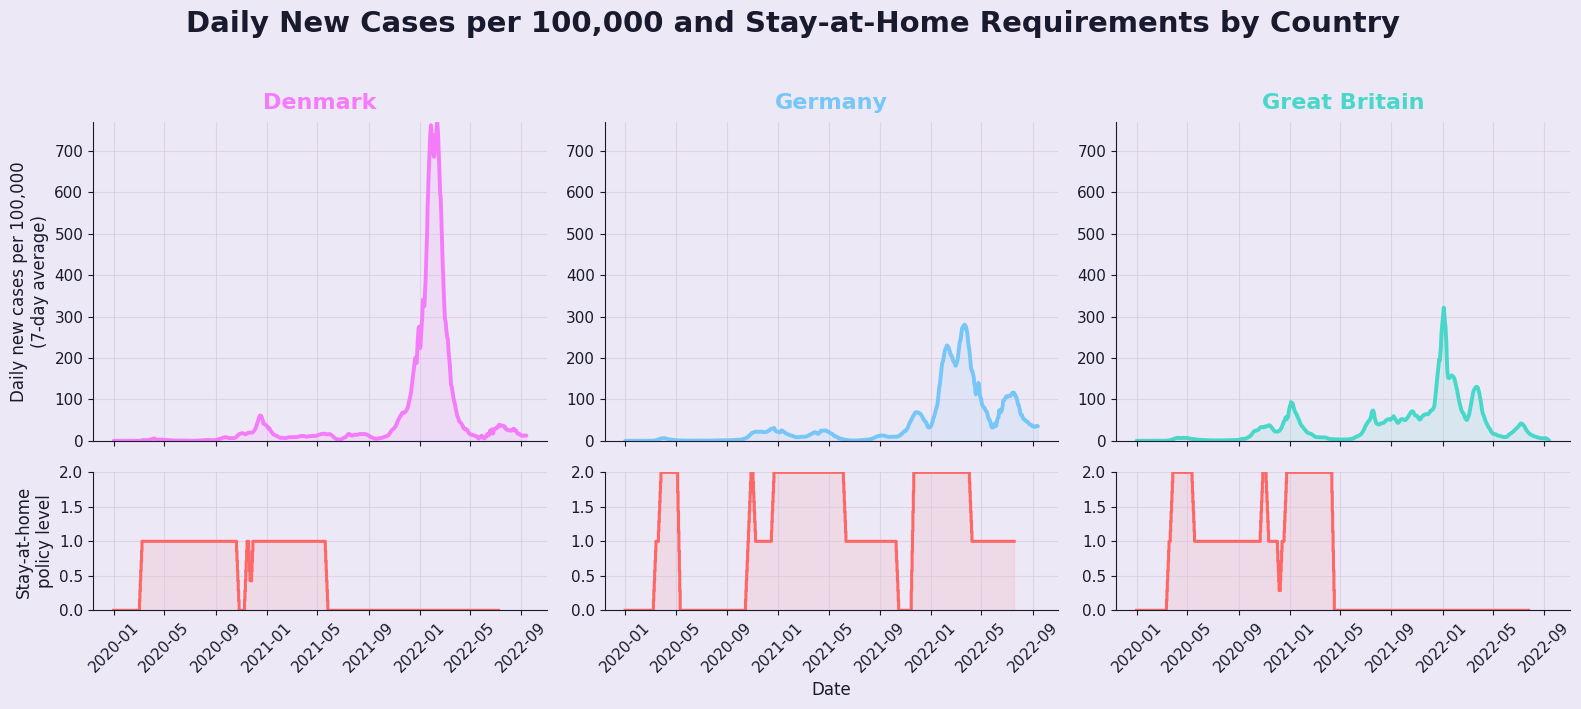

In [ ]:
# Prepare government comparison table for stay-at-home requirements
gov_stayhome_compare = (
    gov_country[gov_country["location_key"].isin(selected_countries)]
    .copy()
    .sort_values(["location_key", "date"])
)

gov_stayhome_compare["country"] = gov_stayhome_compare["location_key"].map(country_names)

# Smooth stay-at-home requirements slightly for visual readability
gov_stayhome_compare["stay_home_7d"] = (
    gov_stayhome_compare.groupby("location_key")["stay_at_home_requirements"]
    .transform(lambda s: s.rolling(7, min_periods=1).mean())
)

# Prepare plotted data for saving
cases_stayhome_df = (
    epi_compare[["date", "location_key", "country", "new_confirmed_per_100k_7d"]]
    .merge(
        gov_stayhome_compare[["date", "location_key", "stay_home_7d"]],
        on=["date", "location_key"],
        how="left"
    )
)

save_plot_data(
    cases_stayhome_df,
    "cases_per_100k_and_stay_at_home_requirements_by_country.csv"
)

# Shared scales for fair comparison
cases_ymax = epi_compare["new_confirmed_per_100k_7d"].max()
stay_home_ymin = 0
stay_home_ymax = gov_stayhome_compare["stay_home_7d"].max()

# Updated country colors
COUNTRY_COLORS = {
    "DK": "#F47CFB",
    "DE": "#76C6F8",
    "GB": "#47D8CA",
}

# Plot: 2 rows x 3 columns
fig, axes = plt.subplots(
    2, 3,
    figsize=(16, 7.2),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1.3]}
)

for col, code in enumerate(selected_countries):
    df_plot = cases_stayhome_df[cases_stayhome_df["location_key"] == code].sort_values("date")
    c = COUNTRY_COLORS[code]

    ax_top = axes[0, col]
    ax_bottom = axes[1, col]

    # ---------- Top: cases per 100k ----------
    ax_top.plot(
        df_plot["date"],
        df_plot["new_confirmed_per_100k_7d"],
        color=c,
        linewidth=2.8,
        solid_capstyle="round"
    )

    ax_top.fill_between(
        df_plot["date"],
        df_plot["new_confirmed_per_100k_7d"],
        color=c,
        alpha=0.12
    )

    ax_top.set_title(
        country_names[code],
        color=c,
        pad=10,
        fontsize=16,
        fontweight="bold"
    )
    ax_top.set_ylim(0, cases_ymax)

    style_ax(ax_top)

    # ---------- Bottom: stay-at-home requirements ----------
    ax_bottom.step(
        df_plot["date"],
        df_plot["stay_home_7d"],
        where="mid",
        color=POLICY,
        linewidth=2.2
    )

    ax_bottom.fill_between(
        df_plot["date"],
        df_plot["stay_home_7d"],
        step="mid",
        color=POLICY,
        alpha=0.10
    )

    ax_bottom.set_ylim(stay_home_ymin, stay_home_ymax)
    ax_bottom.tick_params(axis="x", labelrotation=45)

    style_ax(ax_bottom)

# Shared y-labels
axes[0, 0].set_ylabel("Daily new cases per 100,000\n(7-day average)")
axes[1, 0].set_ylabel("Stay-at-home\npolicy level")

for col in [1, 2]:
    axes[0, col].set_ylabel("")
    axes[1, col].set_ylabel("")

# Only add x-axis label in center bottom
axes[1, 1].set_xlabel("Date")
axes[1, 0].set_xlabel("")
axes[1, 2].set_xlabel("")

fig.suptitle(
    "Daily New Cases per 100,000 and Stay-at-Home Requirements by Country",
    fontsize=21,
    fontweight="bold",
    y=0.98,
    color=TEXT
)

plt.tight_layout(rect=[0, 0, 1, 0.95])


plt.show()

## Daily new deaths per 100,000 and vaccination policy by country

This figure compares **Denmark, Germany, and Great Britain** using two aligned views for each country.

### Top row: daily new deaths
The upper panels show the **7-day average of daily new COVID-19 deaths per 100,000 inhabitants**.  
Using deaths per 100,000 makes the countries more comparable by adjusting for population size.

### Bottom row: vaccination policy
The lower panels show the **vaccination policy level** from the Oxford Government Response dataset.  
This variable is an **ordinal policy measure**, not a population-normalized quantity, so it is shown on its own scale.

Higher values indicate broader or more permissive vaccination policy access.

### Why this layout is appropriate
We do **not** place deaths and vaccination policy on the same axis, because they measure fundamentally different things.  
Instead, we align them vertically and keep the scales consistent across countries:

- the **same death scale** is used for all countries in the top row
- the **same vaccination-policy scale** is used for all countries in the bottom row

This allows us to compare:

- when mortality waves occurred,
- when vaccination policy broadened or changed,
- and whether changes in vaccination policy happened before, during, or after major mortality waves.

Saved CSV to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/deaths_per_100k_and_vaccination_policy_by_country.csv
Saved figure to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/deaths_per_100k_and_vaccination_policy_by_country.png


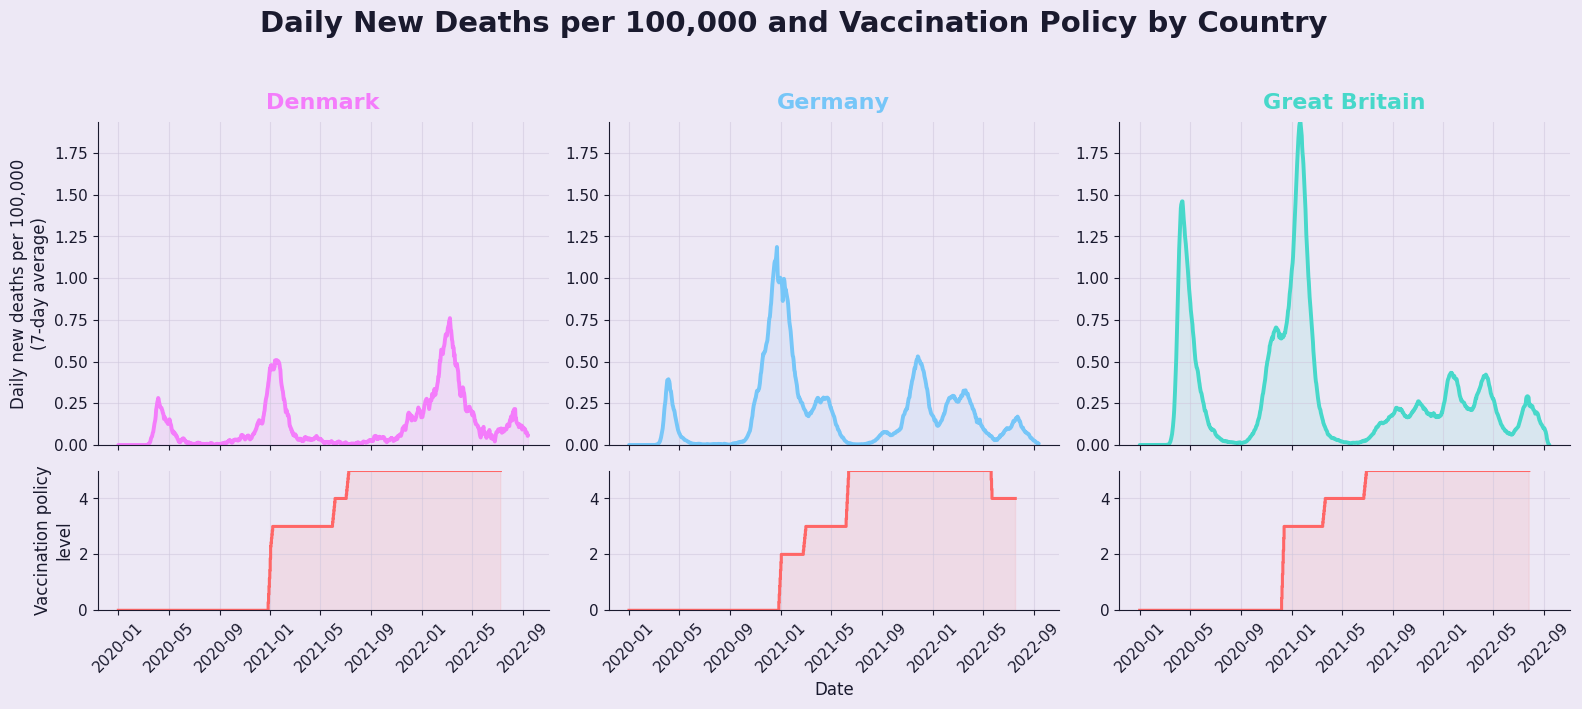

In [ ]:
# Prepare government comparison table for vaccination policy
gov_vaccine_compare = (
    gov_country[gov_country["location_key"].isin(selected_countries)]
    .copy()
    .sort_values(["location_key", "date"])
)

gov_vaccine_compare["country"] = gov_vaccine_compare["location_key"].map(country_names)

# Smooth vaccination policy slightly for visual readability
gov_vaccine_compare["vaccination_policy_7d"] = (
    gov_vaccine_compare.groupby("location_key")["vaccination_policy"]
    .transform(lambda s: s.rolling(7, min_periods=1).mean())
)

# Prepare plotted data for saving
deaths_vaccine_df = (
    epi_compare[["date", "location_key", "country", "new_deceased_per_100k_7d"]]
    .merge(
        gov_vaccine_compare[["date", "location_key", "vaccination_policy_7d"]],
        on=["date", "location_key"],
        how="left"
    )
)

save_plot_data(
    deaths_vaccine_df,
    "deaths_per_100k_and_vaccination_policy_by_country.csv"
)

# Shared scales for fair comparison
deaths_ymax = epi_compare["new_deceased_per_100k_7d"].max()
vaccine_ymin = 0
vaccine_ymax = gov_vaccine_compare["vaccination_policy_7d"].max()

# Updated country colors
COUNTRY_COLORS = {
    "DK": "#F47CFB",
    "DE": "#76C6F8",
    "GB": "#47D8CA",
}

# Plot: 2 rows x 3 columns
fig, axes = plt.subplots(
    2, 3,
    figsize=(16, 7.2),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1.3]}
)

for col, code in enumerate(selected_countries):
    df_plot = deaths_vaccine_df[deaths_vaccine_df["location_key"] == code].sort_values("date")
    c = COUNTRY_COLORS[code]

    ax_top = axes[0, col]
    ax_bottom = axes[1, col]

    # ---------- Top: deaths per 100k ----------
    ax_top.plot(
        df_plot["date"],
        df_plot["new_deceased_per_100k_7d"],
        color=c,
        linewidth=2.8,
        solid_capstyle="round"
    )

    ax_top.fill_between(
        df_plot["date"],
        df_plot["new_deceased_per_100k_7d"],
        color=c,
        alpha=0.12
    )

    ax_top.set_title(
        country_names[code],
        color=c,
        pad=10,
        fontsize=16,
        fontweight="bold"
    )
    ax_top.set_ylim(0, deaths_ymax)

    style_ax(ax_top)

    # ---------- Bottom: vaccination policy ----------
    ax_bottom.step(
        df_plot["date"],
        df_plot["vaccination_policy_7d"],
        where="mid",
        color=POLICY,
        linewidth=2.2
    )

    ax_bottom.fill_between(
        df_plot["date"],
        df_plot["vaccination_policy_7d"],
        step="mid",
        color=POLICY,
        alpha=0.10
    )

    ax_bottom.set_ylim(vaccine_ymin, vaccine_ymax)
    ax_bottom.tick_params(axis="x", labelrotation=45)

    style_ax(ax_bottom)

# Shared y-labels
axes[0, 0].set_ylabel("Daily new deaths per 100,000\n(7-day average)")
axes[1, 0].set_ylabel("Vaccination policy\nlevel")

for col in [1, 2]:
    axes[0, col].set_ylabel("")
    axes[1, col].set_ylabel("")

# Only add x-axis label in center bottom
axes[1, 1].set_xlabel("Date")
axes[1, 0].set_xlabel("")
axes[1, 2].set_xlabel("")

fig.suptitle(
    "Daily New Deaths per 100,000 and Vaccination Policy by Country",
    fontsize=21,
    fontweight="bold",
    y=0.98,
    color=TEXT
)

plt.tight_layout(rect=[0, 0, 1, 0.95])



plt.show()

## Daily new confirmed cases per 100,000 and income support by country

This figure compares **Denmark, Germany, and Great Britain** using two aligned views for each country.

### Top row: daily new confirmed cases
The upper panels show the **7-day average of daily new confirmed COVID-19 cases per 100,000 inhabitants**.  
Using cases per 100,000 makes the countries more comparable by adjusting for population size.

### Bottom row: income support policy
The lower panels show the **income support policy level** from the Oxford Government Response dataset.  
This variable is an **ordinal policy measure**, not a population-normalized quantity, so it is shown on its own scale.

Higher values indicate broader or stronger income support measures.

### Why this layout is appropriate
We do **not** place cases and income support on the same axis, because they measure fundamentally different things.  
Instead, we align them vertically and keep the scales consistent across countries:

- the **same case scale** is used for all countries in the top row
- the **same income-support scale** is used for all countries in the bottom row

This allows us to compare:

- when case waves occurred,
- when income support measures became stronger or weaker,
- and whether changes in support happened before, during, or after major waves.

Saved CSV to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/cases_per_100k_and_income_support_by_country.csv
Saved figure to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/cases_per_100k_and_income_support_by_country.png


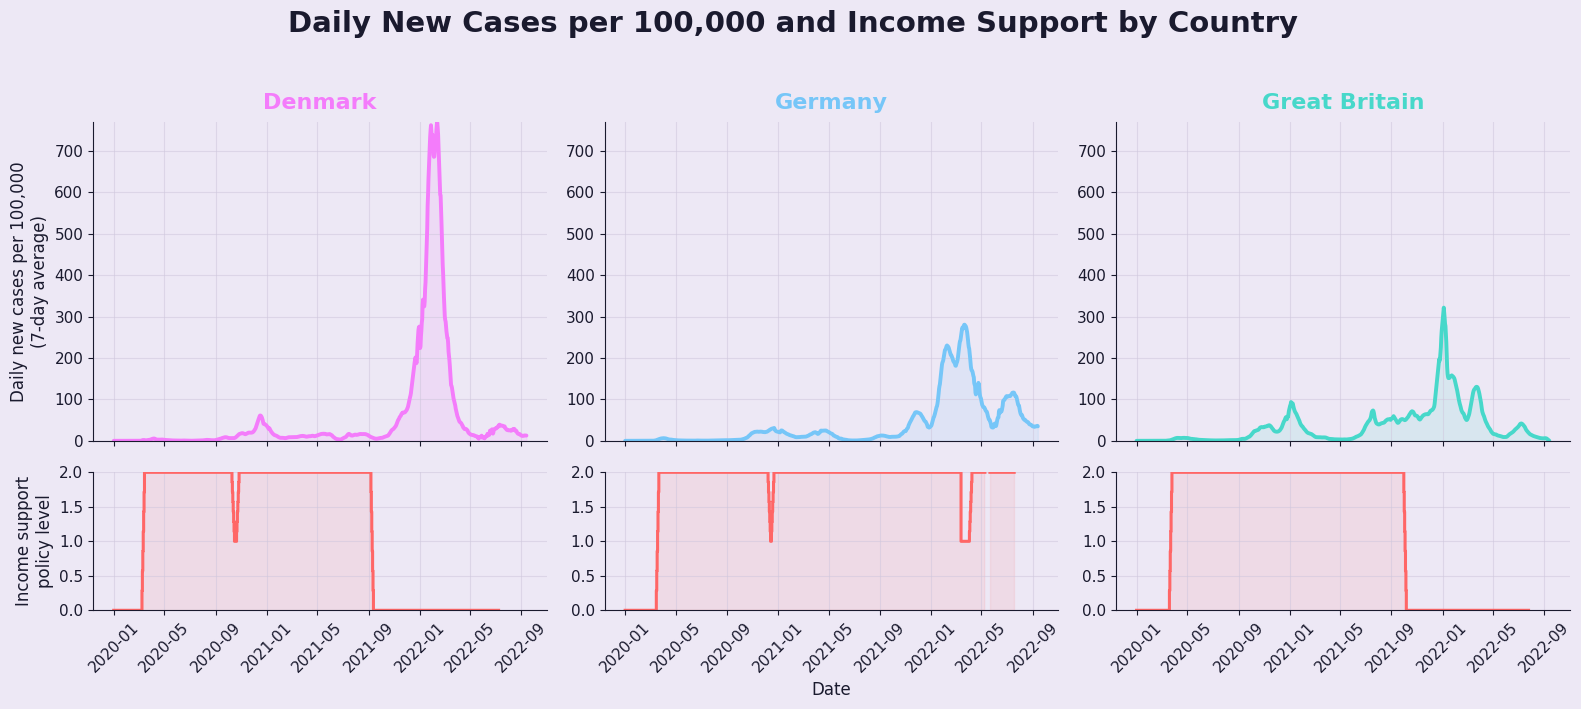

In [ ]:
# Prepare government comparison table for income support
gov_income_compare = (
    gov_country[gov_country["location_key"].isin(selected_countries)]
    .copy()
    .sort_values(["location_key", "date"])
)

gov_income_compare["country"] = gov_income_compare["location_key"].map(country_names)

# Smooth income support slightly for visual readability
gov_income_compare["income_support_7d"] = (
    gov_income_compare.groupby("location_key")["income_support"]
    .transform(lambda s: s.rolling(7, min_periods=1).mean())
)

# Prepare plotted data for saving
cases_income_df = (
    epi_compare[["date", "location_key", "country", "new_confirmed_per_100k_7d"]]
    .merge(
        gov_income_compare[["date", "location_key", "income_support_7d"]],
        on=["date", "location_key"],
        how="left"
    )
)

save_plot_data(
    cases_income_df,
    "cases_per_100k_and_income_support_by_country.csv"
)

# Shared scales for fair comparison
cases_ymax = epi_compare["new_confirmed_per_100k_7d"].max()
income_ymin = 0
income_ymax = gov_income_compare["income_support_7d"].max()

# Updated country colors
COUNTRY_COLORS = {
    "DK": "#F47CFB",
    "DE": "#76C6F8",
    "GB": "#47D8CA",
}

# Plot: 2 rows x 3 columns
fig, axes = plt.subplots(
    2, 3,
    figsize=(16, 7.2),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1.3]}
)

for col, code in enumerate(selected_countries):
    df_plot = cases_income_df[cases_income_df["location_key"] == code].sort_values("date")
    c = COUNTRY_COLORS[code]

    ax_top = axes[0, col]
    ax_bottom = axes[1, col]

    # ---------- Top: cases per 100k ----------
    ax_top.plot(
        df_plot["date"],
        df_plot["new_confirmed_per_100k_7d"],
        color=c,
        linewidth=2.8,
        solid_capstyle="round"
    )

    ax_top.fill_between(
        df_plot["date"],
        df_plot["new_confirmed_per_100k_7d"],
        color=c,
        alpha=0.12
    )

    ax_top.set_title(
        country_names[code],
        color=c,
        pad=10,
        fontsize=16,
        fontweight="bold"
    )
    ax_top.set_ylim(0, cases_ymax)

    style_ax(ax_top)

    # ---------- Bottom: income support ----------
    ax_bottom.step(
        df_plot["date"],
        df_plot["income_support_7d"],
        where="mid",
        color=POLICY,
        linewidth=2.2
    )

    ax_bottom.fill_between(
        df_plot["date"],
        df_plot["income_support_7d"],
        step="mid",
        color=POLICY,
        alpha=0.10
    )

    ax_bottom.set_ylim(income_ymin, income_ymax)
    ax_bottom.tick_params(axis="x", labelrotation=45)

    style_ax(ax_bottom)

# Shared y-labels
axes[0, 0].set_ylabel("Daily new cases per 100,000\n(7-day average)")
axes[1, 0].set_ylabel("Income support\npolicy level")

for col in [1, 2]:
    axes[0, col].set_ylabel("")
    axes[1, col].set_ylabel("")

# Only add x-axis label in center bottom
axes[1, 1].set_xlabel("Date")
axes[1, 0].set_xlabel("")
axes[1, 2].set_xlabel("")

fig.suptitle(
    "Daily New Cases per 100,000 and Income Support by Country",
    fontsize=21,
    fontweight="bold",
    y=0.98,
    color=TEXT
)

plt.tight_layout(rect=[0, 0, 1, 0.95])



plt.show()

## Daily new confirmed cases per 100,000 and debt relief by country

This figure compares **Denmark, Germany, and Great Britain** using two aligned views for each country.

### Top row: daily new confirmed cases
The upper panels show the **7-day average of daily new confirmed COVID-19 cases per 100,000 inhabitants**.  
Using cases per 100,000 makes the countries more comparable by adjusting for population size.

### Bottom row: debt relief policy
The lower panels show the **debt relief policy level** from the Oxford Government Response dataset.  
This variable is an **ordinal policy measure**, not a population-normalized quantity, so it is shown on its own scale.

Higher values indicate broader or stronger debt relief measures.

### Why this layout is appropriate
We do **not** place cases and debt relief on the same axis, because they measure fundamentally different things.  
Instead, we align them vertically and keep the scales consistent across countries:

- the **same case scale** is used for all countries in the top row
- the **same debt-relief scale** is used for all countries in the bottom row

This allows us to compare:

- when case waves occurred,
- when debt relief measures became stronger or weaker,
- and whether changes in support happened before, during, or after major waves.

Saved CSV to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/cases_per_100k_and_debt_relief_by_country.csv
Saved figure to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/cases_per_100k_and_debt_relief_by_country.png


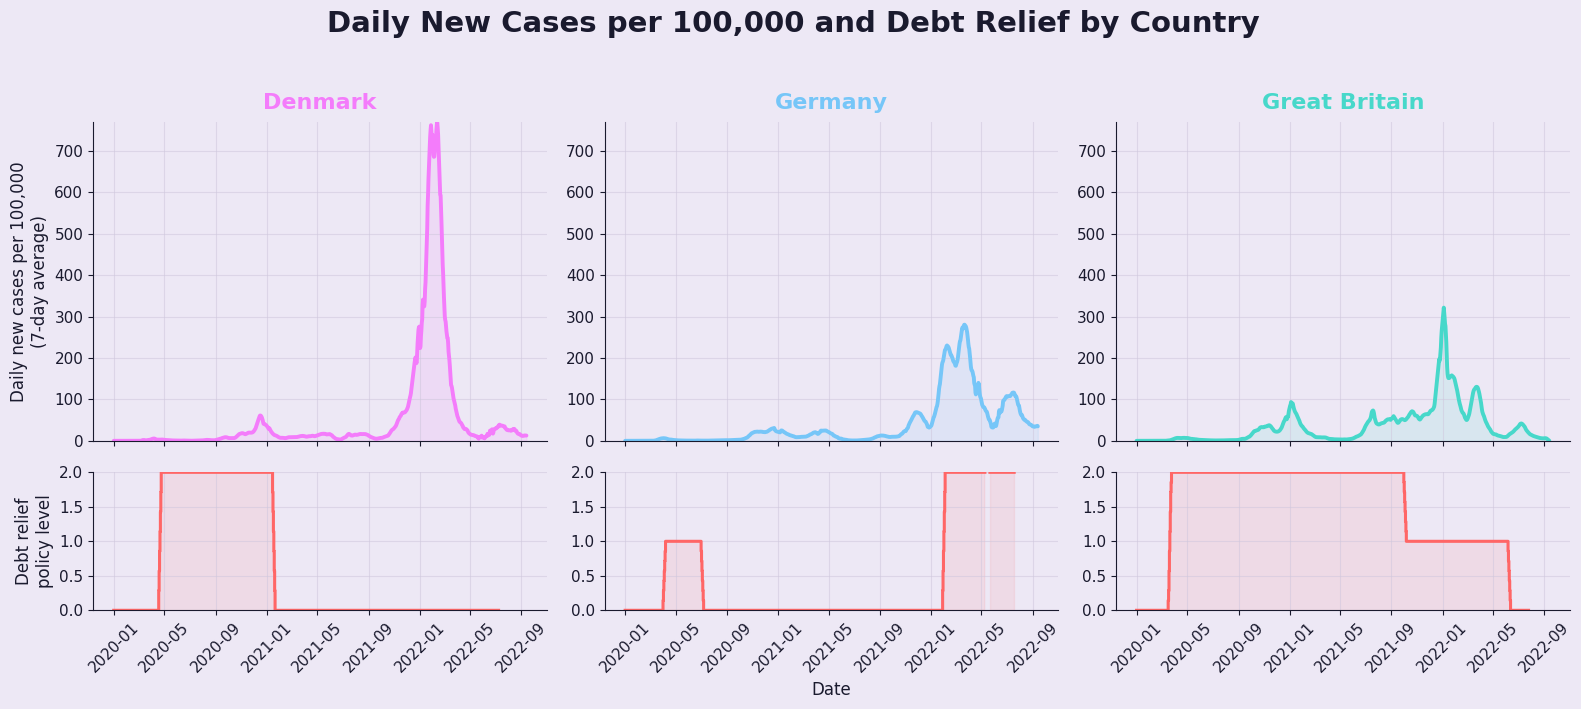

In [ ]:
# Prepare government comparison table for debt relief
gov_debt_compare = (
    gov_country[gov_country["location_key"].isin(selected_countries)]
    .copy()
    .sort_values(["location_key", "date"])
)

gov_debt_compare["country"] = gov_debt_compare["location_key"].map(country_names)

# Smooth debt relief slightly for visual readability
gov_debt_compare["debt_relief_7d"] = (
    gov_debt_compare.groupby("location_key")["debt_relief"]
    .transform(lambda s: s.rolling(7, min_periods=1).mean())
)

# Prepare plotted data for saving
cases_debt_df = (
    epi_compare[["date", "location_key", "country", "new_confirmed_per_100k_7d"]]
    .merge(
        gov_debt_compare[["date", "location_key", "debt_relief_7d"]],
        on=["date", "location_key"],
        how="left"
    )
)

save_plot_data(
    cases_debt_df,
    "cases_per_100k_and_debt_relief_by_country.csv"
)

# Shared scales for fair comparison
cases_ymax = epi_compare["new_confirmed_per_100k_7d"].max()
debt_ymin = 0
debt_ymax = gov_debt_compare["debt_relief_7d"].max()

# Updated country colors
COUNTRY_COLORS = {
    "DK": "#F47CFB",
    "DE": "#76C6F8",
    "GB": "#47D8CA",
}

# Plot: 2 rows x 3 columns
fig, axes = plt.subplots(
    2, 3,
    figsize=(16, 7.2),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1.3]}
)

for col, code in enumerate(selected_countries):
    df_plot = cases_debt_df[cases_debt_df["location_key"] == code].sort_values("date")
    c = COUNTRY_COLORS[code]

    ax_top = axes[0, col]
    ax_bottom = axes[1, col]

    # ---------- Top: cases per 100k ----------
    ax_top.plot(
        df_plot["date"],
        df_plot["new_confirmed_per_100k_7d"],
        color=c,
        linewidth=2.8,
        solid_capstyle="round"
    )

    ax_top.fill_between(
        df_plot["date"],
        df_plot["new_confirmed_per_100k_7d"],
        color=c,
        alpha=0.12
    )

    ax_top.set_title(
        country_names[code],
        color=c,
        pad=10,
        fontsize=16,
        fontweight="bold"
    )
    ax_top.set_ylim(0, cases_ymax)

    style_ax(ax_top)

    # ---------- Bottom: debt relief ----------
    ax_bottom.step(
        df_plot["date"],
        df_plot["debt_relief_7d"],
        where="mid",
        color=POLICY,
        linewidth=2.2
    )

    ax_bottom.fill_between(
        df_plot["date"],
        df_plot["debt_relief_7d"],
        step="mid",
        color=POLICY,
        alpha=0.10
    )

    ax_bottom.set_ylim(debt_ymin, debt_ymax)
    ax_bottom.tick_params(axis="x", labelrotation=45)

    style_ax(ax_bottom)

# Shared y-labels
axes[0, 0].set_ylabel("Daily new cases per 100,000\n(7-day average)")
axes[1, 0].set_ylabel("Debt relief\npolicy level")

for col in [1, 2]:
    axes[0, col].set_ylabel("")
    axes[1, col].set_ylabel("")

# Only add x-axis label in center bottom
axes[1, 1].set_xlabel("Date")
axes[1, 0].set_xlabel("")
axes[1, 2].set_xlabel("")

fig.suptitle(
    "Daily New Cases per 100,000 and Debt Relief by Country",
    fontsize=21,
    fontweight="bold",
    y=0.98,
    color=TEXT
)

plt.tight_layout(rect=[0, 0, 1, 0.95])


plt.show()

## Daily new confirmed cases per 100,000 and international support by country

This figure compares **Denmark, Germany, and Great Britain** using two aligned views for each country.

### Top row: daily new confirmed cases
The upper panels show the **7-day average of daily new confirmed COVID-19 cases per 100,000 inhabitants**.  
Using cases per 100,000 makes the countries more comparable by adjusting for population size.

### Bottom row: international support policy
The lower panels show the **international support policy level** from the Oxford Government Response dataset.  
This variable is an **ordinal policy measure**, not a population-normalized quantity, so it is shown on its own scale.

Higher values indicate broader or stronger international support measures.

### Why this layout is appropriate
We do **not** place cases and international support on the same axis, because they measure fundamentally different things.  
Instead, we align them vertically and keep the scales consistent across countries:

- the **same case scale** is used for all countries in the top row
- the **same international-support scale** is used for all countries in the bottom row

This allows us to compare:

- when case waves occurred,
- when international support measures became stronger or weaker,
- and whether changes in support happened before, during, or after major waves.

Saved CSV to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/cases_per_100k_and_international_support_by_country.csv
Saved figure to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/cases_per_100k_and_international_support_by_country.png


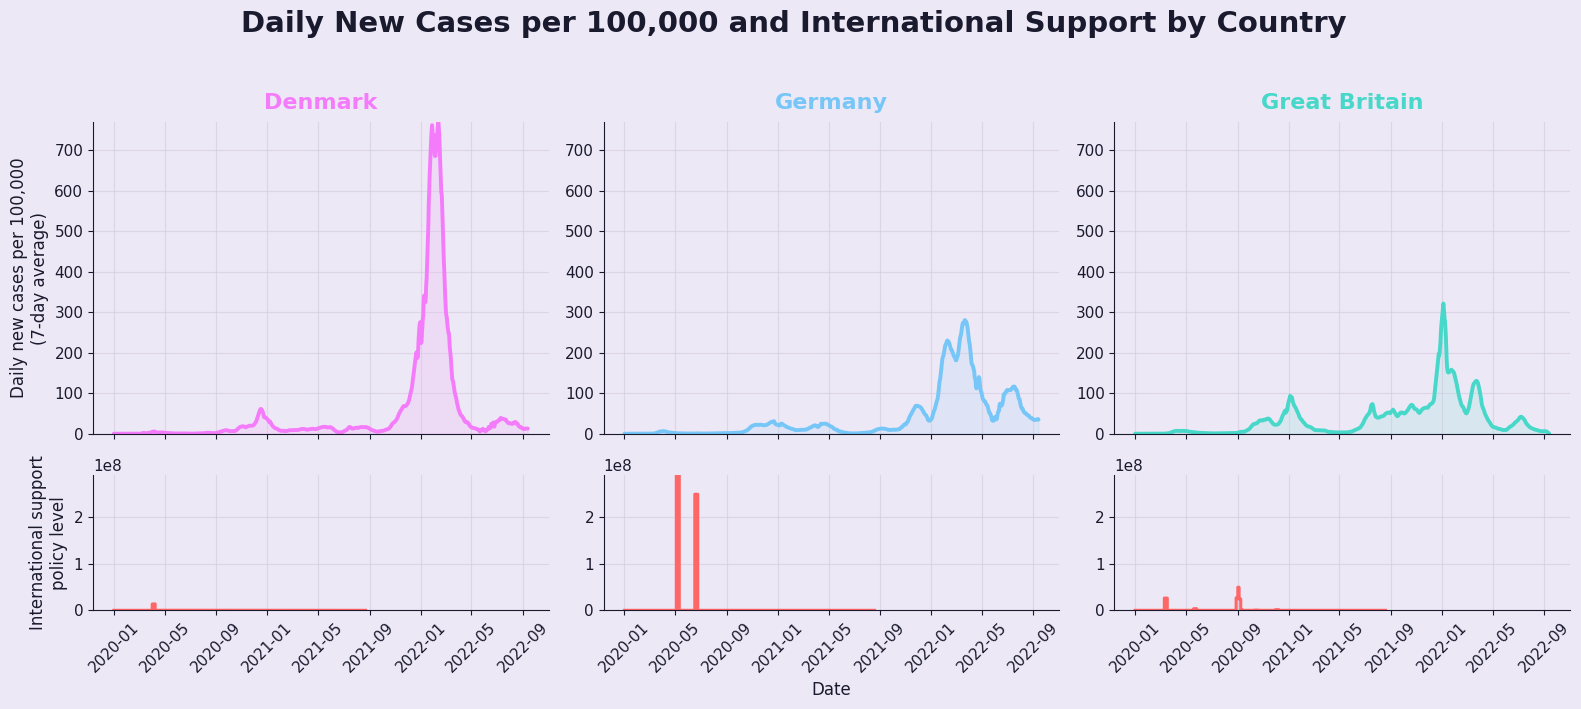

In [ ]:
# Prepare government comparison table for international support
gov_international_compare = (
    gov_country[gov_country["location_key"].isin(selected_countries)]
    .copy()
    .sort_values(["location_key", "date"])
)

gov_international_compare["country"] = gov_international_compare["location_key"].map(country_names)

# Smooth international support slightly for visual readability
gov_international_compare["international_support_7d"] = (
    gov_international_compare.groupby("location_key")["international_support"]
    .transform(lambda s: s.rolling(7, min_periods=1).mean())
)

# Prepare plotted data for saving
cases_international_df = (
    epi_compare[["date", "location_key", "country", "new_confirmed_per_100k_7d"]]
    .merge(
        gov_international_compare[["date", "location_key", "international_support_7d"]],
        on=["date", "location_key"],
        how="left"
    )
)

save_plot_data(
    cases_international_df,
    "cases_per_100k_and_international_support_by_country.csv"
)

# Shared scales for fair comparison
cases_ymax = epi_compare["new_confirmed_per_100k_7d"].max()
international_ymin = 0
international_ymax = gov_international_compare["international_support_7d"].max()

# Updated country colors
COUNTRY_COLORS = {
    "DK": "#F47CFB",
    "DE": "#76C6F8",
    "GB": "#47D8CA",
}

# Plot: 2 rows x 3 columns
fig, axes = plt.subplots(
    2, 3,
    figsize=(16, 7.2),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1.3]}
)

for col, code in enumerate(selected_countries):
    df_plot = cases_international_df[cases_international_df["location_key"] == code].sort_values("date")
    c = COUNTRY_COLORS[code]

    ax_top = axes[0, col]
    ax_bottom = axes[1, col]

    # ---------- Top: cases per 100k ----------
    ax_top.plot(
        df_plot["date"],
        df_plot["new_confirmed_per_100k_7d"],
        color=c,
        linewidth=2.8,
        solid_capstyle="round"
    )

    ax_top.fill_between(
        df_plot["date"],
        df_plot["new_confirmed_per_100k_7d"],
        color=c,
        alpha=0.12
    )

    ax_top.set_title(
        country_names[code],
        color=c,
        pad=10,
        fontsize=16,
        fontweight="bold"
    )
    ax_top.set_ylim(0, cases_ymax)

    style_ax(ax_top)

    # ---------- Bottom: international support ----------
    ax_bottom.step(
        df_plot["date"],
        df_plot["international_support_7d"],
        where="mid",
        color=POLICY,
        linewidth=2.2
    )

    ax_bottom.fill_between(
        df_plot["date"],
        df_plot["international_support_7d"],
        step="mid",
        color=POLICY,
        alpha=0.10
    )

    ax_bottom.set_ylim(international_ymin, international_ymax)
    ax_bottom.tick_params(axis="x", labelrotation=45)

    style_ax(ax_bottom)

# Shared y-labels
axes[0, 0].set_ylabel("Daily new cases per 100,000\n(7-day average)")
axes[1, 0].set_ylabel("International support\npolicy level")

for col in [1, 2]:
    axes[0, col].set_ylabel("")
    axes[1, col].set_ylabel("")

# Only add x-axis label in center bottom
axes[1, 1].set_xlabel("Date")
axes[1, 0].set_xlabel("")
axes[1, 2].set_xlabel("")

fig.suptitle(
    "Daily New Cases per 100,000 and International Support by Country",
    fontsize=21,
    fontweight="bold",
    y=0.98,
    color=TEXT
)

plt.tight_layout(rect=[0, 0, 1, 0.95])


plt.show()

## Animated world choropleth: monthly new confirmed cases

This animated choropleth map shows how the pandemic evolved across the world over time.

Each country is colored by its **total number of new confirmed COVID-19 cases within each month**.  
Because countries differ greatly in population size, this map is best interpreted as a view of the **global spread and concentration of cases**, rather than a fair per-capita comparison.

### Why monthly aggregation?
Daily global data are noisy and can make animation difficult to read.  
Aggregating to the monthly level creates a smoother and more interpretable view of how the pandemic moved across countries over time.

### Why use a log scale?
Case counts vary enormously across countries. A log-scaled color range makes the map easier to read by improving contrast among low-, medium-, and high-case countries.

### How to read the map
- darker colors indicate higher monthly case counts
- the slider allows the reader to move through time
- the map provides global context before the more detailed country comparisons later in the project

In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px

# --------------------------------------------------
# Build monthly country-level case totals
# --------------------------------------------------
world_monthly = epi_country.copy()

world_monthly["year_month"] = world_monthly["date"].dt.to_period("M").astype(str)

world_monthly_agg = (
    world_monthly.groupby(["location_key", "year_month"], as_index=False)
    .agg(
        monthly_new_confirmed=("new_confirmed", "sum")
    )
)

# Add ISO-3 for mapping
world_monthly_agg["iso3"] = world_monthly_agg["location_key"].apply(iso2_to_iso3)
world_monthly_agg = world_monthly_agg.dropna(subset=["iso3"]).copy()

# Log scale for better visual contrast
world_monthly_agg["log_monthly_cases"] = np.log10(
    world_monthly_agg["monthly_new_confirmed"].clip(lower=0) + 1
)

# Save plotted data because this is a presentable figure
save_plot_data(
    world_monthly_agg,
    "animated_world_monthly_new_confirmed_cases.csv"
)

# --------------------------------------------------
# Build animated choropleth
# --------------------------------------------------
fig = px.choropleth(
    world_monthly_agg,
    locations="iso3",
    color="log_monthly_cases",
    hover_name="location_key",
    hover_data={
        "monthly_new_confirmed": ":,.0f",
        "log_monthly_cases": False,
        "iso3": False
    },
    animation_frame="year_month",
    color_continuous_scale=[
        [0.00, "#EDE8F5"],
        [0.20, "#D8ECEA"],
        [0.40, "#CDE1ED"],
        [0.60, "#DEDAF2"],
        [0.80, "#EFDEF0"],
        [1.00, "#FF6666"],
    ],
    projection="natural earth",
    title="Animated World Map: Monthly New Confirmed Cases"
)

fig.update_layout(
    paper_bgcolor=BG,
    plot_bgcolor=BG,
    font=dict(
        family="Aptos, DejaVu Sans, Arial, sans-serif",
        color=TEXT,
        size=14
    ),
    title=dict(
        text="Animated World Map: Monthly New Confirmed Cases",
        x=0.03,
        xanchor="left",
        font=dict(size=24, color=TEXT)
    ),
    coloraxis_colorbar=dict(
        title=dict(
            text="log10(monthly cases + 1)",
            font=dict(color=TEXT)
        ),
        tickfont=dict(color=TEXT)
    ),
    margin=dict(l=0, r=0, t=70, b=0)
)

fig.update_geos(
    showframe=False,
    showcoastlines=False,
    showcountries=True,
    countrycolor=TEXT,
    countrywidth=0.5,
    showland=True,
    landcolor=BG,
    bgcolor=BG
)

# Optional: make play button blend into your theme
if fig.layout.updatemenus:
    fig.layout.updatemenus[0].bgcolor = "#D8ECEA"


fig.show()

Saved CSV to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/animated_world_monthly_new_confirmed_cases.csv
Saved interactive figure to: /Users/katherinakronborg/Desktop/Data Analysis 2026/final_project/docs/plots/animated_world_monthly_new_confirmed_cases.html
